<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Tradional_Descision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ID3 DECISION TREE — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 2
Number classes   : 2
Tree depth       : 10
Number of leaves : 176

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9459
Precision : 0.9462
Recall    : 0.9459
F1 Score  : 0.9459

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9250
Precision : 0.9250
Recall    : 0.9250
F1 Score  : 0.9250

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.9302, Recall = 0.9191, F1 = 0.9246
Class 1: Precision = 0.9198, Recall = 0.9309, F1 = 0.9253

---------------------------------------------

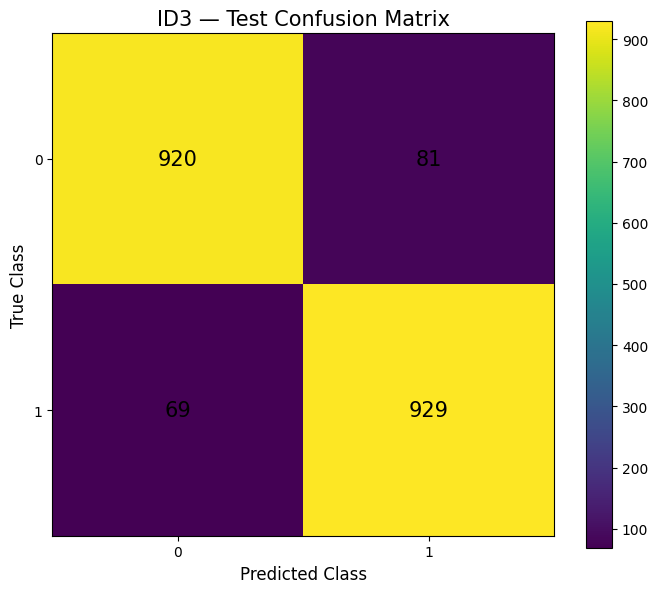

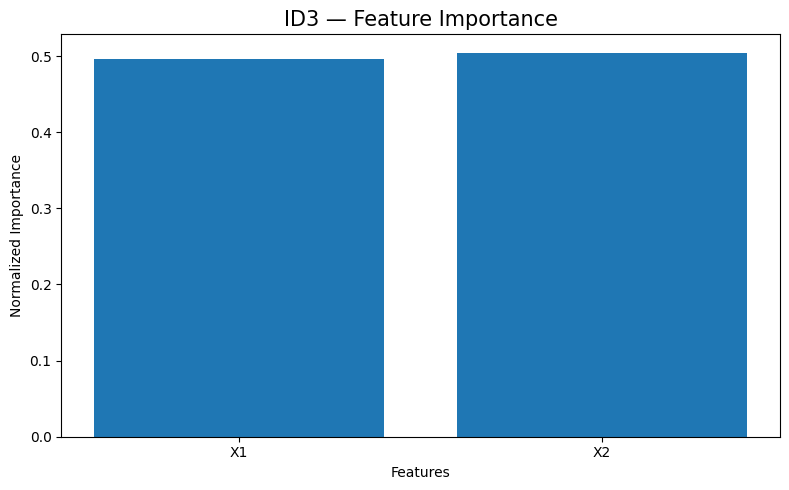

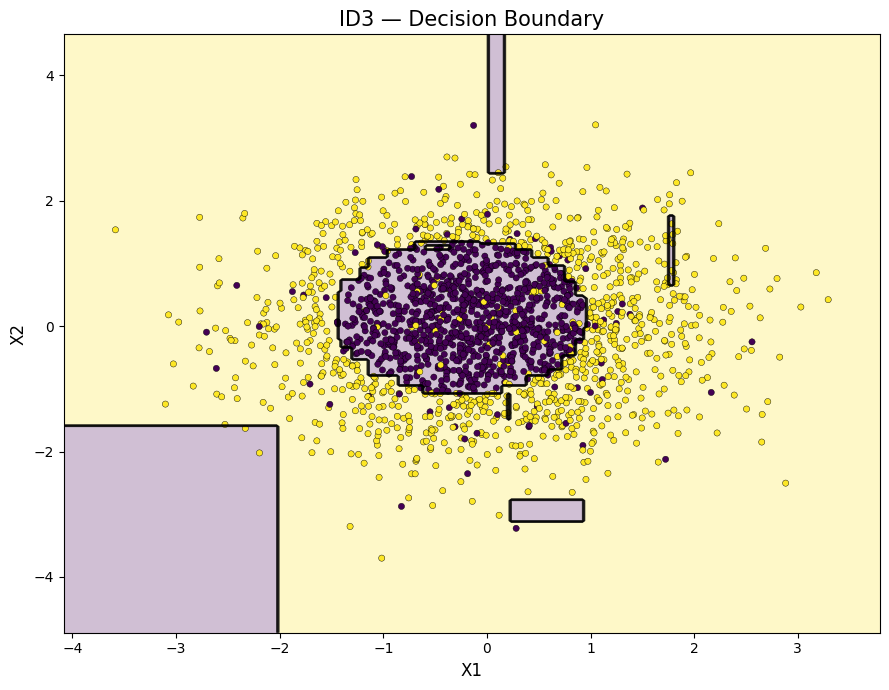

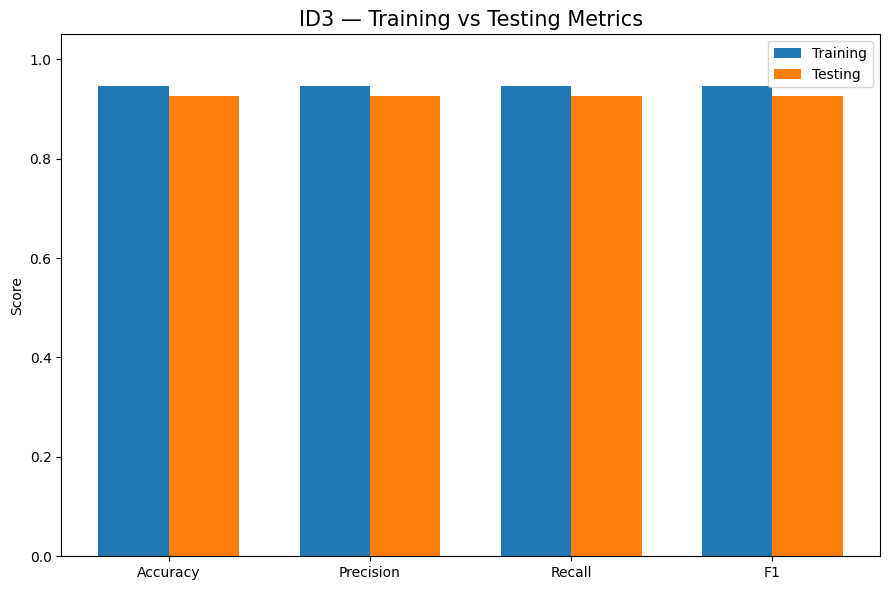

In [2]:
# ============================================================
# ID3 DECISION TREE FROM SCRATCH
# ============================================================
# Libraries:
#   NumPy
#   Matplotlib
#
# NO sklearn is used for:
#   - Decision Tree
#   - Train/Test Split
#   - Confusion Matrix
#   - Evaluation Metrics
#
# Includes:
#   1. Entropy
#   2. Information Gain
#   3. Numerical feature splitting
#   4. Recursive tree construction
#   5. Stopping criteria
#   6. Prediction
#   7. Accuracy
#   8. Precision
#   9. Recall
#  10. F1 Score
#  11. Confusion Matrix
#  12. Feature Importance
#  13. Decision Boundary
#
# Dataset:
#   10,000 samples
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        feature_name=None,
        threshold=None,
        is_leaf=False,
        prediction=None,
        class_counts=None,
        depth=0
    ):

        self.feature_index = feature_index
        self.feature_name = feature_name
        self.threshold = threshold

        self.is_leaf = is_leaf
        self.prediction = prediction

        self.class_counts = class_counts

        self.depth = depth

        self.left = None
        self.right = None


# ============================================================
# 2. ID3 CLASSIFIER
# ============================================================

class ID3Classifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_gain=1e-10
    ):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain

        self.root = None

        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

        self.feature_names_ = None
        self.feature_importances_ = None

        self.tree_depth_ = 0
        self.n_leaves_ = 0


    # ========================================================
    # ENTROPY
    # ========================================================

    def _entropy(self, y):

        if len(y) == 0:
            return 0.0

        _, counts = np.unique(
            y,
            return_counts=True
        )

        probabilities = counts / len(y)

        entropy = 0.0

        for p in probabilities:

            if p > 0:

                entropy -= (
                    p * np.log2(p)
                )

        return entropy


    # ========================================================
    # INFORMATION GAIN
    # ========================================================

    def _information_gain(
        self,
        y,
        left_y,
        right_y
    ):

        parent_entropy = self._entropy(y)

        n = len(y)

        if (
            len(left_y) == 0
            or
            len(right_y) == 0
        ):

            return 0.0

        left_weight = (
            len(left_y) / n
        )

        right_weight = (
            len(right_y) / n
        )

        child_entropy = (
            left_weight
            *
            self._entropy(left_y)
            +
            right_weight
            *
            self._entropy(right_y)
        )

        gain = (
            parent_entropy
            -
            child_entropy
        )

        return gain


    # ========================================================
    # BEST NUMERICAL SPLIT
    # ========================================================

    def _best_numeric_split(
        self,
        X_column,
        y
    ):

        unique_values = np.unique(
            X_column
        )

        if len(unique_values) <= 1:

            return None, -np.inf

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_threshold = None

        best_gain = -np.inf

        for threshold in thresholds:

            left_mask = (
                X_column <= threshold
            )

            right_mask = (
                X_column > threshold
            )

            left_count = np.sum(
                left_mask
            )

            right_count = np.sum(
                right_mask
            )

            if (
                left_count
                <
                self.min_samples_leaf
                or
                right_count
                <
                self.min_samples_leaf
            ):

                continue

            left_y = y[left_mask]

            right_y = y[right_mask]

            gain = self._information_gain(
                y,
                left_y,
                right_y
            )

            if gain > best_gain:

                best_gain = gain

                best_threshold = threshold

        return (
            best_threshold,
            best_gain
        )


    # ========================================================
    # FIND BEST SPLIT
    # ========================================================

    def _best_split(
        self,
        X,
        y
    ):

        best_feature = None

        best_threshold = None

        best_gain = -np.inf

        for feature_index in range(
            self.n_features_
        ):

            column = X[
                :,
                feature_index
            ]

            threshold, gain = (
                self._best_numeric_split(
                    column,
                    y
                )
            )

            if gain > best_gain:

                best_gain = gain

                best_feature = (
                    feature_index
                )

                best_threshold = (
                    threshold
                )

        return (
            best_feature,
            best_threshold,
            best_gain
        )


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(self, y):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        majority_class = (
            self._majority_class(y)
        )

        class_counts = {}

        for c in self.classes_:

            class_counts[c] = np.sum(
                y == c
            )

        node = TreeNode(
            is_leaf=False,
            prediction=majority_class,
            class_counts=class_counts,
            depth=depth
        )

        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 1
        # Pure node
        # ----------------------------------------------------

        if len(np.unique(y)) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 2
        # Maximum depth
        # ----------------------------------------------------

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 3
        # Minimum samples
        # ----------------------------------------------------

        if (
            len(y)
            <
            self.min_samples_split
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # FIND BEST SPLIT
        # ----------------------------------------------------

        (
            feature_index,
            threshold,
            gain
        ) = self._best_split(
            X,
            y
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 4
        # No useful split
        # ----------------------------------------------------

        if (
            feature_index is None
            or
            threshold is None
            or
            gain <= self.min_gain
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STORE SPLIT
        # ----------------------------------------------------

        node.feature_index = (
            feature_index
        )

        node.feature_name = (
            self.feature_names_[
                feature_index
            ]
        )

        node.threshold = threshold


        # ----------------------------------------------------
        # FEATURE IMPORTANCE
        # ----------------------------------------------------

        self.feature_importances_[
            feature_index
        ] += (
            gain * len(y)
        )


        # ----------------------------------------------------
        # SPLIT DATA
        # ----------------------------------------------------

        left_mask = (
            X[:, feature_index]
            <=
            threshold
        )

        right_mask = (
            X[:, feature_index]
            >
            threshold
        )


        X_left = X[left_mask]

        y_left = y[left_mask]


        X_right = X[right_mask]

        y_right = y[right_mask]


        # ----------------------------------------------------
        # MINIMUM LEAF CHECK
        # ----------------------------------------------------

        if (
            len(y_left)
            <
            self.min_samples_leaf
            or
            len(y_right)
            <
            self.min_samples_leaf
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # RECURSIVE TREE BUILDING
        # ----------------------------------------------------

        node.left = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        node.right = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(X)

        y = np.asarray(y)

        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )

        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )

        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )

        self.n_features_ = (
            X.shape[1]
        )

        self.classes_ = np.unique(
            y
        )

        self.n_classes_ = (
            len(self.classes_)
        )


        if feature_names is None:

            self.feature_names_ = [
                f"Feature_{i}"
                for i in range(
                    self.n_features_
                )
            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )

        self.tree_depth_ = 0

        self.n_leaves_ = 0


        self.root = self._build_tree(
            X,
            y
        )


        # Normalize feature importance

        total = np.sum(
            self.feature_importances_
        )

        if total > 0:

            self.feature_importances_ /= (
                total
            )

        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        feature_value = x[
            node.feature_index
        ]


        if (
            feature_value
            <=
            node.threshold
        ):

            return self._predict_sample(
                x,
                node.left
            )

        else:

            return self._predict_sample(
                x,
                node.right
            )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(X)

        predictions = []

        for x in X:

            predictions.append(
                self._predict_sample(
                    x,
                    self.root
                )
            )

        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )

        return np.mean(
            predictions == y
        )


# ============================================================
# 3. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    train_indices = []

    test_indices = []


    # Stratified split

    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]

        rng.shuffle(
            indices
        )

        n_test = int(
            len(indices)
            *
            test_size
        )

        test_indices.extend(
            indices[:n_test]
        )

        train_indices.extend(
            indices[n_test:]
        )


    train_indices = np.asarray(
        train_indices
    )

    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )

    rng.shuffle(
        test_indices
    )


    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# 4. CONFUSION MATRIX FROM SCRATCH
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )

    matrix = np.zeros(
        (
            len(labels),
            len(labels)
        ),
        dtype=int
    )


    label_to_index = {
        label: i
        for i, label in enumerate(
            labels
        )
    }


    for true, pred in zip(
        y_true,
        y_pred
    ):

        matrix[
            label_to_index[true],
            label_to_index[pred]
        ] += 1


    return matrix, labels


# ============================================================
# 5. CLASSIFICATION METRICS FROM SCRATCH
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (
        confusion_matrix_manual(
            y_true,
            y_pred
        )
    )


    accuracy = (
        np.trace(cm)
        /
        np.sum(cm)
    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[i, i]

        FP = (
            np.sum(cm[:, i])
            -
            TP
        )

        FN = (
            np.sum(cm[i, :])
            -
            TP
        )


        precision = (
            TP / (TP + FP)
            if (TP + FP) > 0
            else 0.0
        )


        recall = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else 0.0
        )


        if (
            precision + recall
            >
            0
        ):

            f1 = (
                2
                *
                precision
                *
                recall
                /
                (
                    precision
                    +
                    recall
                )
            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )

        recalls.append(
            recall
        )

        f1_scores.append(
            f1
        )


    macro_precision = np.mean(
        precisions
    )

    macro_recall = np.mean(
        recalls
    )

    macro_f1 = np.mean(
        f1_scores
    )


    return {
        "accuracy": accuracy,
        "precision": macro_precision,
        "recall": macro_recall,
        "f1": macro_f1,
        "labels": labels,
        "confusion_matrix": cm,
        "per_class_precision": precisions,
        "per_class_recall": recalls,
        "per_class_f1": f1_scores
    }


# ============================================================
# 6. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)

n_samples = 10_000


# ------------------------------------------------------------
# Generate 2D features
# ------------------------------------------------------------

X = rng.normal(
    0,
    1,
    size=(
        n_samples,
        2
    )
)


x1 = X[:, 0]

x2 = X[:, 1]


# ------------------------------------------------------------
# Nonlinear target function
# ------------------------------------------------------------

decision_function = (
    x1**2
    +
    x2**2
    +
    0.5 * x1
    -
    0.3 * x2
)


y = (
    decision_function > 1.4
).astype(int)


# ------------------------------------------------------------
# Add 5% label noise
# ------------------------------------------------------------

noise = (
    rng.random(
        n_samples
    )
    <
    0.05
)


y[noise] = (
    1 - y[noise]
)


feature_names = [
    "X1",
    "X2"
]


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 8. CREATE AND TRAIN MODEL
# ============================================================

model = ID3Classifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    min_gain=1e-6
)


model.fit(
    X_train,
    y_train,
    feature_names=feature_names
)


# ============================================================
# 9. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)

y_test_pred = model.predict(
    X_test
)


# ============================================================
# 10. EVALUATION
# ============================================================

train_metrics = (
    classification_metrics(
        y_train,
        y_train_pred
    )
)


test_metrics = (
    classification_metrics(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 11. PRINT RESULTS
# ============================================================

print("=" * 70)

print(
    "ID3 DECISION TREE — FROM SCRATCH"
)

print("=" * 70)

print(
    f"Total samples    : {n_samples:,}"
)

print(
    f"Training samples : {len(X_train):,}"
)

print(
    f"Testing samples  : {len(X_test):,}"
)

print(
    f"Number features  : {model.n_features_}"
)

print(
    f"Number classes   : {model.n_classes_}"
)

print(
    f"Tree depth       : {model.tree_depth_}"
)

print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# TRAINING METRICS
# ============================================================

print()
print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)

print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# TEST METRICS
# ============================================================

print()
print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)

print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 12. PER-CLASS METRICS
# ============================================================

print()
print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(
    test_metrics["labels"]
):

    print(
        f"Class {label}: "
        f"Precision = "
        f"{test_metrics['per_class_precision'][i]:.4f}, "
        f"Recall = "
        f"{test_metrics['per_class_recall'][i]:.4f}, "
        f"F1 = "
        f"{test_metrics['per_class_f1'][i]:.4f}"
    )


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]

labels = test_metrics[
    "labels"
]


print()
print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)

print(cm)


# ============================================================
# 14. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "ID3 — Test Confusion Matrix",
    fontsize=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.xticks(
    range(len(labels)),
    labels
)

plt.yticks(
    range(len(labels)),
    labels
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=15
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 15. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    model.feature_names_,
    model.feature_importances_
)

plt.title(
    "ID3 — Feature Importance",
    fontsize=15
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Normalized Importance"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. DECISION BOUNDARY VISUALIZATION (FIXED)
# ============================================================

x_min = (
    X[:, 0].min()
    -
    0.5
)

x_max = (
    X[:, 0].max()
    +
    0.5
)

y_min = (
    X[:, 1].min()
    -
    0.5
)

y_max = (
    X[:, 1].max()
    +
    0.5
)


resolution = 300


xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        resolution
    ),
    np.linspace(
        y_min,
        y_max,
        resolution
    )
)


grid = np.column_stack(
    [
        xx.ravel(),
        yy.ravel()
    ]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(9, 7)
)


# Fixed: Using contour instead of contourf to prevent background bleeding
plt.contour(
    xx,
    yy,
    grid_predictions,
    colors="black",
    linewidths=0.8,
    alpha=0.6
)

# Fixed: Using pcolormesh with explicit limits matching the data range to avoid outlier boundary artifacts
plt.pcolormesh(
    xx,
    yy,
    grid_predictions,
    cmap="viridis",
    alpha=0.25,
    shading="auto"
)


# Plot test observations

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="viridis",
    s=20,
    edgecolors="black",
    linewidths=0.3
)


plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.title(
    "ID3 — Decision Boundary",
    fontsize=15
)

plt.xlabel(
    "X1",
    fontsize=12
)

plt.ylabel(
    "X2",
    fontsize=12
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. METRICS COMPARISON VISUALIZATION
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

train_values = [
    train_metrics["accuracy"],
    train_metrics["precision"],
    train_metrics["recall"],
    train_metrics["f1"]
]

test_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"]
]


x = np.arange(
    len(metric_names)
)

width = 0.35


plt.figure(
    figsize=(9, 6)
)


plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing"
)


plt.xticks(
    x,
    metric_names
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "ID3 — Training vs Testing Metrics",
    fontsize=15
)

plt.legend()

plt.tight_layout()

plt.show()

CART CLASSIFICATION — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 2
Number classes   : 2
Tree depth       : 10
Number of leaves : 181

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9463
Precision : 0.9466
Recall    : 0.9462
F1 Score  : 0.9462

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9235
Precision : 0.9235
Recall    : 0.9235
F1 Score  : 0.9235

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.9223, Recall = 0.9251, F1 = 0.9237
Class 1: Precision = 0.9246, Recall = 0.9218, F1 = 0.9232

-------------------------------------------

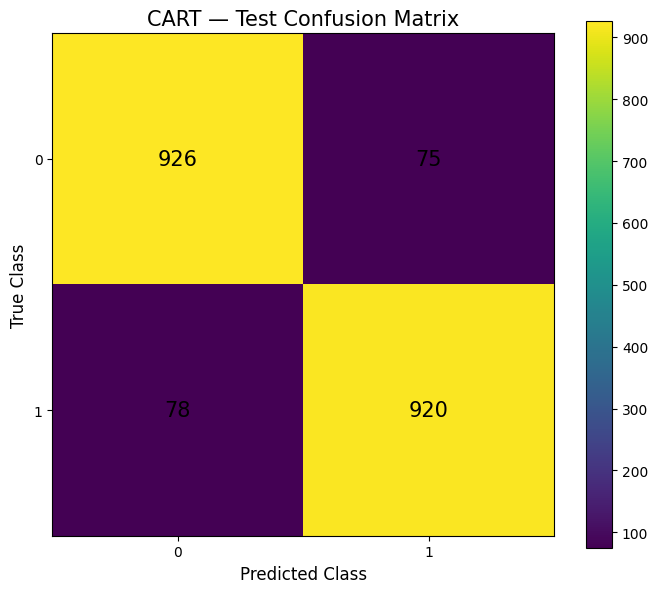

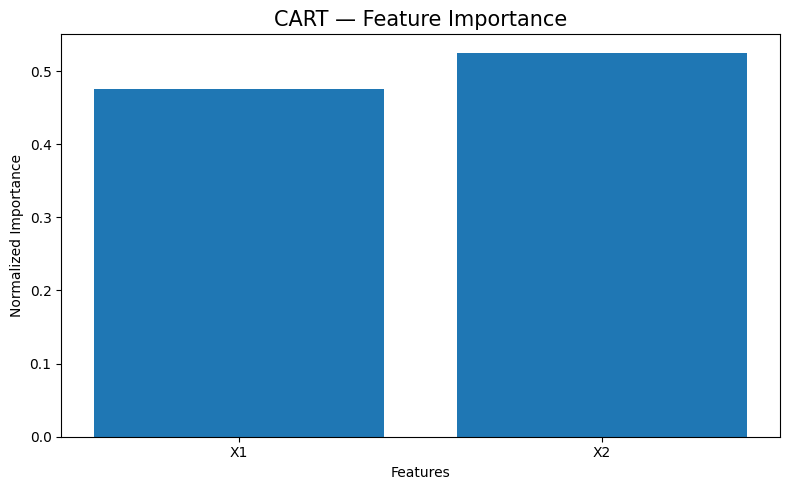

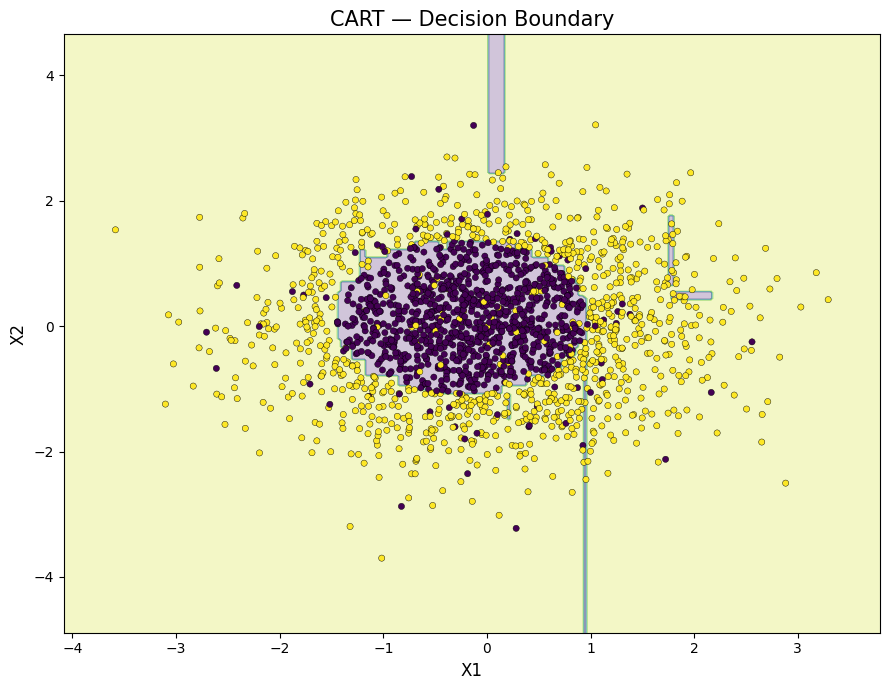

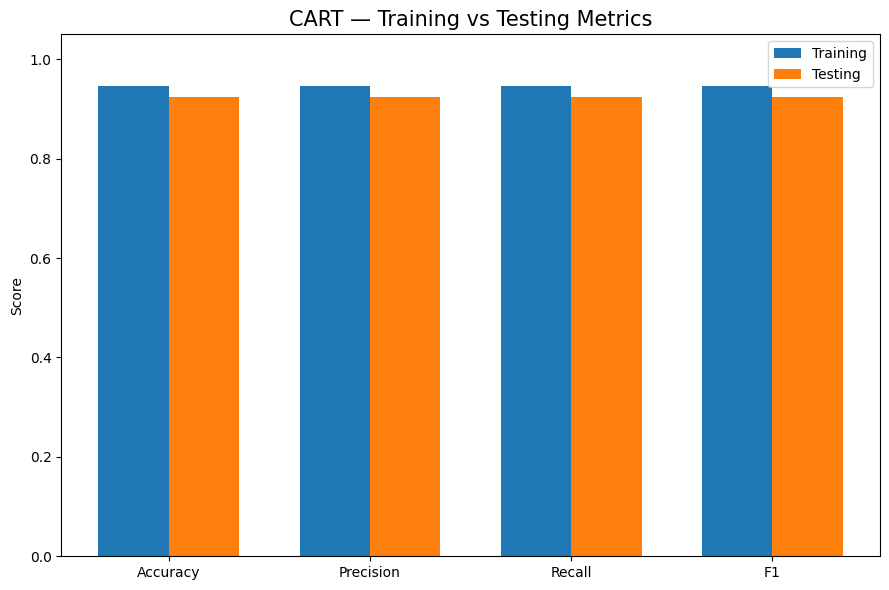

In [3]:
# ============================================================
# CART CLASSIFICATION FROM SCRATCH
# ============================================================
# Libraries:
#   - NumPy
#   - Matplotlib
#
# NO sklearn is used.
#
# CART = Classification and Regression Trees
#
# This implementation is for:
#   CART CLASSIFICATION
#
# Core criterion:
#   Gini Impurity
#
# Split:
#   Binary split
#
# Includes:
#   1. Gini Impurity
#   2. Weighted Gini Impurity
#   3. Gini Gain
#   4. Numerical feature splitting
#   5. Binary recursive tree construction
#   6. Stopping criteria
#   7. Prediction
#   8. Accuracy
#   9. Precision
#  10. Recall
#  11. F1 Score
#  12. Confusion Matrix
#  13. Feature Importance
#  14. Decision Boundary
#  15. Training vs Testing Metrics
#
# Dataset:
#   10,000 samples
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        feature_name=None,
        threshold=None,
        is_leaf=False,
        prediction=None,
        class_counts=None,
        depth=0
    ):

        self.feature_index = feature_index
        self.feature_name = feature_name
        self.threshold = threshold

        self.is_leaf = is_leaf
        self.prediction = prediction

        self.class_counts = class_counts

        self.depth = depth

        self.left = None
        self.right = None


# ============================================================
# 2. CART CLASSIFIER
# ============================================================

class CARTClassifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_impurity_decrease=0.0
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.min_impurity_decrease = (
            min_impurity_decrease
        )

        self.root = None

        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

        self.feature_names_ = None
        self.feature_importances_ = None

        self.tree_depth_ = 0
        self.n_leaves_ = 0


    # ========================================================
    # GINI IMPURITY
    # ========================================================

    def _gini(self, y):

        if len(y) == 0:

            return 0.0

        _, counts = np.unique(
            y,
            return_counts=True
        )

        probabilities = (
            counts / len(y)
        )

        gini = (
            1.0
            -
            np.sum(
                probabilities ** 2
            )
        )

        return gini


    # ========================================================
    # WEIGHTED GINI
    # ========================================================

    def _weighted_gini(
        self,
        y_left,
        y_right
    ):

        n = (
            len(y_left)
            +
            len(y_right)
        )

        if n == 0:

            return 0.0

        left_weight = (
            len(y_left) / n
        )

        right_weight = (
            len(y_right) / n
        )

        weighted_gini = (
            left_weight
            *
            self._gini(y_left)
            +
            right_weight
            *
            self._gini(y_right)
        )

        return weighted_gini


    # ========================================================
    # GINI GAIN
    # ========================================================

    def _gini_gain(
        self,
        y,
        y_left,
        y_right
    ):

        parent_gini = (
            self._gini(y)
        )

        child_gini = (
            self._weighted_gini(
                y_left,
                y_right
            )
        )

        gain = (
            parent_gini
            -
            child_gini
        )

        return gain


    # ========================================================
    # BEST NUMERICAL SPLIT
    # ========================================================

    def _best_numeric_split(
        self,
        X_column,
        y
    ):

        unique_values = np.unique(
            X_column
        )

        if len(unique_values) <= 1:

            return None, -np.inf

        # Candidate thresholds are
        # midpoints between consecutive
        # unique values.

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_threshold = None

        best_gain = -np.inf


        for threshold in thresholds:

            left_mask = (
                X_column
                <=
                threshold
            )

            right_mask = (
                X_column
                >
                threshold
            )

            left_count = np.sum(
                left_mask
            )

            right_count = np.sum(
                right_mask
            )


            # Minimum leaf constraint

            if (
                left_count
                <
                self.min_samples_leaf
                or
                right_count
                <
                self.min_samples_leaf
            ):

                continue


            y_left = y[
                left_mask
            ]

            y_right = y[
                right_mask
            ]


            gain = self._gini_gain(
                y,
                y_left,
                y_right
            )


            if gain > best_gain:

                best_gain = gain

                best_threshold = (
                    threshold
                )


        return (
            best_threshold,
            best_gain
        )


    # ========================================================
    # FIND BEST SPLIT
    # ========================================================

    def _best_split(
        self,
        X,
        y
    ):

        best_feature = None

        best_threshold = None

        best_gain = -np.inf


        for feature_index in range(
            self.n_features_
        ):

            column = X[
                :,
                feature_index
            ]


            threshold, gain = (
                self._best_numeric_split(
                    column,
                    y
                )
            )


            if gain > best_gain:

                best_gain = gain

                best_feature = (
                    feature_index
                )

                best_threshold = (
                    threshold
                )


        return (
            best_feature,
            best_threshold,
            best_gain
        )


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(
        self,
        y
    ):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        majority_class = (
            self._majority_class(y)
        )


        class_counts = {}

        for c in self.classes_:

            class_counts[c] = np.sum(
                y == c
            )


        node = TreeNode(
            is_leaf=False,
            prediction=majority_class,
            class_counts=class_counts,
            depth=depth
        )


        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 1
        # Pure node
        # ----------------------------------------------------

        if len(np.unique(y)) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 2
        # Maximum depth
        # ----------------------------------------------------

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 3
        # Minimum samples
        # ----------------------------------------------------

        if (
            len(y)
            <
            self.min_samples_split
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # FIND BEST BINARY SPLIT
        # ----------------------------------------------------

        (
            feature_index,
            threshold,
            gain
        ) = self._best_split(
            X,
            y
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 4
        # No useful split
        # ----------------------------------------------------

        if (
            feature_index is None
            or
            threshold is None
            or
            gain
            <=
            self.min_impurity_decrease
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STORE SPLIT
        # ----------------------------------------------------

        node.feature_index = (
            feature_index
        )

        node.feature_name = (
            self.feature_names_[
                feature_index
            ]
        )

        node.threshold = threshold


        # ----------------------------------------------------
        # FEATURE IMPORTANCE
        # ----------------------------------------------------

        self.feature_importances_[
            feature_index
        ] += (
            gain * len(y)
        )


        # ----------------------------------------------------
        # BINARY SPLIT
        # ----------------------------------------------------

        left_mask = (
            X[:, feature_index]
            <=
            threshold
        )

        right_mask = (
            X[:, feature_index]
            >
            threshold
        )


        X_left = X[
            left_mask
        ]

        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]

        y_right = y[
            right_mask
        ]


        # ----------------------------------------------------
        # MINIMUM LEAF CHECK
        # ----------------------------------------------------

        if (
            len(y_left)
            <
            self.min_samples_leaf
            or
            len(y_right)
            <
            self.min_samples_leaf
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # RECURSIVE BUILDING
        # ----------------------------------------------------

        node.left = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )


        node.right = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(X)

        y = np.asarray(y)


        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )


        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )


        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )


        self.n_features_ = (
            X.shape[1]
        )


        self.classes_ = np.unique(
            y
        )


        self.n_classes_ = (
            len(self.classes_)
        )


        if feature_names is None:

            self.feature_names_ = [
                f"Feature_{i}"
                for i in range(
                    self.n_features_
                )
            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        self.root = self._build_tree(
            X,
            y
        )


        # Normalize feature importance

        total = np.sum(
            self.feature_importances_
        )


        if total > 0:

            self.feature_importances_ /= (
                total
            )


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        feature_value = x[
            node.feature_index
        ]


        if (
            feature_value
            <=
            node.threshold
        ):

            return self._predict_sample(
                x,
                node.left
            )

        else:

            return self._predict_sample(
                x,
                node.right
            )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)

        predictions = []


        for x in X:

            predictions.append(
                self._predict_sample(
                    x,
                    self.root
                )
            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )

        return np.mean(
            predictions == y
        )


# ============================================================
# 3. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    train_indices = []

    test_indices = []


    # Stratified split

    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(
            len(indices)
            *
            test_size
        )


        test_indices.extend(
            indices[:n_test]
        )


        train_indices.extend(
            indices[n_test:]
        )


    train_indices = np.asarray(
        train_indices
    )

    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )

    rng.shuffle(
        test_indices
    )


    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# 4. CONFUSION MATRIX FROM SCRATCH
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )


    matrix = np.zeros(
        (
            len(labels),
            len(labels)
        ),
        dtype=int
    )


    label_to_index = {
        label: i
        for i, label in enumerate(
            labels
        )
    }


    for true, pred in zip(
        y_true,
        y_pred
    ):

        matrix[
            label_to_index[true],
            label_to_index[pred]
        ] += 1


    return matrix, labels


# ============================================================
# 5. CLASSIFICATION METRICS FROM SCRATCH
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (
        confusion_matrix_manual(
            y_true,
            y_pred
        )
    )


    accuracy = (
        np.trace(cm)
        /
        np.sum(cm)
    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[i, i]


        FP = (
            np.sum(cm[:, i])
            -
            TP
        )


        FN = (
            np.sum(cm[i, :])
            -
            TP
        )


        precision = (
            TP / (TP + FP)
            if (TP + FP) > 0
            else 0.0
        )


        recall = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else 0.0
        )


        if (
            precision + recall
            >
            0
        ):

            f1 = (
                2
                *
                precision
                *
                recall
                /
                (
                    precision
                    +
                    recall
                )
            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )

        recalls.append(
            recall
        )

        f1_scores.append(
            f1
        )


    macro_precision = np.mean(
        precisions
    )


    macro_recall = np.mean(
        recalls
    )


    macro_f1 = np.mean(
        f1_scores
    )


    return {
        "accuracy": accuracy,
        "precision": macro_precision,
        "recall": macro_recall,
        "f1": macro_f1,
        "labels": labels,
        "confusion_matrix": cm,
        "per_class_precision": precisions,
        "per_class_recall": recalls,
        "per_class_f1": f1_scores
    }


# ============================================================
# 6. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Generate features
# ------------------------------------------------------------

X = rng.normal(
    0,
    1,
    size=(
        n_samples,
        2
    )
)


x1 = X[:, 0]

x2 = X[:, 1]


# ------------------------------------------------------------
# Nonlinear classification function
# ------------------------------------------------------------

decision_function = (
    x1**2
    +
    x2**2
    +
    0.5 * x1
    -
    0.3 * x2
)


y = (
    decision_function
    >
    1.4
).astype(int)


# ------------------------------------------------------------
# Add 5% label noise
# ------------------------------------------------------------

noise = (
    rng.random(
        n_samples
    )
    <
    0.05
)


y[noise] = (
    1 - y[noise]
)


feature_names = [
    "X1",
    "X2"
]


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 8. CREATE CART MODEL
# ============================================================

model = CARTClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    min_impurity_decrease=1e-6
)


# ============================================================
# 9. TRAIN CART
# ============================================================

model.fit(
    X_train,
    y_train,
    feature_names=feature_names
)


# ============================================================
# 10. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 11. EVALUATION
# ============================================================

train_metrics = (
    classification_metrics(
        y_train,
        y_train_pred
    )
)


test_metrics = (
    classification_metrics(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 12. PRINT RESULTS
# ============================================================

print("=" * 70)

print(
    "CART CLASSIFICATION — FROM SCRATCH"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Number classes   : {model.n_classes_}"
)


print(
    f"Tree depth       : {model.tree_depth_}"
)


print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 13. PER-CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(
    test_metrics["labels"]
):

    print(
        f"Class {label}: "
        f"Precision = "
        f"{test_metrics['per_class_precision'][i]:.4f}, "
        f"Recall = "
        f"{test_metrics['per_class_recall'][i]:.4f}, "
        f"F1 = "
        f"{test_metrics['per_class_f1'][i]:.4f}"
    )


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]

labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 15. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(
    "CART — Test Confusion Matrix",
    fontsize=15
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "True Class",
    fontsize=12
)


plt.xticks(
    range(len(labels)),
    labels
)


plt.yticks(
    range(len(labels)),
    labels
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=15
        )


plt.colorbar()


plt.tight_layout()


plt.show()


# ============================================================
# 16. FEATURE IMPORTANCE
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model.feature_names_,
    model.feature_importances_
)


plt.title(
    "CART — Feature Importance",
    fontsize=15
)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Normalized Importance"
)


plt.tight_layout()


plt.show()


# ============================================================
# 17. DECISION BOUNDARY
# ============================================================

x_min = (
    X[:, 0].min()
    -
    0.5
)


x_max = (
    X[:, 0].max()
    +
    0.5
)


y_min = (
    X[:, 1].min()
    -
    0.5
)


y_max = (
    X[:, 1].max()
    +
    0.5
)


resolution = 300


xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        resolution
    ),
    np.linspace(
        y_min,
        y_max,
        resolution
    )
)


grid = np.column_stack(
    [
        xx.ravel(),
        yy.ravel()
    ]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(9, 7)
)


plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25
)


plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    s=20,
    edgecolors="black",
    linewidths=0.3
)


plt.title(
    "CART — Decision Boundary",
    fontsize=15
)


plt.xlabel(
    "X1",
    fontsize=12
)


plt.ylabel(
    "X2",
    fontsize=12
)


plt.tight_layout()


plt.show()


# ============================================================
# 18. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]


train_values = [
    train_metrics["accuracy"],
    train_metrics["precision"],
    train_metrics["recall"],
    train_metrics["f1"]
]


test_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"]
]


x = np.arange(
    len(metric_names)
)


width = 0.35


plt.figure(
    figsize=(9, 6)
)


plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing"
)


plt.xticks(
    x,
    metric_names
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)


plt.title(
    "CART — Training vs Testing Metrics",
    fontsize=15
)


plt.legend()


plt.tight_layout()


plt.show()

CART REGRESSION — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,000
Testing samples  : 2,000
Number features  : 2
Tree depth       : 10
Number of leaves : 576

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
MAE  : 1.1222
MSE  : 2.0458
RMSE : 1.4303
R²   : 0.9870

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
MAE  : 1.4001
MSE  : 3.1398
RMSE : 1.7719
R²   : 0.9809

----------------------------------------------------------------------
FEATURE IMPORTANCE
----------------------------------------------------------------------
X1             0.673172
X2             0.326828


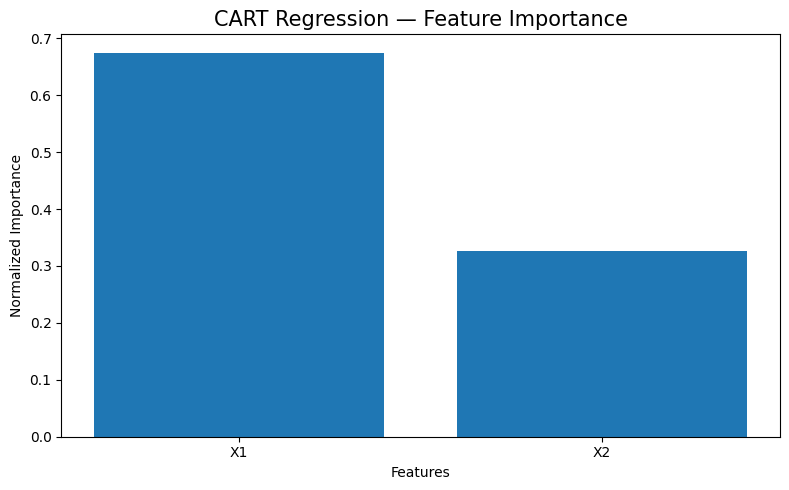

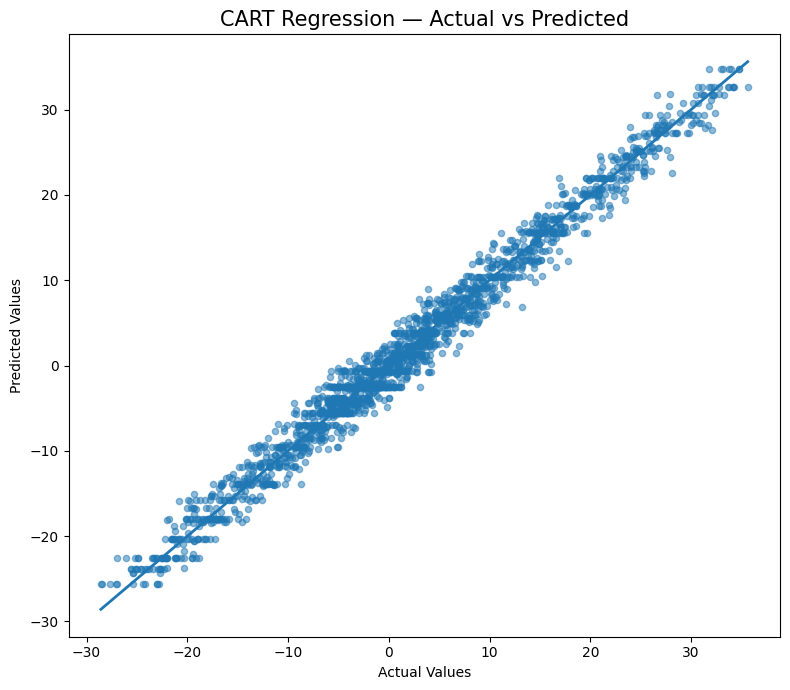

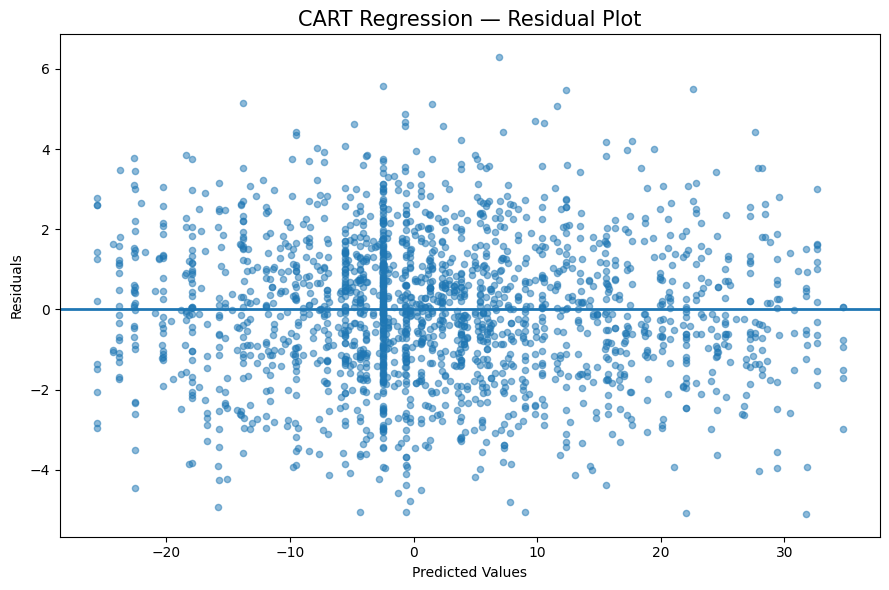

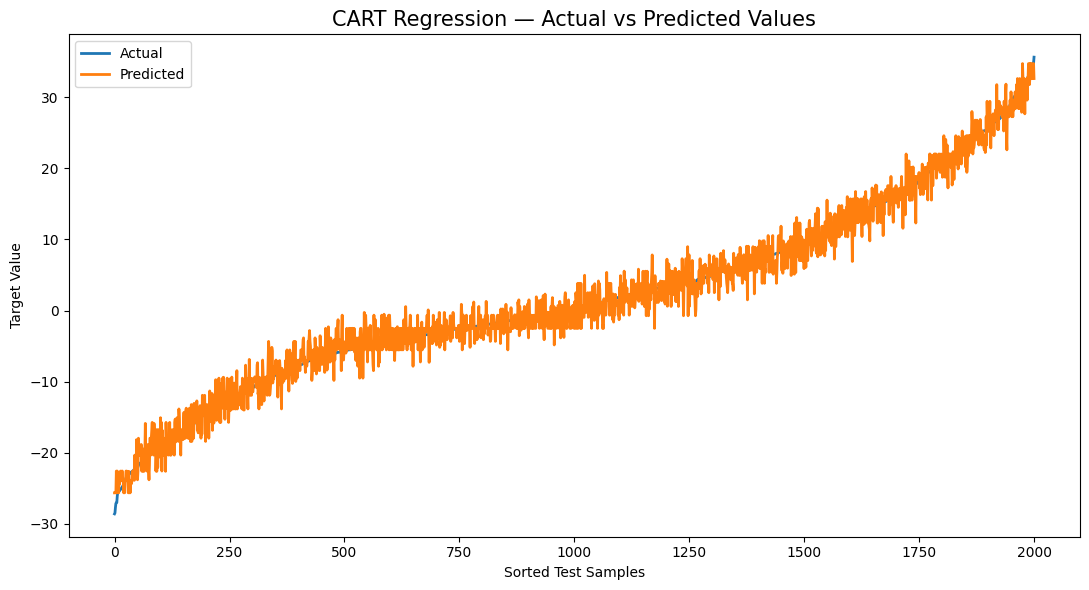

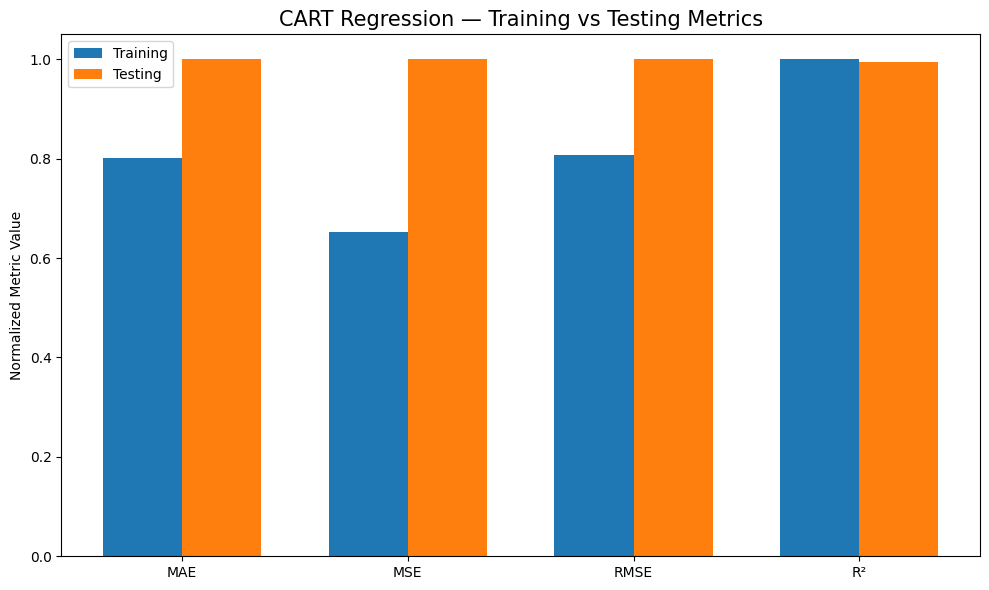

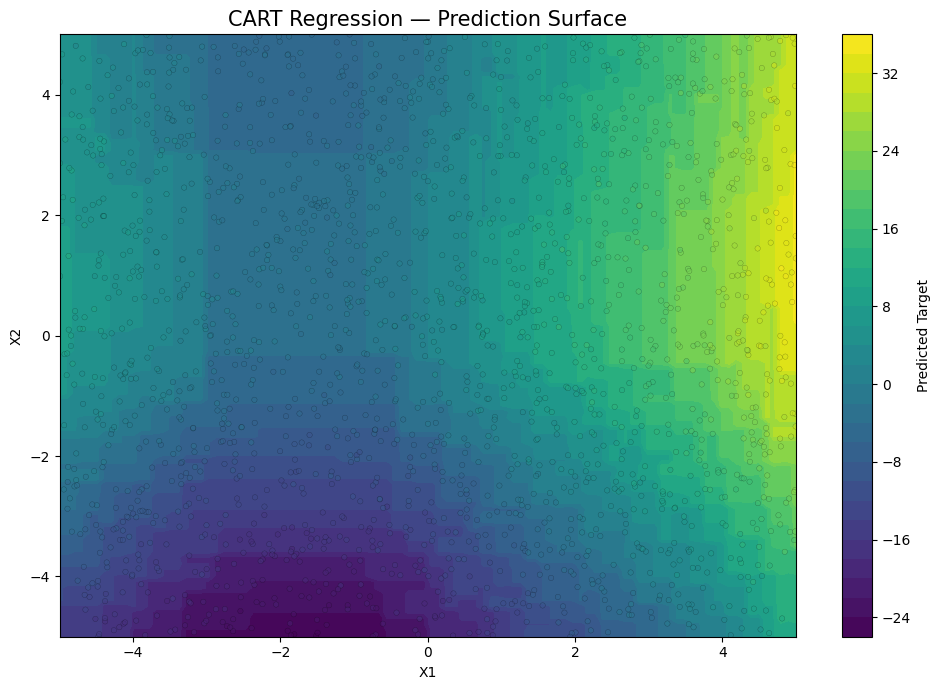

In [4]:
# ============================================================
# CART REGRESSION FROM SCRATCH
# ============================================================
# Libraries:
#   - NumPy
#   - Matplotlib
#
# NO sklearn is used.
#
# CART = Classification and Regression Trees
#
# This implementation is for:
#   CART REGRESSION
#
# Core criterion:
#   Mean Squared Error / Variance Reduction
#
# Split:
#   Binary split
#
# Includes:
#   1. Variance
#   2. Mean Squared Error
#   3. Variance / MSE Reduction
#   4. Numerical feature splitting
#   5. Binary recursive tree construction
#   6. Stopping criteria
#   7. Leaf prediction using mean
#   8. Prediction
#   9. MAE
#  10. MSE
#  11. RMSE
#  12. R²
#  13. Feature Importance
#  14. Actual vs Predicted
#  15. Residual Plot
#  16. Prediction Plot
#  17. Training vs Testing Metrics
#
# Dataset:
#   10,000 samples
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        feature_name=None,
        threshold=None,
        is_leaf=False,
        prediction=None,
        depth=0,
        n_samples=0
    ):

        self.feature_index = feature_index
        self.feature_name = feature_name
        self.threshold = threshold

        self.is_leaf = is_leaf

        # For regression:
        # prediction = mean target value
        self.prediction = prediction

        self.depth = depth
        self.n_samples = n_samples

        self.left = None
        self.right = None


# ============================================================
# 2. CART REGRESSOR
# ============================================================

class CARTRegressor:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_impurity_decrease=0.0
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.min_impurity_decrease = (
            min_impurity_decrease
        )

        self.root = None

        self.n_features_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # MSE
    # ========================================================

    def _mse(self, y):

        if len(y) == 0:

            return 0.0

        mean_value = np.mean(y)

        mse = np.mean(
            (y - mean_value) ** 2
        )

        return mse


    # ========================================================
    # VARIANCE
    # ========================================================

    def _variance(self, y):

        if len(y) == 0:

            return 0.0

        return np.var(y)


    # ========================================================
    # WEIGHTED CHILD MSE
    # ========================================================

    def _weighted_mse(
        self,
        y_left,
        y_right
    ):

        n = (
            len(y_left)
            +
            len(y_right)
        )

        if n == 0:

            return 0.0

        left_weight = (
            len(y_left) / n
        )

        right_weight = (
            len(y_right) / n
        )

        weighted_mse = (
            left_weight
            *
            self._mse(y_left)
            +
            right_weight
            *
            self._mse(y_right)
        )

        return weighted_mse


    # ========================================================
    # MSE REDUCTION
    # ========================================================

    def _mse_reduction(
        self,
        y,
        y_left,
        y_right
    ):

        parent_mse = self._mse(y)

        child_mse = (
            self._weighted_mse(
                y_left,
                y_right
            )
        )

        reduction = (
            parent_mse
            -
            child_mse
        )

        return reduction


    # ========================================================
    # BEST NUMERICAL SPLIT
    # ========================================================

    def _best_numeric_split(
        self,
        X_column,
        y
    ):

        unique_values = np.unique(
            X_column
        )

        if len(unique_values) <= 1:

            return None, -np.inf


        # Candidate thresholds are
        # midpoints between consecutive
        # unique feature values.

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0


        best_threshold = None

        best_reduction = -np.inf


        for threshold in thresholds:

            left_mask = (
                X_column
                <=
                threshold
            )

            right_mask = (
                X_column
                >
                threshold
            )


            left_count = np.sum(
                left_mask
            )

            right_count = np.sum(
                right_mask
            )


            # ------------------------------------------------
            # Minimum leaf constraint
            # ------------------------------------------------

            if (
                left_count
                <
                self.min_samples_leaf
                or
                right_count
                <
                self.min_samples_leaf
            ):

                continue


            y_left = y[
                left_mask
            ]

            y_right = y[
                right_mask
            ]


            reduction = (
                self._mse_reduction(
                    y,
                    y_left,
                    y_right
                )
            )


            if reduction > best_reduction:

                best_reduction = (
                    reduction
                )

                best_threshold = (
                    threshold
                )


        return (
            best_threshold,
            best_reduction
        )


    # ========================================================
    # FIND BEST SPLIT
    # ========================================================

    def _best_split(
        self,
        X,
        y
    ):

        best_feature = None

        best_threshold = None

        best_reduction = -np.inf


        for feature_index in range(
            self.n_features_
        ):

            column = X[
                :,
                feature_index
            ]


            threshold, reduction = (
                self._best_numeric_split(
                    column,
                    y
                )
            )


            if reduction > best_reduction:

                best_reduction = (
                    reduction
                )

                best_feature = (
                    feature_index
                )

                best_threshold = (
                    threshold
                )


        return (
            best_feature,
            best_threshold,
            best_reduction
        )


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        # ----------------------------------------------------
        # Regression leaf prediction
        # ----------------------------------------------------

        prediction = np.mean(y)


        node = TreeNode(
            is_leaf=False,
            prediction=prediction,
            depth=depth,
            n_samples=len(y)
        )


        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 1
        # Maximum depth
        # ----------------------------------------------------

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 2
        # Minimum samples
        # ----------------------------------------------------

        if (
            len(y)
            <
            self.min_samples_split
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STOPPING CONDITION 3
        # No variance
        # ----------------------------------------------------

        if self._variance(y) <= 1e-15:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # FIND BEST SPLIT
        # ----------------------------------------------------

        (
            feature_index,
            threshold,
            reduction
        ) = self._best_split(
            X,
            y
        )


        # ----------------------------------------------------
        # STOPPING CONDITION 4
        # No useful split
        # ----------------------------------------------------

        if (
            feature_index is None
            or
            threshold is None
            or
            reduction
            <=
            self.min_impurity_decrease
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # STORE SPLIT
        # ----------------------------------------------------

        node.feature_index = (
            feature_index
        )

        node.feature_name = (
            self.feature_names_[
                feature_index
            ]
        )

        node.threshold = threshold


        # ----------------------------------------------------
        # FEATURE IMPORTANCE
        # ----------------------------------------------------

        self.feature_importances_[
            feature_index
        ] += (
            reduction
            *
            len(y)
        )


        # ----------------------------------------------------
        # BINARY SPLIT
        # ----------------------------------------------------

        left_mask = (
            X[:, feature_index]
            <=
            threshold
        )

        right_mask = (
            X[:, feature_index]
            >
            threshold
        )


        X_left = X[
            left_mask
        ]

        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]

        y_right = y[
            right_mask
        ]


        # ----------------------------------------------------
        # MINIMUM LEAF CHECK
        # ----------------------------------------------------

        if (
            len(y_left)
            <
            self.min_samples_leaf
            or
            len(y_right)
            <
            self.min_samples_leaf
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ----------------------------------------------------
        # RECURSIVE BUILDING
        # ----------------------------------------------------

        node.left = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )


        node.right = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(X)

        y = np.asarray(y)


        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )


        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )


        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )


        self.n_features_ = (
            X.shape[1]
        )


        if feature_names is None:

            self.feature_names_ = [
                f"Feature_{i}"
                for i in range(
                    self.n_features_
                )
            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        self.root = self._build_tree(
            X,
            y
        )


        # ----------------------------------------------------
        # Normalize feature importance
        # ----------------------------------------------------

        total = np.sum(
            self.feature_importances_
        )


        if total > 0:

            self.feature_importances_ /= (
                total
            )


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        feature_value = x[
            node.feature_index
        ]


        if (
            feature_value
            <=
            node.threshold
        ):

            return self._predict_sample(
                x,
                node.left
            )

        else:

            return self._predict_sample(
                x,
                node.right
            )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)

        predictions = []


        for x in X:

            predictions.append(
                self._predict_sample(
                    x,
                    self.root
                )
            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )


        ss_res = np.sum(
            (y - predictions) ** 2
        )


        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )


        if ss_tot == 0:

            return 1.0


        return (
            1
            -
            ss_res / ss_tot
        )


# ============================================================
# 3. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    indices = np.arange(
        len(X)
    )


    rng.shuffle(
        indices
    )


    n_test = int(
        len(X)
        *
        test_size
    )


    test_indices = (
        indices[:n_test]
    )

    train_indices = (
        indices[n_test:]
    )


    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# 4. REGRESSION METRICS FROM SCRATCH
# ============================================================

def regression_metrics(
    y_true,
    y_pred
):

    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(
            y_true
            -
            y_pred
        )
    )


    # --------------------------------------------------------
    # MSE
    # --------------------------------------------------------

    mse = np.mean(
        (
            y_true
            -
            y_pred
        ) ** 2
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        mse
    )


    # --------------------------------------------------------
    # R²
    # --------------------------------------------------------

    ss_res = np.sum(
        (
            y_true
            -
            y_pred
        ) ** 2
    )


    ss_tot = np.sum(
        (
            y_true
            -
            np.mean(y_true)
        ) ** 2
    )


    if ss_tot == 0:

        r2 = 1.0

    else:

        r2 = (
            1
            -
            ss_res / ss_tot
        )


    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2
    }


# ============================================================
# 5. CREATE LARGE REGRESSION DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Generate two features
# ------------------------------------------------------------

X = rng.uniform(
    -5,
    5,
    size=(
        n_samples,
        2
    )
)


x1 = X[:, 0]

x2 = X[:, 1]


# ------------------------------------------------------------
# Nonlinear regression function
# ------------------------------------------------------------

y = (
    3.0 * x1
    +
    2.0 * x2
    +
    0.8 * x1**2
    -
    0.5 * x2**2
    +
    2.0 * np.sin(x1)
    +
    1.5 * np.cos(x2)
)


# ------------------------------------------------------------
# Add Gaussian noise
# ------------------------------------------------------------

noise = rng.normal(
    0,
    1.5,
    size=n_samples
)


y = y + noise


feature_names = [
    "X1",
    "X2"
]


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 7. CREATE CART REGRESSOR
# ============================================================

model = CARTRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    min_impurity_decrease=1e-6
)


# ============================================================
# 8. TRAIN CART REGRESSOR
# ============================================================

model.fit(
    X_train,
    y_train,
    feature_names=feature_names
)


# ============================================================
# 9. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 10. EVALUATION
# ============================================================

train_metrics = (
    regression_metrics(
        y_train,
        y_train_pred
    )
)


test_metrics = (
    regression_metrics(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 11. PRINT RESULTS
# ============================================================

print("=" * 70)

print(
    "CART REGRESSION — FROM SCRATCH"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Tree depth       : {model.tree_depth_}"
)


print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(
    f"MAE  : "
    f"{train_metrics['mae']:.4f}"
)


print(
    f"MSE  : "
    f"{train_metrics['mse']:.4f}"
)


print(
    f"RMSE : "
    f"{train_metrics['rmse']:.4f}"
)


print(
    f"R²   : "
    f"{train_metrics['r2']:.4f}"
)


# ============================================================
# TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(
    f"MAE  : "
    f"{test_metrics['mae']:.4f}"
)


print(
    f"MSE  : "
    f"{test_metrics['mse']:.4f}"
)


print(
    f"RMSE : "
    f"{test_metrics['rmse']:.4f}"
)


print(
    f"R²   : "
    f"{test_metrics['r2']:.4f}"
)


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

print()

print("-" * 70)

print(
    "FEATURE IMPORTANCE"
)

print("-" * 70)


for feature, importance in zip(
    model.feature_names_,
    model.feature_importances_
):

    print(
        f"{feature:<15}"
        f"{importance:.6f}"
    )


# ============================================================
# 13. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model.feature_names_,
    model.feature_importances_
)


plt.title(
    "CART Regression — Feature Importance",
    fontsize=15
)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Normalized Importance"
)


plt.tight_layout()

plt.show()


# ============================================================
# 14. ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 7)
)


plt.scatter(
    y_test,
    y_test_pred,
    s=20,
    alpha=0.5
)


min_value = min(
    y_test.min(),
    y_test_pred.min()
)


max_value = max(
    y_test.max(),
    y_test_pred.max()
)


plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2
)


plt.title(
    "CART Regression — Actual vs Predicted",
    fontsize=15
)


plt.xlabel(
    "Actual Values"
)


plt.ylabel(
    "Predicted Values"
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. RESIDUAL PLOT
# ============================================================

residuals = (
    y_test
    -
    y_test_pred
)


plt.figure(
    figsize=(9, 6)
)


plt.scatter(
    y_test_pred,
    residuals,
    s=20,
    alpha=0.5
)


plt.axhline(
    0,
    linewidth=2
)


plt.title(
    "CART Regression — Residual Plot",
    fontsize=15
)


plt.xlabel(
    "Predicted Values"
)


plt.ylabel(
    "Residuals"
)


plt.tight_layout()

plt.show()


# ============================================================
# 16. PREDICTED VS SAMPLE INDEX
# ============================================================

sorted_indices = np.argsort(
    y_test
)


plt.figure(
    figsize=(11, 6)
)


plt.plot(
    np.arange(len(y_test)),
    y_test[sorted_indices],
    label="Actual",
    linewidth=2
)


plt.plot(
    np.arange(len(y_test)),
    y_test_pred[sorted_indices],
    label="Predicted",
    linewidth=2
)


plt.title(
    "CART Regression — Actual vs Predicted Values",
    fontsize=15
)


plt.xlabel(
    "Sorted Test Samples"
)


plt.ylabel(
    "Target Value"
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 17. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [
    "MAE",
    "MSE",
    "RMSE",
    "R²"
]


train_values = [
    train_metrics["mae"],
    train_metrics["mse"],
    train_metrics["rmse"],
    train_metrics["r2"]
]


test_values = [
    test_metrics["mae"],
    test_metrics["mse"],
    test_metrics["rmse"],
    test_metrics["r2"]
]


# Because MAE/MSE/RMSE and R² have
# different scales, normalize each metric
# independently for visualization.

train_plot_values = []

test_plot_values = []


for train_value, test_value in zip(
    train_values,
    test_values
):

    maximum = max(
        abs(train_value),
        abs(test_value),
        1e-12
    )


    train_plot_values.append(
        train_value / maximum
    )


    test_plot_values.append(
        test_value / maximum
    )


x = np.arange(
    len(metric_names)
)


width = 0.35


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    x - width / 2,
    train_plot_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    test_plot_values,
    width,
    label="Testing"
)


plt.xticks(
    x,
    metric_names
)


plt.ylabel(
    "Normalized Metric Value"
)


plt.title(
    "CART Regression — Training vs Testing Metrics",
    fontsize=15
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 18. 2D PREDICTION SURFACE
# ============================================================

resolution = 100


x1_grid = np.linspace(
    X[:, 0].min(),
    X[:, 0].max(),
    resolution
)


x2_grid = np.linspace(
    X[:, 1].min(),
    X[:, 1].max(),
    resolution
)


xx, yy = np.meshgrid(
    x1_grid,
    x2_grid
)


grid = np.column_stack(
    [
        xx.ravel(),
        yy.ravel()
    ]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(10, 7)
)


contour = plt.contourf(
    xx,
    yy,
    grid_predictions,
    levels=30
)


plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    s=15,
    edgecolors="black",
    linewidths=0.2,
    alpha=0.5
)


plt.colorbar(
    contour,
    label="Predicted Target"
)


plt.title(
    "CART Regression — Prediction Surface",
    fontsize=15
)


plt.xlabel(
    "X1"
)


plt.ylabel(
    "X2"
)


plt.tight_layout()

plt.show()

C4.5 DECISION TREE — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 2
Number classes   : 2
Tree depth       : 10
Number of leaves : 63

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9161
Precision : 0.9197
Recall    : 0.9161
F1 Score  : 0.9160

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9055
Precision : 0.9071
Recall    : 0.9054
F1 Score  : 0.9053

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.8816, Recall = 0.9371, F1 = 0.9085
Class 1: Precision = 0.9326, Recall = 0.8737, F1 = 0.9022

---------------------------------------------

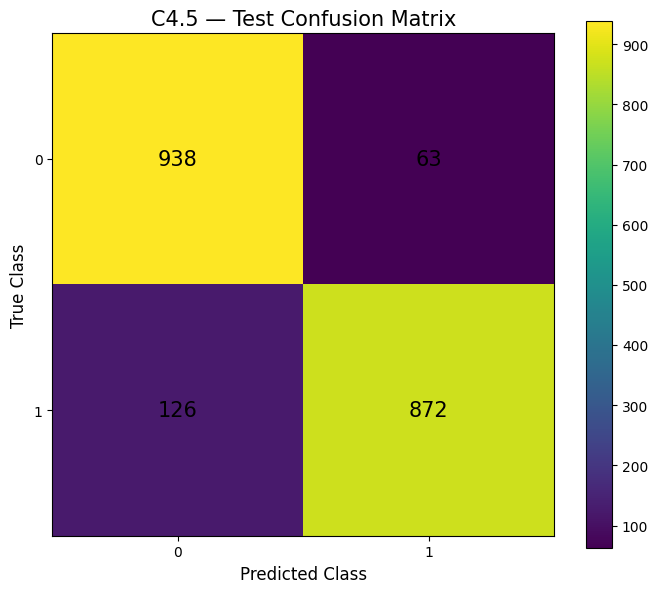

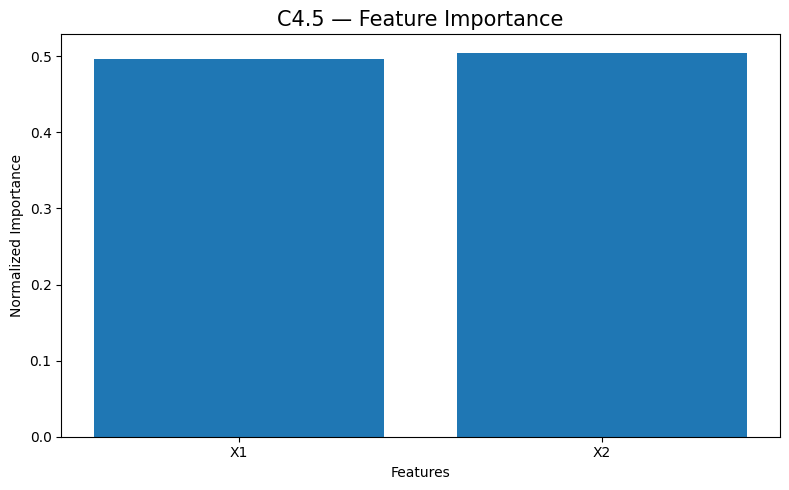

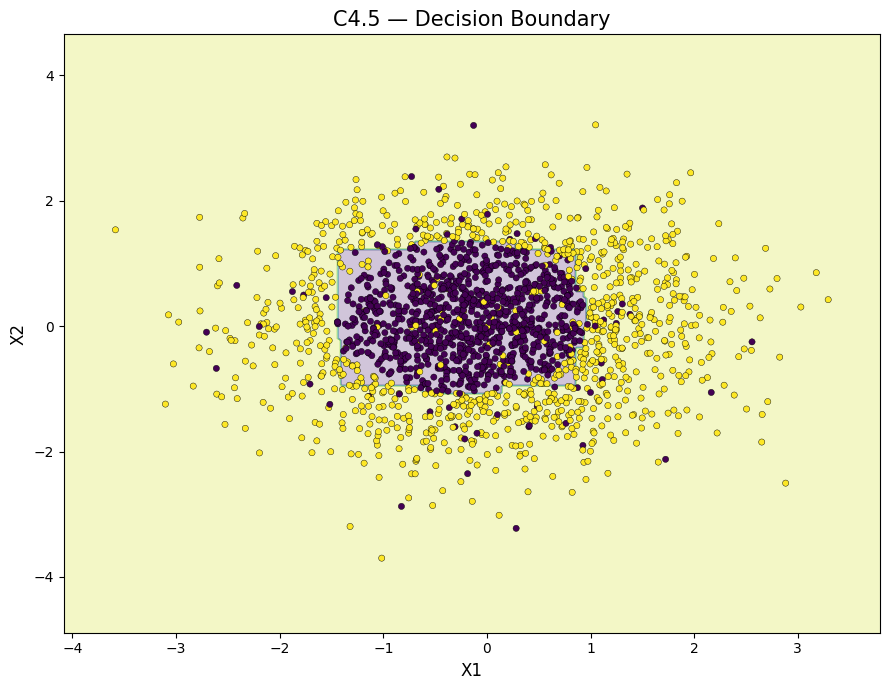

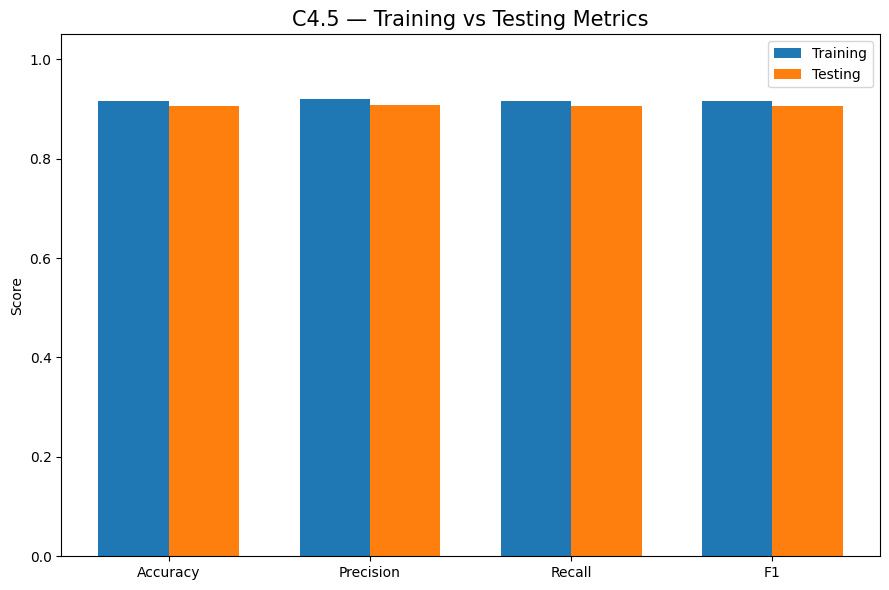

In [5]:
# ============================================================
# C4.5 DECISION TREE CLASSIFIER FROM SCRATCH
# ============================================================
# Libraries:
#   - NumPy
#   - Matplotlib
#
# NO sklearn is used.
#
# C4.5 CORE:
#   Entropy + Gain Ratio
#
# Includes:
#   1. Entropy
#   2. Information Gain
#   3. Split Information
#   4. Gain Ratio
#   5. Numerical feature splitting
#   6. Binary threshold splits
#   7. Recursive tree construction
#   8. Stopping criteria
#   9. Prediction
#  10. Accuracy
#  11. Precision
#  12. Recall
#  13. F1 Score
#  14. Confusion Matrix
#  15. Feature Importance
#  16. Decision Boundary
#  17. Training vs Testing Metrics
#
# Dataset:
#   10,000 samples
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        feature_name=None,
        threshold=None,
        is_leaf=False,
        prediction=None,
        class_counts=None,
        depth=0
    ):

        self.feature_index = feature_index
        self.feature_name = feature_name
        self.threshold = threshold

        self.is_leaf = is_leaf

        self.prediction = prediction

        self.class_counts = class_counts

        self.depth = depth

        self.left = None
        self.right = None


# ============================================================
# 2. C4.5 CLASSIFIER
# ============================================================

class C45Classifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_gain_ratio=1e-10
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.min_gain_ratio = (
            min_gain_ratio
        )

        self.root = None

        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

        self.feature_names_ = None
        self.feature_importances_ = None

        self.tree_depth_ = 0
        self.n_leaves_ = 0


    # ========================================================
    # ENTROPY
    # ========================================================

    def _entropy(self, y):

        if len(y) == 0:

            return 0.0

        _, counts = np.unique(
            y,
            return_counts=True
        )

        probabilities = (
            counts / len(y)
        )

        entropy = 0.0

        for p in probabilities:

            if p > 0:

                entropy -= (
                    p * np.log2(p)
                )

        return entropy


    # ========================================================
    # INFORMATION GAIN
    # ========================================================

    def _information_gain(
        self,
        y,
        y_left,
        y_right
    ):

        parent_entropy = (
            self._entropy(y)
        )

        n = len(y)

        if (
            len(y_left) == 0
            or
            len(y_right) == 0
        ):

            return 0.0

        left_weight = (
            len(y_left) / n
        )

        right_weight = (
            len(y_right) / n
        )

        child_entropy = (
            left_weight
            *
            self._entropy(y_left)
            +
            right_weight
            *
            self._entropy(y_right)
        )

        gain = (
            parent_entropy
            -
            child_entropy
        )

        return gain


    # ========================================================
    # SPLIT INFORMATION
    # ========================================================
    #
    # SplitInfo =
    # - [ p_left log2(p_left)
    #   + p_right log2(p_right) ]
    #
    # ========================================================

    def _split_information(
        self,
        y,
        y_left,
        y_right
    ):

        n = len(y)

        if (
            len(y_left) == 0
            or
            len(y_right) == 0
        ):

            return 0.0

        p_left = (
            len(y_left) / n
        )

        p_right = (
            len(y_right) / n
        )

        split_info = 0.0

        if p_left > 0:

            split_info -= (
                p_left
                *
                np.log2(p_left)
            )

        if p_right > 0:

            split_info -= (
                p_right
                *
                np.log2(p_right)
            )

        return split_info


    # ========================================================
    # GAIN RATIO
    # ========================================================

    def _gain_ratio(
        self,
        y,
        y_left,
        y_right
    ):

        gain = (
            self._information_gain(
                y,
                y_left,
                y_right
            )
        )

        split_info = (
            self._split_information(
                y,
                y_left,
                y_right
            )
        )

        if split_info <= 1e-15:

            return 0.0

        gain_ratio = (
            gain
            /
            split_info
        )

        return gain_ratio


    # ========================================================
    # BEST NUMERICAL SPLIT
    # ========================================================

    def _best_numeric_split(
        self,
        X_column,
        y
    ):

        unique_values = np.unique(
            X_column
        )

        if len(unique_values) <= 1:

            return None, -np.inf, 0.0


        # ----------------------------------------------------
        # Candidate thresholds
        # ----------------------------------------------------

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0


        best_threshold = None

        best_gain_ratio = -np.inf

        best_gain = 0.0


        # ----------------------------------------------------
        # Evaluate every threshold
        # ----------------------------------------------------

        for threshold in thresholds:

            left_mask = (
                X_column
                <=
                threshold
            )

            right_mask = (
                X_column
                >
                threshold
            )


            left_count = np.sum(
                left_mask
            )

            right_count = np.sum(
                right_mask
            )


            # ------------------------------------------------
            # Minimum leaf constraint
            # ------------------------------------------------

            if (
                left_count
                <
                self.min_samples_leaf
                or
                right_count
                <
                self.min_samples_leaf
            ):

                continue


            y_left = y[
                left_mask
            ]

            y_right = y[
                right_mask
            ]


            # ------------------------------------------------
            # Information Gain
            # ------------------------------------------------

            gain = (
                self._information_gain(
                    y,
                    y_left,
                    y_right
                )
            )


            # ------------------------------------------------
            # Gain Ratio
            # ------------------------------------------------

            gain_ratio = (
                self._gain_ratio(
                    y,
                    y_left,
                    y_right
                )
            )


            if (
                gain_ratio
                >
                best_gain_ratio
            ):

                best_gain_ratio = (
                    gain_ratio
                )

                best_gain = gain

                best_threshold = (
                    threshold
                )


        return (
            best_threshold,
            best_gain_ratio,
            best_gain
        )


    # ========================================================
    # FIND BEST SPLIT
    # ========================================================

    def _best_split(
        self,
        X,
        y
    ):

        best_feature = None

        best_threshold = None

        best_gain_ratio = -np.inf

        best_gain = 0.0


        for feature_index in range(
            self.n_features_
        ):

            column = X[
                :,
                feature_index
            ]


            (
                threshold,
                gain_ratio,
                gain
            ) = self._best_numeric_split(
                column,
                y
            )


            if (
                gain_ratio
                >
                best_gain_ratio
            ):

                best_gain_ratio = (
                    gain_ratio
                )

                best_feature = (
                    feature_index
                )

                best_threshold = (
                    threshold
                )

                best_gain = gain


        return (
            best_feature,
            best_threshold,
            best_gain_ratio,
            best_gain
        )


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(
        self,
        y
    ):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        majority_class = (
            self._majority_class(y)
        )


        class_counts = {}

        for c in self.classes_:

            class_counts[c] = np.sum(
                y == c
            )


        node = TreeNode(
            is_leaf=False,
            prediction=majority_class,
            class_counts=class_counts,
            depth=depth
        )


        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ====================================================
        # STOPPING CONDITION 1
        # Pure node
        # ====================================================

        if len(np.unique(y)) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 2
        # Maximum depth
        # ====================================================

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 3
        # Minimum samples
        # ====================================================

        if (
            len(y)
            <
            self.min_samples_split
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FIND BEST SPLIT
        # ====================================================

        (
            feature_index,
            threshold,
            gain_ratio,
            gain
        ) = self._best_split(
            X,
            y
        )


        # ====================================================
        # STOPPING CONDITION 4
        # No useful split
        # ====================================================

        if (
            feature_index is None
            or
            threshold is None
            or
            gain_ratio
            <=
            self.min_gain_ratio
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE SPLIT
        # ====================================================

        node.feature_index = (
            feature_index
        )

        node.feature_name = (
            self.feature_names_[
                feature_index
            ]
        )

        node.threshold = threshold


        # ====================================================
        # FEATURE IMPORTANCE
        # ====================================================
        #
        # Use information gain weighted by
        # number of samples.
        #
        # ====================================================

        self.feature_importances_[
            feature_index
        ] += (
            gain
            *
            len(y)
        )


        # ====================================================
        # BINARY SPLIT
        # ====================================================

        left_mask = (
            X[:, feature_index]
            <=
            threshold
        )

        right_mask = (
            X[:, feature_index]
            >
            threshold
        )


        X_left = X[
            left_mask
        ]

        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]

        y_right = y[
            right_mask
        ]


        # ====================================================
        # MINIMUM LEAF CHECK
        # ====================================================

        if (
            len(y_left)
            <
            self.min_samples_leaf
            or
            len(y_right)
            <
            self.min_samples_leaf
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # RECURSIVE TREE BUILDING
        # ====================================================

        node.left = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )


        node.right = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(X)

        y = np.asarray(y)


        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )


        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )


        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )


        self.n_features_ = (
            X.shape[1]
        )


        self.classes_ = np.unique(
            y
        )


        self.n_classes_ = (
            len(self.classes_)
        )


        if feature_names is None:

            self.feature_names_ = [
                f"Feature_{i}"
                for i in range(
                    self.n_features_
                )
            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        self.root = self._build_tree(
            X,
            y
        )


        # ====================================================
        # Normalize feature importance
        # ====================================================

        total = np.sum(
            self.feature_importances_
        )


        if total > 0:

            self.feature_importances_ /= (
                total
            )


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        feature_value = x[
            node.feature_index
        ]


        if (
            feature_value
            <=
            node.threshold
        ):

            return self._predict_sample(
                x,
                node.left
            )

        else:

            return self._predict_sample(
                x,
                node.right
            )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)

        predictions = []


        for x in X:

            predictions.append(
                self._predict_sample(
                    x,
                    self.root
                )
            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )

        return np.mean(
            predictions == y
        )


# ============================================================
# 3. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    train_indices = []

    test_indices = []


    # --------------------------------------------------------
    # Stratified split
    # --------------------------------------------------------

    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(
            len(indices)
            *
            test_size
        )


        test_indices.extend(
            indices[:n_test]
        )


        train_indices.extend(
            indices[n_test:]
        )


    train_indices = np.asarray(
        train_indices
    )


    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )


    rng.shuffle(
        test_indices
    )


    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# 4. CONFUSION MATRIX FROM SCRATCH
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )


    matrix = np.zeros(
        (
            len(labels),
            len(labels)
        ),
        dtype=int
    )


    label_to_index = {
        label: i
        for i, label in enumerate(
            labels
        )
    }


    for true, pred in zip(
        y_true,
        y_pred
    ):

        matrix[
            label_to_index[true],
            label_to_index[pred]
        ] += 1


    return matrix, labels


# ============================================================
# 5. CLASSIFICATION METRICS FROM SCRATCH
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (
        confusion_matrix_manual(
            y_true,
            y_pred
        )
    )


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = (
        np.trace(cm)
        /
        np.sum(cm)
    )


    precisions = []

    recalls = []

    f1_scores = []


    # --------------------------------------------------------
    # Per-class metrics
    # --------------------------------------------------------

    for i in range(
        len(labels)
    ):

        TP = cm[i, i]


        FP = (
            np.sum(cm[:, i])
            -
            TP
        )


        FN = (
            np.sum(cm[i, :])
            -
            TP
        )


        precision = (
            TP / (TP + FP)
            if (TP + FP) > 0
            else 0.0
        )


        recall = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else 0.0
        )


        if (
            precision + recall
            >
            0
        ):

            f1 = (
                2
                *
                precision
                *
                recall
                /
                (
                    precision
                    +
                    recall
                )
            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )


        recalls.append(
            recall
        )


        f1_scores.append(
            f1
        )


    # --------------------------------------------------------
    # Macro averages
    # --------------------------------------------------------

    macro_precision = np.mean(
        precisions
    )


    macro_recall = np.mean(
        recalls
    )


    macro_f1 = np.mean(
        f1_scores
    )


    return {

        "accuracy": accuracy,

        "precision": macro_precision,

        "recall": macro_recall,

        "f1": macro_f1,

        "labels": labels,

        "confusion_matrix": cm,

        "per_class_precision":
            precisions,

        "per_class_recall":
            recalls,

        "per_class_f1":
            f1_scores
    }


# ============================================================
# 6. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Generate two numerical features
# ------------------------------------------------------------

X = rng.normal(
    0,
    1,
    size=(
        n_samples,
        2
    )
)


x1 = X[:, 0]

x2 = X[:, 1]


# ------------------------------------------------------------
# Nonlinear classification function
# ------------------------------------------------------------

decision_function = (
    x1**2
    +
    x2**2
    +
    0.5 * x1
    -
    0.3 * x2
)


y = (
    decision_function
    >
    1.4
).astype(int)


# ------------------------------------------------------------
# Add 5% label noise
# ------------------------------------------------------------

noise = (
    rng.random(
        n_samples
    )
    <
    0.05
)


y[noise] = (
    1 - y[noise]
)


feature_names = [
    "X1",
    "X2"
]


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 8. CREATE C4.5 MODEL
# ============================================================

model = C45Classifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    min_gain_ratio=1e-6
)


# ============================================================
# 9. TRAIN C4.5
# ============================================================

model.fit(
    X_train,
    y_train,
    feature_names=feature_names
)


# ============================================================
# 10. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 11. EVALUATION
# ============================================================

train_metrics = (
    classification_metrics(
        y_train,
        y_train_pred
    )
)


test_metrics = (
    classification_metrics(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 12. PRINT RESULTS
# ============================================================

print("=" * 70)

print(
    "C4.5 DECISION TREE — FROM SCRATCH"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Number classes   : {model.n_classes_}"
)


print(
    f"Tree depth       : {model.tree_depth_}"
)


print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# 13. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# 14. TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 15. PER-CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(
    test_metrics["labels"]
):

    print(
        f"Class {label}: "
        f"Precision = "
        f"{test_metrics['per_class_precision'][i]:.4f}, "
        f"Recall = "
        f"{test_metrics['per_class_recall'][i]:.4f}, "
        f"F1 = "
        f"{test_metrics['per_class_f1'][i]:.4f}"
    )


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]


labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 17. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(
    "C4.5 — Test Confusion Matrix",
    fontsize=15
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "True Class",
    fontsize=12
)


plt.xticks(
    range(len(labels)),
    labels
)


plt.yticks(
    range(len(labels)),
    labels
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=15
        )


plt.colorbar()


plt.tight_layout()

plt.show()


# ============================================================
# 18. FEATURE IMPORTANCE
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model.feature_names_,
    model.feature_importances_
)


plt.title(
    "C4.5 — Feature Importance",
    fontsize=15
)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Normalized Importance"
)


plt.tight_layout()

plt.show()


# ============================================================
# 19. DECISION BOUNDARY
# ============================================================

x_min = (
    X[:, 0].min()
    -
    0.5
)


x_max = (
    X[:, 0].max()
    +
    0.5
)


y_min = (
    X[:, 1].min()
    -
    0.5
)


y_max = (
    X[:, 1].max()
    +
    0.5
)


resolution = 300


xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        resolution
    ),
    np.linspace(
        y_min,
        y_max,
        resolution
    )
)


grid = np.column_stack(
    [
        xx.ravel(),
        yy.ravel()
    ]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(9, 7)
)


plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25
)


plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    s=20,
    edgecolors="black",
    linewidths=0.3
)


plt.title(
    "C4.5 — Decision Boundary",
    fontsize=15
)


plt.xlabel(
    "X1",
    fontsize=12
)


plt.ylabel(
    "X2",
    fontsize=12
)


plt.tight_layout()

plt.show()


# ============================================================
# 20. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]


train_values = [
    train_metrics["accuracy"],
    train_metrics["precision"],
    train_metrics["recall"],
    train_metrics["f1"]
]


test_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"]
]


x = np.arange(
    len(metric_names)
)


width = 0.35


plt.figure(
    figsize=(9, 6)
)


plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing"
)


plt.xticks(
    x,
    metric_names
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)


plt.title(
    "C4.5 — Training vs Testing Metrics",
    fontsize=15
)


plt.legend()


plt.tight_layout()

plt.show()

C5.0 DECISION TREE — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 2
Number classes   : 2
Number of trees  : 15
Maximum depth    : 6
Total leaves     : 155

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9035
Precision : 0.9071
Recall    : 0.9035
F1 Score  : 0.9033

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.8939
Precision : 0.8959
Recall    : 0.8939
F1 Score  : 0.8938

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.8683, Recall = 0.9291, F1 = 0.8977
Class 1: Precision = 0.9235, Recall = 0.8587, F1 = 0.8899

-----------------------

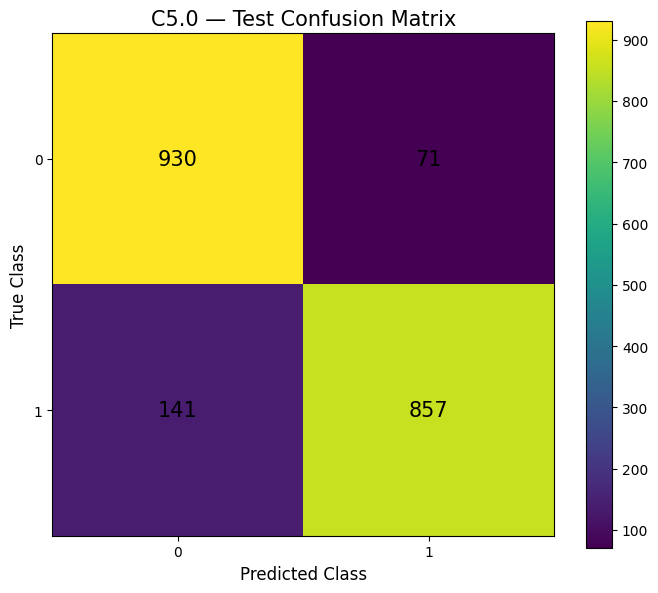

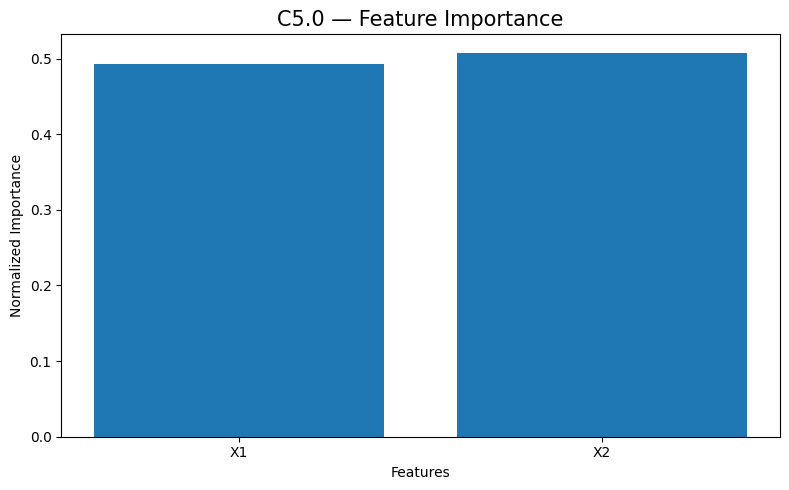

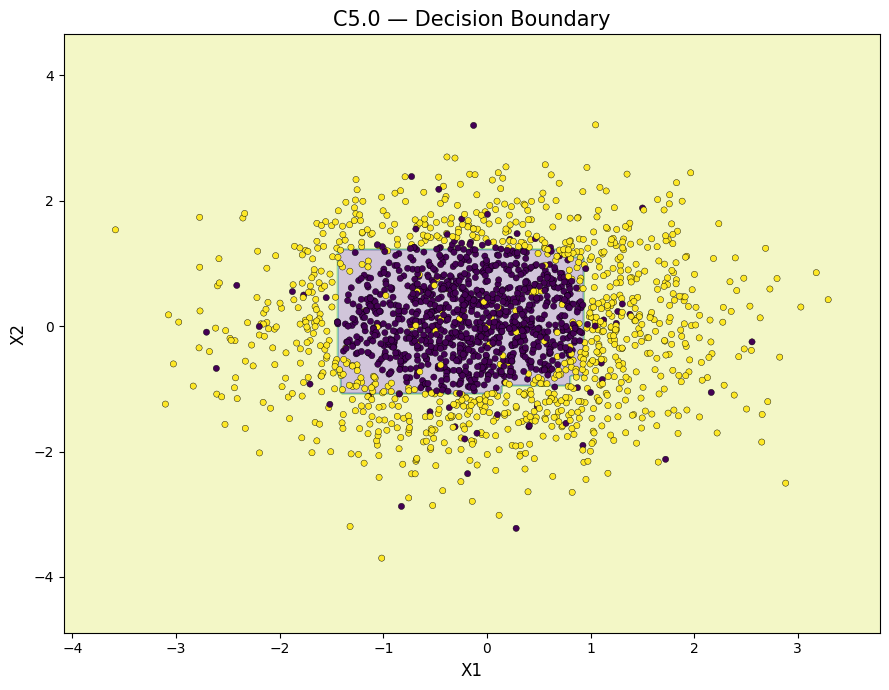

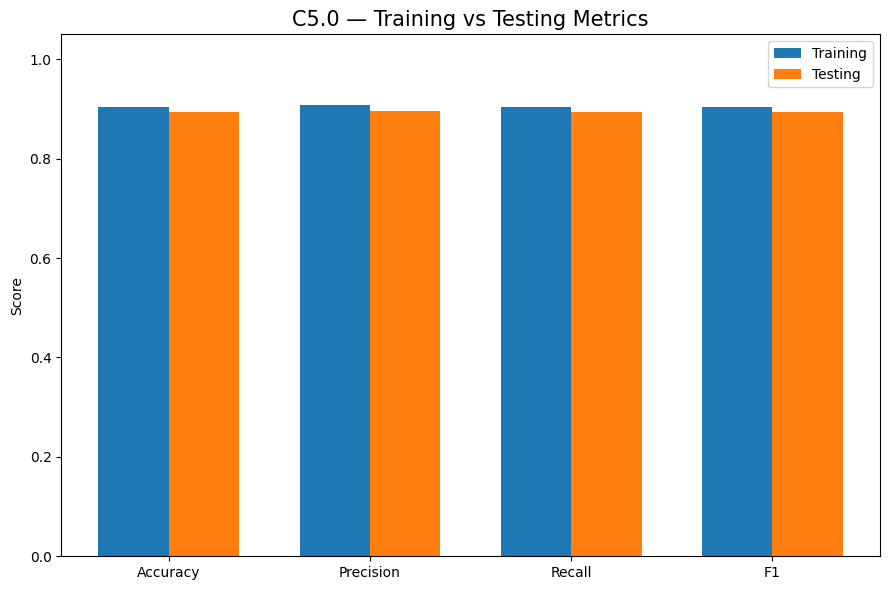

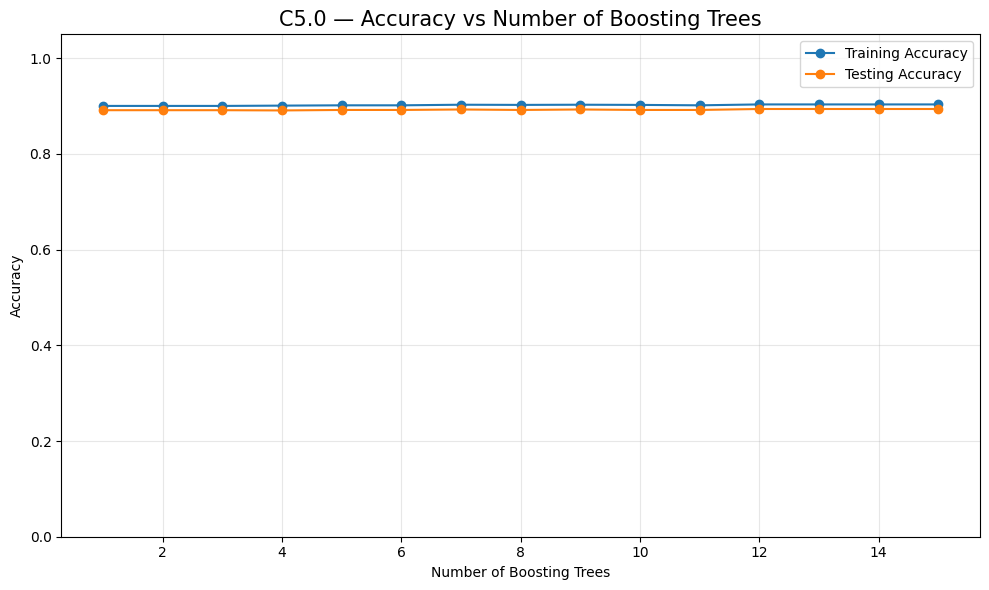

In [17]:
# ============================================================
# C5.0 DECISION TREE CLASSIFIER FROM SCRATCH
# ============================================================
#
# Libraries:
#   - NumPy
#   - Matplotlib
#
# NO sklearn is used.
#
# C5.0 CORE:
#   Entropy
#   Information Gain
#   Gain Ratio
#   Boosting
#   Weighted ensemble of trees
#
# Includes:
#   1. Entropy
#   2. Information Gain
#   3. Split Information
#   4. Gain Ratio
#   5. Numerical feature splitting
#   6. Binary threshold splitting
#   7. Recursive tree construction
#   8. Stopping criteria
#   9. Boosting
#  10. Weighted tree ensemble
#  11. Prediction
#  12. Accuracy
#  13. Precision
#  14. Recall
#  15. F1 Score
#  16. Confusion Matrix
#  17. Feature Importance
#  18. Decision Boundary
#  19. Training vs Testing metrics
#
# Dataset:
#   10,000 samples
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        feature_name=None,
        threshold=None,
        is_leaf=False,
        prediction=None,
        class_counts=None,
        depth=0
    ):

        self.feature_index = feature_index

        self.feature_name = feature_name

        self.threshold = threshold

        self.is_leaf = is_leaf

        self.prediction = prediction

        self.class_counts = class_counts

        self.depth = depth

        self.left = None

        self.right = None


# ============================================================
# 2. C5.0 SINGLE TREE
# ============================================================

class C50Tree:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_gain_ratio=1e-10
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.min_gain_ratio = (
            min_gain_ratio
        )

        self.root = None

        self.classes_ = None

        self.n_classes_ = None

        self.n_features_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # ENTROPY
    # ========================================================

    def _entropy(self, y, sample_weight):

        if len(y) == 0:

            return 0.0


        total_weight = np.sum(
            sample_weight
        )


        if total_weight <= 0:

            return 0.0


        entropy = 0.0


        for cls in self.classes_:

            class_weight = np.sum(
                sample_weight[
                    y == cls
                ]
            )


            if class_weight <= 0:

                continue


            probability = (
                class_weight
                /
                total_weight
            )


            entropy -= (
                probability
                *
                np.log2(probability)
            )


        return entropy


    # ========================================================
    # INFORMATION GAIN
    # ========================================================

    def _information_gain(
        self,
        y,
        sample_weight,
        left_mask,
        right_mask
    ):

        parent_entropy = (
            self._entropy(
                y,
                sample_weight
            )
        )


        total_weight = np.sum(
            sample_weight
        )


        left_weight = np.sum(
            sample_weight[
                left_mask
            ]
        )


        right_weight = np.sum(
            sample_weight[
                right_mask
            ]
        )


        if (
            left_weight <= 0
            or
            right_weight <= 0
        ):

            return 0.0


        left_entropy = (
            self._entropy(
                y[left_mask],
                sample_weight[left_mask]
            )
        )


        right_entropy = (
            self._entropy(
                y[right_mask],
                sample_weight[right_mask]
            )
        )


        weighted_entropy = (

            (
                left_weight
                /
                total_weight
            )
            *
            left_entropy

            +

            (
                right_weight
                /
                total_weight
            )
            *
            right_entropy
        )


        gain = (
            parent_entropy
            -
            weighted_entropy
        )


        return gain


    # ========================================================
    # SPLIT INFORMATION
    # ========================================================

    def _split_information(
        self,
        sample_weight,
        left_mask,
        right_mask
    ):

        total_weight = np.sum(
            sample_weight
        )


        left_weight = np.sum(
            sample_weight[
                left_mask
            ]
        )


        right_weight = np.sum(
            sample_weight[
                right_mask
            ]
        )


        if (
            left_weight <= 0
            or
            right_weight <= 0
        ):

            return 0.0


        p_left = (
            left_weight
            /
            total_weight
        )


        p_right = (
            right_weight
            /
            total_weight
        )


        split_info = 0.0


        if p_left > 0:

            split_info -= (
                p_left
                *
                np.log2(p_left)
            )


        if p_right > 0:

            split_info -= (
                p_right
                *
                np.log2(p_right)
            )


        return split_info


    # ========================================================
    # GAIN RATIO
    # ========================================================

    def _gain_ratio(
        self,
        y,
        sample_weight,
        left_mask,
        right_mask
    ):

        gain = (
            self._information_gain(
                y,
                sample_weight,
                left_mask,
                right_mask
            )
        )


        split_info = (
            self._split_information(
                sample_weight,
                left_mask,
                right_mask
            )
        )


        if split_info <= 1e-15:

            return 0.0


        return (
            gain
            /
            split_info
        )


    # ========================================================
    # BEST NUMERICAL SPLIT
    # ========================================================

    def _best_numeric_split(
        self,
        X_column,
        y,
        sample_weight
    ):

        unique_values = np.unique(
            X_column
        )


        if len(unique_values) <= 1:

            return (
                None,
                -np.inf,
                0.0
            )


        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0


        best_threshold = None

        best_gain_ratio = -np.inf

        best_gain = 0.0


        for threshold in thresholds:

            left_mask = (
                X_column
                <=
                threshold
            )


            right_mask = (
                X_column
                >
                threshold
            )


            left_count = np.sum(
                left_mask
            )


            right_count = np.sum(
                right_mask
            )


            if (
                left_count
                <
                self.min_samples_leaf
                or
                right_count
                <
                self.min_samples_leaf
            ):

                continue


            gain = (
                self._information_gain(
                    y,
                    sample_weight,
                    left_mask,
                    right_mask
                )
            )


            gain_ratio = (
                self._gain_ratio(
                    y,
                    sample_weight,
                    left_mask,
                    right_mask
                )
            )


            if (
                gain_ratio
                >
                best_gain_ratio
            ):

                best_gain_ratio = (
                    gain_ratio
                )

                best_threshold = (
                    threshold
                )

                best_gain = gain


        return (
            best_threshold,
            best_gain_ratio,
            best_gain
        )


    # ========================================================
    # FIND BEST SPLIT
    # ========================================================

    def _best_split(
        self,
        X,
        y,
        sample_weight
    ):

        best_feature = None

        best_threshold = None

        best_gain_ratio = -np.inf

        best_gain = 0.0


        for feature_index in range(
            self.n_features_
        ):

            column = X[
                :,
                feature_index
            ]


            (
                threshold,
                gain_ratio,
                gain
            ) = self._best_numeric_split(
                column,
                y,
                sample_weight
            )


            if (
                gain_ratio
                >
                best_gain_ratio
            ):

                best_gain_ratio = (
                    gain_ratio
                )

                best_feature = (
                    feature_index
                )

                best_threshold = (
                    threshold
                )

                best_gain = gain


        return (
            best_feature,
            best_threshold,
            best_gain_ratio,
            best_gain
        )


    # ========================================================
    # WEIGHTED MAJORITY CLASS
    # ========================================================

    def _majority_class(
        self,
        y,
        sample_weight
    ):

        weighted_counts = []


        for cls in self.classes_:

            weight = np.sum(
                sample_weight[
                    y == cls
                ]
            )

            weighted_counts.append(
                weight
            )


        return self.classes_[
            np.argmax(
                weighted_counts
            )
        ]


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        sample_weight,
        depth=0
    ):

        majority_class = (
            self._majority_class(
                y,
                sample_weight
            )
        )


        class_counts = {}


        for cls in self.classes_:

            class_counts[cls] = np.sum(
                sample_weight[
                    y == cls
                ]
            )


        node = TreeNode(
            is_leaf=False,
            prediction=majority_class,
            class_counts=class_counts,
            depth=depth
        )


        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ====================================================
        # STOPPING CONDITION 1
        # Pure node
        # ====================================================

        if len(np.unique(y)) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 2
        # Maximum depth
        # ====================================================

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 3
        # Minimum samples
        # ====================================================

        if (
            len(y)
            <
            self.min_samples_split
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FIND BEST SPLIT
        # ====================================================

        (
            feature_index,
            threshold,
            gain_ratio,
            gain
        ) = self._best_split(
            X,
            y,
            sample_weight
        )


        # ====================================================
        # STOPPING CONDITION 4
        # ====================================================

        if (
            feature_index is None
            or
            threshold is None
            or
            gain_ratio
            <=
            self.min_gain_ratio
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE SPLIT
        # ====================================================

        node.feature_index = (
            feature_index
        )

        node.feature_name = (
            self.feature_names_[
                feature_index
            ]
        )

        node.threshold = threshold


        # ====================================================
        # FEATURE IMPORTANCE
        # ====================================================

        node_weight = np.sum(
            sample_weight
        )


        self.feature_importances_[
            feature_index
        ] += (
            gain
            *
            node_weight
        )


        # ====================================================
        # BINARY SPLIT
        # ====================================================

        left_mask = (
            X[:, feature_index]
            <=
            threshold
        )


        right_mask = (
            X[:, feature_index]
            >
            threshold
        )


        X_left = X[
            left_mask
        ]


        y_left = y[
            left_mask
        ]


        weight_left = sample_weight[
            left_mask
        ]


        X_right = X[
            right_mask
        ]


        y_right = y[
            right_mask
        ]


        weight_right = sample_weight[
            right_mask
        ]


        # ====================================================
        # MINIMUM LEAF CHECK
        # ====================================================

        if (
            len(y_left)
            <
            self.min_samples_leaf
            or
            len(y_right)
            <
            self.min_samples_leaf
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # RECURSIVE BUILDING
        # ====================================================

        node.left = self._build_tree(
            X_left,
            y_left,
            weight_left,
            depth + 1
        )


        node.right = self._build_tree(
            X_right,
            y_right,
            weight_right,
            depth + 1
        )


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        sample_weight,
        classes,
        feature_names
    ):

        self.classes_ = classes

        self.n_classes_ = len(
            classes
        )

        self.n_features_ = (
            X.shape[1]
        )

        self.feature_names_ = (
            list(feature_names)
        )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        self.root = self._build_tree(
            X,
            y,
            sample_weight
        )


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        if (
            x[node.feature_index]
            <=
            node.threshold
        ):

            return self._predict_sample(
                x,
                node.left
            )

        else:

            return self._predict_sample(
                x,
                node.right
            )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        predictions = []


        for x in X:

            predictions.append(
                self._predict_sample(
                    x,
                    self.root
                )
            )


        return np.asarray(
            predictions
        )


# ============================================================
# 3. C5.0 BOOSTED CLASSIFIER
# ============================================================

class C50Classifier:

    def __init__(
        self,
        n_estimators=10,
        learning_rate=0.5,
        max_depth=6,
        min_samples_split=10,
        min_samples_leaf=5,
        min_gain_ratio=1e-6
    ):

        self.n_estimators = (
            n_estimators
        )

        self.learning_rate = (
            learning_rate
        )

        self.max_depth = (
            max_depth
        )

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.min_gain_ratio = (
            min_gain_ratio
        )


        self.classes_ = None

        self.n_classes_ = None

        self.n_features_ = None

        self.feature_names_ = None


        self.trees_ = []

        self.tree_weights_ = []

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(X)

        y = np.asarray(y)


        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )


        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )


        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )


        self.classes_ = np.unique(
            y
        )


        self.n_classes_ = len(
            self.classes_
        )


        self.n_features_ = (
            X.shape[1]
        )


        if feature_names is None:

            self.feature_names_ = [
                f"Feature_{i}"
                for i in range(
                    self.n_features_
                )
            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )


        self.trees_ = []

        self.tree_weights_ = []

        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ====================================================
        # INITIAL SAMPLE WEIGHTS
        # ====================================================

        sample_weight = (
            np.ones(
                len(y)
            )
            /
            len(y)
        )


        # ====================================================
        # BOOSTING
        # ====================================================

        for iteration in range(
            self.n_estimators
        ):


            # ------------------------------------------------
            # Build C5.0 tree
            # ------------------------------------------------

            tree = C50Tree(

                max_depth=self.max_depth,

                min_samples_split=(
                    self.min_samples_split
                ),

                min_samples_leaf=(
                    self.min_samples_leaf
                ),

                min_gain_ratio=(
                    self.min_gain_ratio
                )
            )


            tree.fit(
                X,
                y,
                sample_weight,
                self.classes_,
                self.feature_names_
            )


            # ------------------------------------------------
            # Tree predictions
            # ------------------------------------------------

            predictions = tree.predict(
                X
            )


            # ------------------------------------------------
            # Weighted classification error
            # ------------------------------------------------

            incorrect = (
                predictions
                !=
                y
            )


            error = np.sum(
                sample_weight[
                    incorrect
                ]
            )


            # ------------------------------------------------
            # Prevent numerical problems
            # ------------------------------------------------

            error = np.clip(
                error,
                1e-10,
                1.0 - 1e-10
            )


            # ------------------------------------------------
            # Binary AdaBoost-style tree weight
            # ------------------------------------------------

            alpha = (
                self.learning_rate
                *
                0.5
                *
                np.log(
                    (
                        1.0 - error
                    )
                    /
                    error
                )
            )


            # ------------------------------------------------
            # If tree is worse than random,
            # stop adding weak learners.
            # ------------------------------------------------

            if alpha <= 0:

                break


            # ------------------------------------------------
            # Update sample weights
            # ------------------------------------------------

            sample_weight *= np.exp(
                np.where(
                    incorrect,
                    alpha,
                    -alpha
                )
            )


            # ------------------------------------------------
            # Normalize weights
            # ------------------------------------------------

            weight_sum = np.sum(
                sample_weight
            )


            if weight_sum <= 0:

                break


            sample_weight /= (
                weight_sum
            )


            # ------------------------------------------------
            # Store tree
            # ------------------------------------------------

            self.trees_.append(
                tree
            )


            self.tree_weights_.append(
                alpha
            )


            # ------------------------------------------------
            # Feature importance
            # ------------------------------------------------

            self.feature_importances_ += (
                alpha
                *
                tree.feature_importances_
            )


            self.tree_depth_ = max(
                self.tree_depth_,
                tree.tree_depth_
            )


            self.n_leaves_ += (
                tree.n_leaves_
            )


        # ====================================================
        # NORMALIZE FEATURE IMPORTANCE
        # ====================================================

        total_importance = np.sum(
            self.feature_importances_
        )


        if total_importance > 0:

            self.feature_importances_ /= (
                total_importance
            )


        return self


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)


        if len(self.trees_) == 0:

            raise RuntimeError(
                "The model has no trained trees."
            )


        # ----------------------------------------------------
        # Weighted voting
        # ----------------------------------------------------

        vote_scores = np.zeros(
            (
                len(X),
                self.n_classes_
            )
        )


        for tree, alpha in zip(
            self.trees_,
            self.tree_weights_
        ):

            predictions = (
                tree.predict(X)
            )


            for class_index, cls in enumerate(
                self.classes_
            ):

                vote_scores[
                    :,
                    class_index
                ] += (
                    alpha
                    *
                    (
                        predictions
                        ==
                        cls
                    )
                )


        winning_indices = np.argmax(
            vote_scores,
            axis=1
        )


        return self.classes_[
            winning_indices
        ]


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )


        return np.mean(
            predictions == y
        )


# ============================================================
# 4. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    train_indices = []

    test_indices = []


    # --------------------------------------------------------
    # Stratified split
    # --------------------------------------------------------

    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(
            len(indices)
            *
            test_size
        )


        test_indices.extend(
            indices[:n_test]
        )


        train_indices.extend(
            indices[n_test:]
        )


    train_indices = np.asarray(
        train_indices
    )


    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )


    rng.shuffle(
        test_indices
    )


    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# 5. CONFUSION MATRIX FROM SCRATCH
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )


    matrix = np.zeros(
        (
            len(labels),
            len(labels)
        ),
        dtype=int
    )


    label_to_index = {
        label: i
        for i, label in enumerate(
            labels
        )
    }


    for true, pred in zip(
        y_true,
        y_pred
    ):

        matrix[
            label_to_index[true],
            label_to_index[pred]
        ] += 1


    return matrix, labels


# ============================================================
# 6. CLASSIFICATION METRICS FROM SCRATCH
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (
        confusion_matrix_manual(
            y_true,
            y_pred
        )
    )


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = (
        np.trace(cm)
        /
        np.sum(cm)
    )


    precisions = []

    recalls = []

    f1_scores = []


    # --------------------------------------------------------
    # Per-class metrics
    # --------------------------------------------------------

    for i in range(
        len(labels)
    ):

        TP = cm[i, i]


        FP = (
            np.sum(cm[:, i])
            -
            TP
        )


        FN = (
            np.sum(cm[i, :])
            -
            TP
        )


        precision = (
            TP
            /
            (TP + FP)
            if
            (TP + FP) > 0
            else
            0.0
        )


        recall = (
            TP
            /
            (TP + FN)
            if
            (TP + FN) > 0
            else
            0.0
        )


        if (
            precision + recall
            >
            0
        ):

            f1 = (
                2
                *
                precision
                *
                recall
                /
                (
                    precision
                    +
                    recall
                )
            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )


        recalls.append(
            recall
        )


        f1_scores.append(
            f1
        )


    # --------------------------------------------------------
    # Macro averages
    # --------------------------------------------------------

    macro_precision = np.mean(
        precisions
    )


    macro_recall = np.mean(
        recalls
    )


    macro_f1 = np.mean(
        f1_scores
    )


    return {

        "accuracy": accuracy,

        "precision": macro_precision,

        "recall": macro_recall,

        "f1": macro_f1,

        "labels": labels,

        "confusion_matrix": cm,

        "per_class_precision":
            precisions,

        "per_class_recall":
            recalls,

        "per_class_f1":
            f1_scores
    }


# ============================================================
# 7. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Generate numerical features
# ------------------------------------------------------------

X = rng.normal(
    0,
    1,
    size=(
        n_samples,
        2
    )
)


x1 = X[:, 0]

x2 = X[:, 1]


# ------------------------------------------------------------
# Nonlinear decision function
# ------------------------------------------------------------

decision_function = (
    x1**2
    +
    x2**2
    +
    0.5 * x1
    -
    0.3 * x2
)


y = (
    decision_function
    >
    1.4
).astype(int)


# ------------------------------------------------------------
# Add 5% label noise
# ------------------------------------------------------------

noise = (
    rng.random(
        n_samples
    )
    <
    0.05
)


y[noise] = (
    1 - y[noise]
)


feature_names = [
    "X1",
    "X2"
]


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 9. CREATE C5.0 MODEL
# ============================================================

model = C50Classifier(

    n_estimators=15,

    learning_rate=0.5,

    max_depth=6,

    min_samples_split=10,

    min_samples_leaf=5,

    min_gain_ratio=1e-6
)


# ============================================================
# 10. TRAIN C5.0
# ============================================================

model.fit(
    X_train,
    y_train,
    feature_names=feature_names
)


# ============================================================
# 11. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 12. EVALUATION
# ============================================================

train_metrics = (
    classification_metrics(
        y_train,
        y_train_pred
    )
)


test_metrics = (
    classification_metrics(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 13. PRINT RESULTS
# ============================================================

print("=" * 70)

print(
    "C5.0 DECISION TREE — FROM SCRATCH"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Number classes   : {model.n_classes_}"
)


print(
    f"Number of trees  : {len(model.trees_)}"
)


print(
    f"Maximum depth    : {model.tree_depth_}"
)


print(
    f"Total leaves     : {model.n_leaves_}"
)


# ============================================================
# 14. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# 15. TESTING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 16. PER-CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(
    test_metrics["labels"]
):

    print(
        f"Class {label}: "
        f"Precision = "
        f"{test_metrics['per_class_precision'][i]:.4f}, "
        f"Recall = "
        f"{test_metrics['per_class_recall'][i]:.4f}, "
        f"F1 = "
        f"{test_metrics['per_class_f1'][i]:.4f}"
    )


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]


labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 18. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(
    "C5.0 — Test Confusion Matrix",
    fontsize=15
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "True Class",
    fontsize=12
)


plt.xticks(
    range(len(labels)),
    labels
)


plt.yticks(
    range(len(labels)),
    labels
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=15
        )


plt.colorbar()


plt.tight_layout()

plt.show()


# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model.feature_names_,
    model.feature_importances_
)


plt.title(
    "C5.0 — Feature Importance",
    fontsize=15
)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Normalized Importance"
)


plt.tight_layout()

plt.show()


# ============================================================
# 20. DECISION BOUNDARY
# ============================================================

x_min = (
    X[:, 0].min()
    -
    0.5
)


x_max = (
    X[:, 0].max()
    +
    0.5
)


y_min = (
    X[:, 1].min()
    -
    0.5
)


y_max = (
    X[:, 1].max()
    +
    0.5
)


resolution = 300


xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        resolution
    ),
    np.linspace(
        y_min,
        y_max,
        resolution
    )
)


grid = np.column_stack(
    [
        xx.ravel(),
        yy.ravel()
    ]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(9, 7)
)


plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25
)


plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    s=20,
    edgecolors="black",
    linewidths=0.3
)


plt.title(
    "C5.0 — Decision Boundary",
    fontsize=15
)


plt.xlabel(
    "X1",
    fontsize=12
)


plt.ylabel(
    "X2",
    fontsize=12
)


plt.tight_layout()

plt.show()


# ============================================================
# 21. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]


train_values = [
    train_metrics["accuracy"],
    train_metrics["precision"],
    train_metrics["recall"],
    train_metrics["f1"]
]


test_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"]
]


x = np.arange(
    len(metric_names)
)


width = 0.35


plt.figure(
    figsize=(9, 6)
)


plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing"
)


plt.xticks(
    x,
    metric_names
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)


plt.title(
    "C5.0 — Training vs Testing Metrics",
    fontsize=15
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 22. BOOSTING PERFORMANCE
# ============================================================

tree_numbers = np.arange(
    1,
    len(model.trees_) + 1
)


training_scores = []

testing_scores = []


# ------------------------------------------------------------
# Evaluate progressively larger ensembles
# ------------------------------------------------------------

for number_of_trees in tree_numbers:

    vote_train = np.zeros(
        (
            len(X_train),
            model.n_classes_
        )
    )


    vote_test = np.zeros(
        (
            len(X_test),
            model.n_classes_
        )
    )


    for tree, alpha in zip(
        model.trees_[
            :number_of_trees
        ],
        model.tree_weights_[
            :number_of_trees
        ]
    ):

        train_prediction = (
            tree.predict(
                X_train
            )
        )


        test_prediction = (
            tree.predict(
                X_test
            )
        )


        for class_index, cls in enumerate(
            model.classes_
        ):

            vote_train[
                :,
                class_index
            ] += (
                alpha
                *
                (
                    train_prediction
                    ==
                    cls
                )
            )


            vote_test[
                :,
                class_index
            ] += (
                alpha
                *
                (
                    test_prediction
                    ==
                    cls
                )
            )


    train_ensemble_prediction = (
        model.classes_[
            np.argmax(
                vote_train,
                axis=1
            )
        ]
    )


    test_ensemble_prediction = (
        model.classes_[
            np.argmax(
                vote_test,
                axis=1
            )
        ]
    )


    train_accuracy = np.mean(
        train_ensemble_prediction
        ==
        y_train
    )


    test_accuracy = np.mean(
        test_ensemble_prediction
        ==
        y_test
    )


    training_scores.append(
        train_accuracy
    )


    testing_scores.append(
        test_accuracy
    )


# ============================================================
# 23. BOOSTING PERFORMANCE PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    tree_numbers,
    training_scores,
    marker="o",
    label="Training Accuracy"
)


plt.plot(
    tree_numbers,
    testing_scores,
    marker="o",
    label="Testing Accuracy"
)


plt.xlabel(
    "Number of Boosting Trees"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "C5.0 — Accuracy vs Number of Boosting Trees",
    fontsize=15
)


plt.ylim(
    0,
    1.05
)


plt.grid(
    alpha=0.3
)


plt.legend()


plt.tight_layout()

plt.show()

CHAID CLASSIFIER — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 2
Number classes   : 2
Tree depth       : 2
Number of leaves : 21

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.8943
Precision : 0.8980
Recall    : 0.8883
F1 Score  : 0.8917

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.8929
Precision : 0.8972
Recall    : 0.8866
F1 Score  : 0.8903

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.8756, Recall = 0.9417, F1 = 0.9074
Class 1: Precision = 0.9189, Recall = 0.8316, F1 = 0.8731

------------------------------------------------

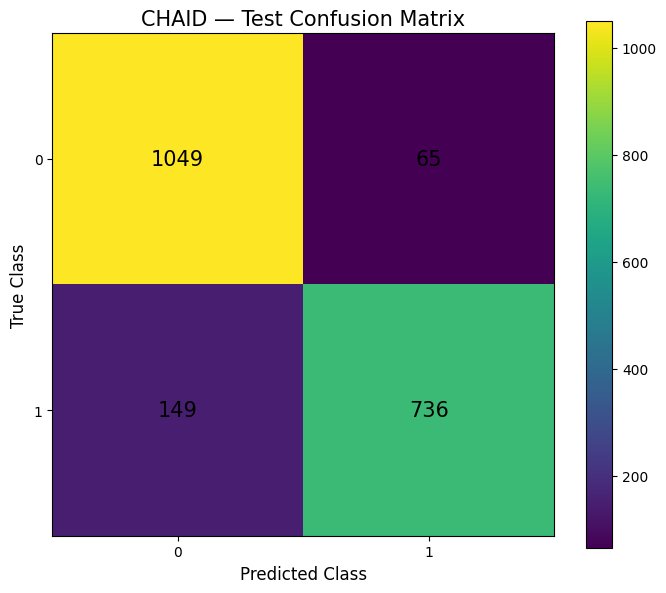

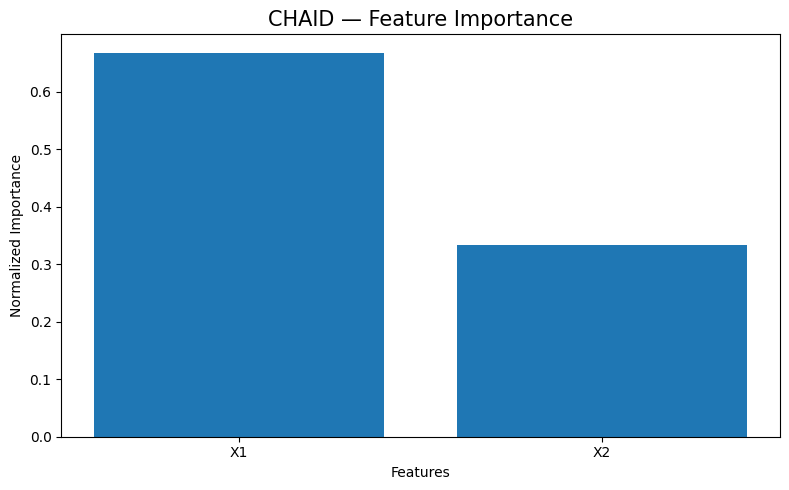

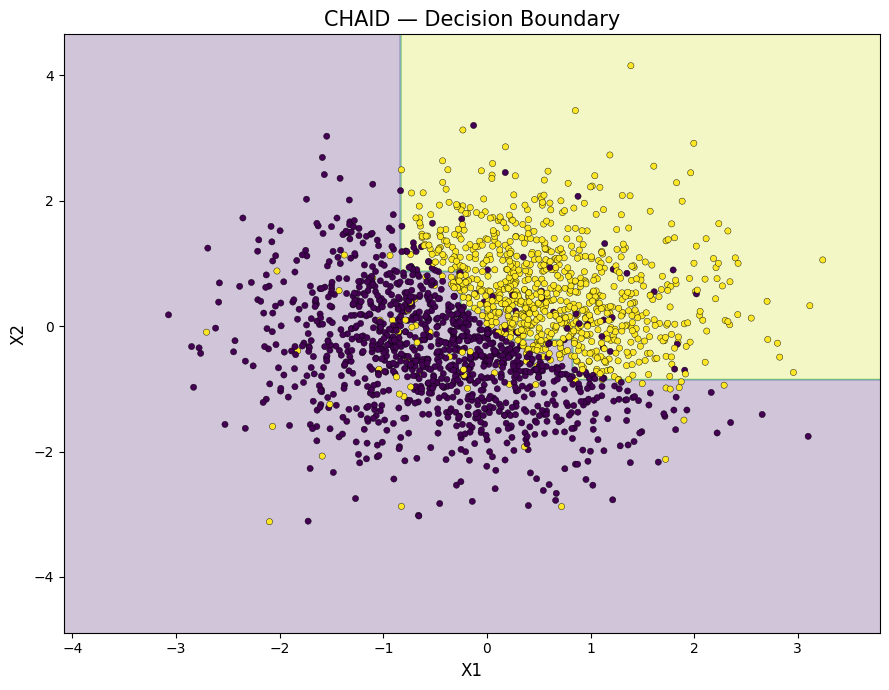

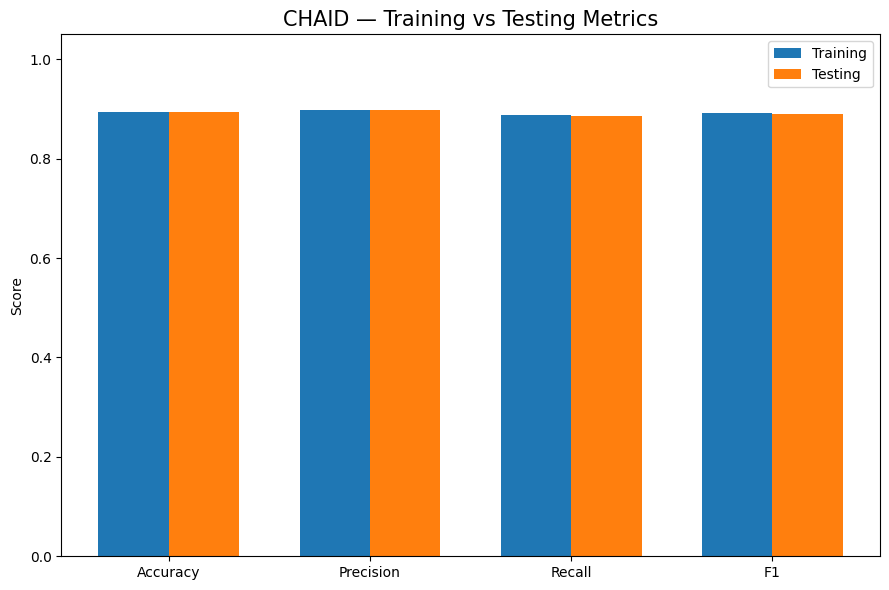

In [8]:
# ============================================================
# CHAID CLASSIFIER FROM SCRATCH
# ============================================================
#
# CHAID
# = Chi-squared Automatic Interaction Detection
#
# CORE IDEA:
#
#   Feature
#      ↓
#   Convert numerical values into categories
#      ↓
#   Build contingency table
#      ↓
#   Chi-square test
#      ↓
#   Bonferroni correction
#      ↓
#   Select statistically significant feature
#      ↓
#   Multiway split
#
# Libraries:
#   - NumPy
#   - Matplotlib
#
# NO sklearn is used.
#
# Includes:
#   1. Chi-square statistic
#   2. Chi-square p-value
#   3. Chi-square critical value
#   4. Bonferroni correction
#   5. Numerical feature discretization
#   6. Multiway splitting
#   7. Recursive tree construction
#   8. Stopping criteria
#   9. Prediction
#  10. Accuracy
#  11. Precision
#  12. Recall
#  13. F1 Score
#  14. Confusion Matrix
#  15. Feature Importance
#  16. Decision Boundary
#  17. Training vs Testing metrics
#
# Dataset:
#   10,000 samples
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CHI-SQUARE DISTRIBUTION APPROXIMATION
# ============================================================
#
# We implement the chi-square survival probability without
# scipy.
#
# For df = 1, 2, 3, ...
# the calculation is performed using numerical integration.
#
# This keeps the implementation independent of sklearn/scipy.
#
# ============================================================


def _gamma_function(z):

    # --------------------------------------------------------
    # Lanczos approximation of Gamma(z)
    # --------------------------------------------------------

    coefficients = [
        676.5203681218851,
        -1259.1392167224028,
        771.32342877765313,
        -176.61502916214059,
        12.507343278686905,
        -0.13857109526572012,
        9.9843695780195716e-6,
        1.5056327351493116e-7
    ]


    if z < 0.5:

        return (
            np.pi
            /
            (
                np.sin(np.pi * z)
                *
                _gamma_function(1 - z)
            )
        )


    z -= 1


    x = 0.99999999999980993


    for i, coefficient in enumerate(
        coefficients
    ):

        x += (
            coefficient
            /
            (z + i + 1)
        )


    t = (
        z
        +
        len(coefficients)
        -
        0.5
    )


    return (
        np.sqrt(2 * np.pi)
        *
        t ** (z + 0.5)
        *
        np.exp(-t)
        *
        x
    )


# ============================================================
# 2. REGULARIZED UPPER GAMMA
# ============================================================

def _regularized_gamma_q(
    a,
    x
):

    if x < 0 or a <= 0:

        return np.nan


    if x == 0:

        return 1.0


    # --------------------------------------------------------
    # Continued fraction approximation
    # --------------------------------------------------------

    if x >= a + 1:

        max_iterations = 200

        epsilon = 1e-12

        tiny = 1e-300


        b = (
            x
            +
            1
            -
            a
        )


        c = 1 / tiny

        d = 1 / b

        h = d


        for i in range(
            1,
            max_iterations + 1
        ):

            an = (
                -i
                *
                (i - a)
            )


            b += 2


            d = (
                an * d
                +
                b
            )


            if abs(d) < tiny:

                d = tiny


            c = (
                b
                +
                an / c
            )


            if abs(c) < tiny:

                c = tiny


            d = 1 / d


            delta = (
                d * c
            )


            h *= delta


            if abs(
                delta - 1
            ) < epsilon:

                break


        result = (
            np.exp(
                -x
                +
                a * np.log(x)
                -
                np.log(
                    _gamma_function(a)
                )
            )
            *
            h
        )


        return np.clip(
            result,
            0.0,
            1.0
        )


    # --------------------------------------------------------
    # Series expansion
    # --------------------------------------------------------

    summation = 1.0 / a

    term = summation

    n = 1


    while n < 200:

        term *= (
            x
            /
            (a + n)
        )


        summation += term


        if abs(term) < (
            abs(summation)
            *
            1e-12
        ):

            break


        n += 1


    lower_gamma_ratio = (
        np.exp(
            -x
            +
            a * np.log(x)
            -
            np.log(
                _gamma_function(a)
            )
        )
        *
        summation
    )


    result = (
        1.0
        -
        lower_gamma_ratio
    )


    return np.clip(
        result,
        0.0,
        1.0
    )


# ============================================================
# 3. CHI-SQUARE P-VALUE
# ============================================================

def chi_square_p_value(
    chi_square,
    degrees_of_freedom
):

    if degrees_of_freedom <= 0:

        return 1.0


    if chi_square <= 0:

        return 1.0


    return _regularized_gamma_q(
        degrees_of_freedom / 2.0,
        chi_square / 2.0
    )


# ============================================================
# 4. TREE NODE
# ============================================================

class CHAIDNode:

    def __init__(
        self,
        feature_index=None,
        feature_name=None,
        is_leaf=False,
        prediction=None,
        class_counts=None,
        depth=0
    ):

        self.feature_index = (
            feature_index
        )

        self.feature_name = (
            feature_name
        )

        self.is_leaf = is_leaf

        self.prediction = (
            prediction
        )

        self.class_counts = (
            class_counts
        )

        self.depth = depth

        # ----------------------------------------------------
        # CHAID allows MULTIWAY splits
        # ----------------------------------------------------

        self.children = {}

        self.categories = []

        self.p_value = None

        self.chi_square = None


# ============================================================
# 5. CHAID CLASSIFIER
# ============================================================

class CHAIDClassifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=10,
        alpha=0.05,
        n_bins=5,
        min_category_size=10
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.alpha = alpha

        self.n_bins = n_bins

        self.min_category_size = (
            min_category_size
        )

        self.root = None

        self.classes_ = None

        self.n_classes_ = None

        self.n_features_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ----------------------------------------------------
        # Bin edges are learned during fit
        # ----------------------------------------------------

        self.bin_edges_ = []


    # ========================================================
    # DISCRETIZE NUMERICAL FEATURE
    # ========================================================

    def _fit_bins(
        self,
        X
    ):

        self.bin_edges_ = []


        for feature_index in range(
            self.n_features_
        ):

            column = X[
                :,
                feature_index
            ]


            # ------------------------------------------------
            # Quantile based bins
            # ------------------------------------------------

            quantiles = np.linspace(
                0,
                1,
                self.n_bins + 1
            )


            edges = np.quantile(
                column,
                quantiles
            )


            edges = np.unique(
                edges
            )


            self.bin_edges_.append(
                edges
            )


    # ========================================================
    # TRANSFORM NUMERICAL FEATURES
    # ========================================================

    def _transform_bins(
        self,
        X
    ):

        X_binned = np.zeros(
            X.shape,
            dtype=int
        )


        for feature_index in range(
            self.n_features_
        ):

            edges = self.bin_edges_[
                feature_index
            ]


            if len(edges) <= 2:

                X_binned[
                    :,
                    feature_index
                ] = 0

                continue


            # ------------------------------------------------
            # np.digitize creates categories
            # ------------------------------------------------

            X_binned[
                :,
                feature_index
            ] = np.digitize(
                X[
                    :,
                    feature_index
                ],
                edges[1:-1],
                right=False
            )


        return X_binned


    # ========================================================
    # CONTINGENCY TABLE
    # ========================================================

    def _contingency_table(
        self,
        feature,
        y
    ):

        categories = np.unique(
            feature
        )


        table = np.zeros(
            (
                len(categories),
                self.n_classes_
            ),
            dtype=float
        )


        for i, category in enumerate(
            categories
        ):

            for j, cls in enumerate(
                self.classes_
            ):

                table[
                    i,
                    j
                ] = np.sum(
                    (
                        feature
                        ==
                        category
                    )
                    &
                    (
                        y
                        ==
                        cls
                    )
                )


        return (
            table,
            categories
        )


    # ========================================================
    # CHI-SQUARE STATISTIC
    # ========================================================

    def _chi_square_test(
        self,
        feature,
        y
    ):

        (
            observed,
            categories
        ) = self._contingency_table(
            feature,
            y
        )


        # ----------------------------------------------------
        # Remove empty categories
        # ----------------------------------------------------

        valid_rows = (
            np.sum(
                observed,
                axis=1
            )
            >
            0
        )


        observed = observed[
            valid_rows
        ]


        categories = categories[
            valid_rows
        ]


        if (
            observed.shape[0] <= 1
            or
            observed.shape[1] <= 1
        ):

            return (
                0.0,
                1.0,
                categories
            )


        # ----------------------------------------------------
        # Expected frequencies
        # ----------------------------------------------------

        row_totals = np.sum(
            observed,
            axis=1,
            keepdims=True
        )


        column_totals = np.sum(
            observed,
            axis=0,
            keepdims=True
        )


        total = np.sum(
            observed
        )


        expected = (
            row_totals
            *
            column_totals
            /
            total
        )


        # ----------------------------------------------------
        # Avoid division by zero
        # ----------------------------------------------------

        valid = (
            expected
            >
            0
        )


        chi_square = np.sum(
            np.where(
                valid,
                (
                    (
                        observed
                        -
                        expected
                    )
                    ** 2
                    /
                    expected
                ),
                0.0
            )
        )


        degrees_of_freedom = (
            (
                observed.shape[0]
                -
                1
            )
            *
            (
                observed.shape[1]
                -
                1
            )
        )


        p_value = (
            chi_square_p_value(
                chi_square,
                degrees_of_freedom
            )
        )


        return (
            chi_square,
            p_value,
            categories
        )


    # ========================================================
    # BONFERRONI CORRECTION
    # ========================================================

    def _bonferroni_adjust(
        self,
        p_value,
        number_of_tests
    ):

        adjusted = (
            p_value
            *
            max(
                1,
                number_of_tests
            )
        )


        return min(
            adjusted,
            1.0
        )


    # ========================================================
    # FIND BEST FEATURE
    # ========================================================

    def _best_feature(
        self,
        X_binned,
        y
    ):

        best_feature = None

        best_p_value = 1.0

        best_chi_square = 0.0

        best_categories = None


        candidate_results = []


        # ----------------------------------------------------
        # Test every feature
        # ----------------------------------------------------

        for feature_index in range(
            self.n_features_
        ):

            feature = X_binned[
                :,
                feature_index
            ]


            (
                chi_square,
                p_value,
                categories
            ) = self._chi_square_test(
                feature,
                y
            )


            # ------------------------------------------------
            # Ignore features with tiny categories
            # ------------------------------------------------

            valid = True


            for category in categories:

                count = np.sum(
                    feature
                    ==
                    category
                )


                if (
                    count
                    <
                    self.min_category_size
                ):

                    valid = False

                    break


            if not valid:

                continue


            candidate_results.append(
                (
                    feature_index,
                    chi_square,
                    p_value,
                    categories
                )
            )


        if len(candidate_results) == 0:

            return (
                None,
                0.0,
                1.0,
                None
            )


        # ----------------------------------------------------
        # Bonferroni adjustment
        # ----------------------------------------------------

        number_of_tests = len(
            candidate_results
        )


        for (
            feature_index,
            chi_square,
            p_value,
            categories
        ) in candidate_results:


            adjusted_p = (
                self._bonferroni_adjust(
                    p_value,
                    number_of_tests
                )
            )


            if (
                adjusted_p
                <
                best_p_value
            ):

                best_p_value = (
                    adjusted_p
                )

                best_feature = (
                    feature_index
                )

                best_chi_square = (
                    chi_square
                )

                best_categories = (
                    categories
                )


        return (
            best_feature,
            best_chi_square,
            best_p_value,
            best_categories
        )


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(
        self,
        y
    ):

        values, counts = np.unique(
            y,
            return_counts=True
        )


        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X_binned,
        y,
        depth=0
    ):

        majority_class = (
            self._majority_class(y)
        )


        class_counts = {}


        for cls in self.classes_:

            class_counts[cls] = np.sum(
                y == cls
            )


        node = CHAIDNode(

            is_leaf=False,

            prediction=majority_class,

            class_counts=class_counts,

            depth=depth
        )


        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ====================================================
        # STOP 1: PURE NODE
        # ====================================================

        if len(np.unique(y)) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP 2: MAX DEPTH
        # ====================================================

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP 3: MINIMUM SAMPLES
        # ====================================================

        if (
            len(y)
            <
            self.min_samples_split
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FIND BEST STATISTICALLY SIGNIFICANT FEATURE
        # ====================================================

        (
            feature_index,
            chi_square,
            p_value,
            categories
        ) = self._best_feature(
            X_binned,
            y
        )


        # ====================================================
        # STOP 4: NO SIGNIFICANT FEATURE
        # ====================================================

        if (
            feature_index is None
            or
            p_value
            >
            self.alpha
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE SPLIT
        # ====================================================

        node.feature_index = (
            feature_index
        )


        node.feature_name = (
            self.feature_names_[
                feature_index
            ]
        )


        node.categories = (
            categories.tolist()
        )


        node.chi_square = (
            chi_square
        )


        node.p_value = (
            p_value
        )


        # ====================================================
        # FEATURE IMPORTANCE
        #
        # Smaller p-value means stronger statistical evidence.
        # We use -log10(p) weighted by node size.
        # ====================================================

        importance = (
            -np.log10(
                max(
                    p_value,
                    1e-300
                )
            )
        )


        self.feature_importances_[
            feature_index
        ] += (
            importance
            *
            len(y)
        )


        # ====================================================
        # MULTIWAY SPLIT
        # ====================================================

        for category in categories:

            mask = (
                X_binned[
                    :,
                    feature_index
                ]
                ==
                category
            )


            X_child = (
                X_binned[
                    mask
                ]
            )


            y_child = (
                y[
                    mask
                ]
            )


            # ------------------------------------------------
            # Minimum leaf size
            # ------------------------------------------------

            if (
                len(y_child)
                <
                self.min_samples_leaf
            ):

                continue


            node.children[
                int(category)
            ] = self._build_tree(

                X_child,

                y_child,

                depth + 1
            )


        # ====================================================
        # If no valid children were created
        # ====================================================

        if len(node.children) == 0:

            node.is_leaf = True

            self.n_leaves_ += 1


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(X)

        y = np.asarray(y)


        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )


        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )


        if len(X) != len(y):

            raise ValueError(
                "X and y must contain "
                "the same number of samples."
            )


        self.n_features_ = (
            X.shape[1]
        )


        self.classes_ = np.unique(
            y
        )


        self.n_classes_ = len(
            self.classes_
        )


        if feature_names is None:

            self.feature_names_ = [
                f"Feature_{i}"
                for i in range(
                    self.n_features_
                )
            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ====================================================
        # LEARN DISCRETIZATION
        # ====================================================

        self._fit_bins(X)


        # ====================================================
        # TRANSFORM DATA
        # ====================================================

        X_binned = (
            self._transform_bins(X)
        )


        # ====================================================
        # BUILD TREE
        # ====================================================

        self.root = self._build_tree(
            X_binned,
            y
        )


        # ====================================================
        # NORMALIZE IMPORTANCE
        # ====================================================

        total = np.sum(
            self.feature_importances_
        )


        if total > 0:

            self.feature_importances_ /= (
                total
            )


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x_binned,
        node
    ):

        if node.is_leaf:

            return node.prediction


        category = int(
            x_binned[
                node.feature_index
            ]
        )


        # ----------------------------------------------------
        # Follow matching branch
        # ----------------------------------------------------

        if category in node.children:

            return self._predict_sample(
                x_binned,
                node.children[
                    category
                ]
            )


        # ----------------------------------------------------
        # Unseen category:
        # fallback to node majority class
        # ----------------------------------------------------

        return node.prediction


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)


        X_binned = (
            self._transform_bins(X)
        )


        predictions = []


        for x in X_binned:

            predictions.append(
                self._predict_sample(
                    x,
                    self.root
                )
            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )


        return np.mean(
            predictions == y
        )


# ============================================================
# 6. TRAIN / TEST SPLIT FROM SCRATCH
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    train_indices = []

    test_indices = []


    # --------------------------------------------------------
    # Stratified split
    # --------------------------------------------------------

    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(
            len(indices)
            *
            test_size
        )


        test_indices.extend(
            indices[:n_test]
        )


        train_indices.extend(
            indices[n_test:]
        )


    train_indices = np.asarray(
        train_indices
    )


    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )


    rng.shuffle(
        test_indices
    )


    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# 7. CONFUSION MATRIX FROM SCRATCH
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(
        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )
    )


    matrix = np.zeros(
        (
            len(labels),
            len(labels)
        ),
        dtype=int
    )


    label_to_index = {
        label: i
        for i, label in enumerate(
            labels
        )
    }


    for true, pred in zip(
        y_true,
        y_pred
    ):

        matrix[
            label_to_index[true],
            label_to_index[pred]
        ] += 1


    return matrix, labels


# ============================================================
# 8. CLASSIFICATION METRICS
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (
        confusion_matrix_manual(
            y_true,
            y_pred
        )
    )


    accuracy = (
        np.trace(cm)
        /
        np.sum(cm)
    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[i, i]


        FP = (
            np.sum(cm[:, i])
            -
            TP
        )


        FN = (
            np.sum(cm[i, :])
            -
            TP
        )


        precision = (
            TP
            /
            (TP + FP)
            if
            (TP + FP) > 0
            else
            0.0
        )


        recall = (
            TP
            /
            (TP + FN)
            if
            (TP + FN) > 0
            else
            0.0
        )


        if (
            precision
            +
            recall
            >
            0
        ):

            f1 = (
                2
                *
                precision
                *
                recall
                /
                (
                    precision
                    +
                    recall
                )
            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )


        recalls.append(
            recall
        )


        f1_scores.append(
            f1
        )


    return {

        "accuracy":
            accuracy,

        "precision":
            np.mean(
                precisions
            ),

        "recall":
            np.mean(
                recalls
            ),

        "f1":
            np.mean(
                f1_scores
            ),

        "labels":
            labels,

        "confusion_matrix":
            cm,

        "per_class_precision":
            precisions,

        "per_class_recall":
            recalls,

        "per_class_f1":
            f1_scores
    }


# ============================================================
# 9. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Two numerical features
# ------------------------------------------------------------

X = rng.normal(
    0,
    1,
    size=(
        n_samples,
        2
    )
)


x1 = X[:, 0]

x2 = X[:, 1]


# ------------------------------------------------------------
# Classification relationship
# ------------------------------------------------------------

score = (
    1.5 * x1
    +
    1.2 * x2
    +
    0.8 * x1 * x2
)


y = (
    score > 0
).astype(int)


# ------------------------------------------------------------
# Add 5% label noise
# ------------------------------------------------------------

noise = (
    rng.random(
        n_samples
    )
    <
    0.05
)


y[noise] = (
    1 - y[noise]
)


feature_names = [
    "X1",
    "X2"
]


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 11. CREATE CHAID MODEL
# ============================================================

model = CHAIDClassifier(

    max_depth=6,

    min_samples_split=30,

    min_samples_leaf=15,

    alpha=0.05,

    n_bins=5,

    min_category_size=15
)


# ============================================================
# 12. TRAIN CHAID
# ============================================================

model.fit(
    X_train,
    y_train,
    feature_names=feature_names
)


# ============================================================
# 13. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 14. EVALUATION
# ============================================================

train_metrics = (
    classification_metrics(
        y_train,
        y_train_pred
    )
)


test_metrics = (
    classification_metrics(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 15. PRINT RESULTS
# ============================================================

print("=" * 70)

print(
    "CHAID CLASSIFIER — FROM SCRATCH"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Number classes   : {model.n_classes_}"
)


print(
    f"Tree depth       : {model.tree_depth_}"
)


print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# 16. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# 17. TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 18. PER-CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(
    test_metrics["labels"]
):

    print(
        f"Class {label}: "
        f"Precision = "
        f"{test_metrics['per_class_precision'][i]:.4f}, "
        f"Recall = "
        f"{test_metrics['per_class_recall'][i]:.4f}, "
        f"F1 = "
        f"{test_metrics['per_class_f1'][i]:.4f}"
    )


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]


labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 20. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(
    "CHAID — Test Confusion Matrix",
    fontsize=15
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "True Class",
    fontsize=12
)


plt.xticks(
    range(len(labels)),
    labels
)


plt.yticks(
    range(len(labels)),
    labels
)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=15
        )


plt.colorbar()


plt.tight_layout()

plt.show()


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    model.feature_names_,
    model.feature_importances_
)


plt.title(
    "CHAID — Feature Importance",
    fontsize=15
)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Normalized Importance"
)


plt.tight_layout()

plt.show()


# ============================================================
# 22. DECISION BOUNDARY
# ============================================================

x_min = (
    X[:, 0].min()
    -
    0.5
)


x_max = (
    X[:, 0].max()
    +
    0.5
)


y_min = (
    X[:, 1].min()
    -
    0.5
)


y_max = (
    X[:, 1].max()
    +
    0.5
)


resolution = 300


xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        resolution
    ),
    np.linspace(
        y_min,
        y_max,
        resolution
    )
)


grid = np.column_stack(
    [
        xx.ravel(),
        yy.ravel()
    ]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(
    figsize=(9, 7)
)


plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.25
)


plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    s=20,
    edgecolors="black",
    linewidths=0.3
)


plt.title(
    "CHAID — Decision Boundary",
    fontsize=15
)


plt.xlabel(
    "X1",
    fontsize=12
)


plt.ylabel(
    "X2",
    fontsize=12
)


plt.tight_layout()

plt.show()


# ============================================================
# 23. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]


train_values = [
    train_metrics["accuracy"],
    train_metrics["precision"],
    train_metrics["recall"],
    train_metrics["f1"]
]


test_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"]
]


x = np.arange(
    len(metric_names)
)


width = 0.35


plt.figure(
    figsize=(9, 6)
)


plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing"
)


plt.xticks(
    x,
    metric_names
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)


plt.title(
    "CHAID — Training vs Testing Metrics",
    fontsize=15
)


plt.legend()


plt.tight_layout()

plt.show()

CONDITIONAL INFERENCE TREE — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 2
Number classes   : 2
Tree depth       : 6
Number of leaves : 25

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9278
Precision : 0.9277
Recall    : 0.9257
F1 Score  : 0.9266

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9310
Precision : 0.9307
Recall    : 0.9292
F1 Score  : 0.9299

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.9326, Recall = 0.9443, F1 = 0.9384
Class 1: Precision = 0.9288, Recall = 0.9141, F1 = 0.9214

--------------------------------------

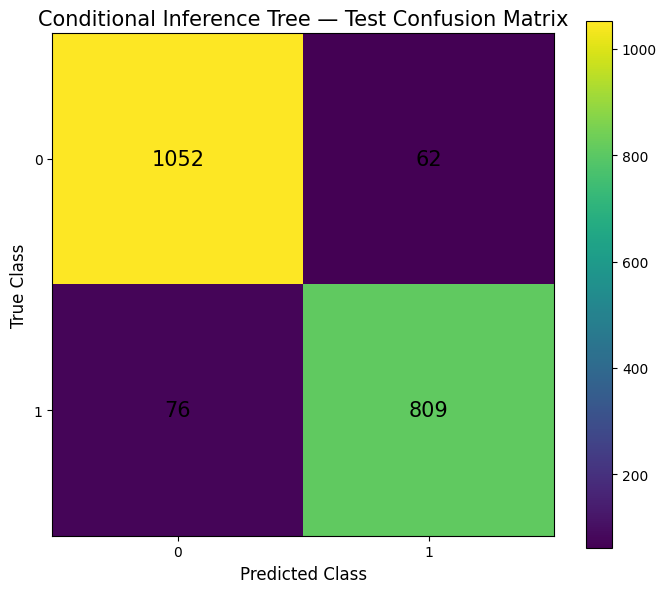

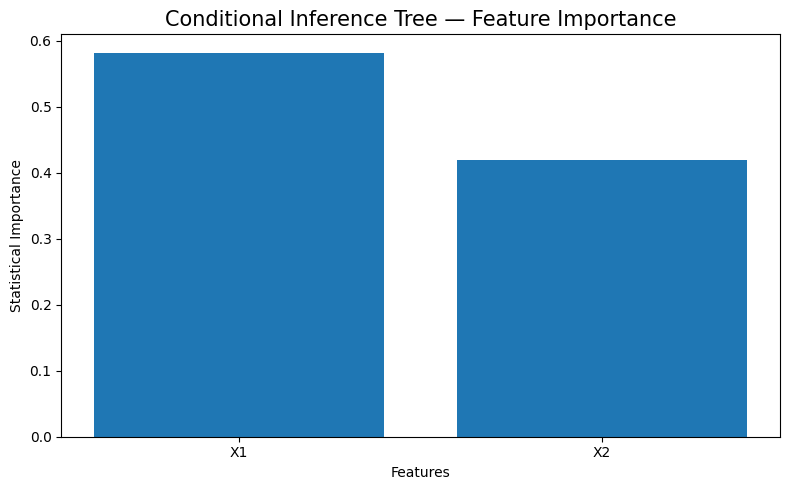

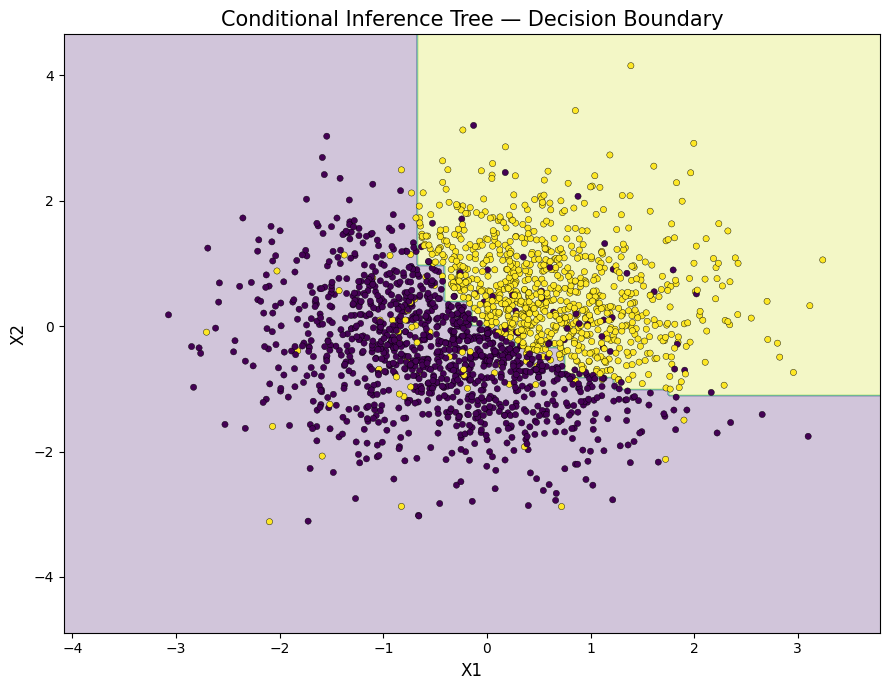

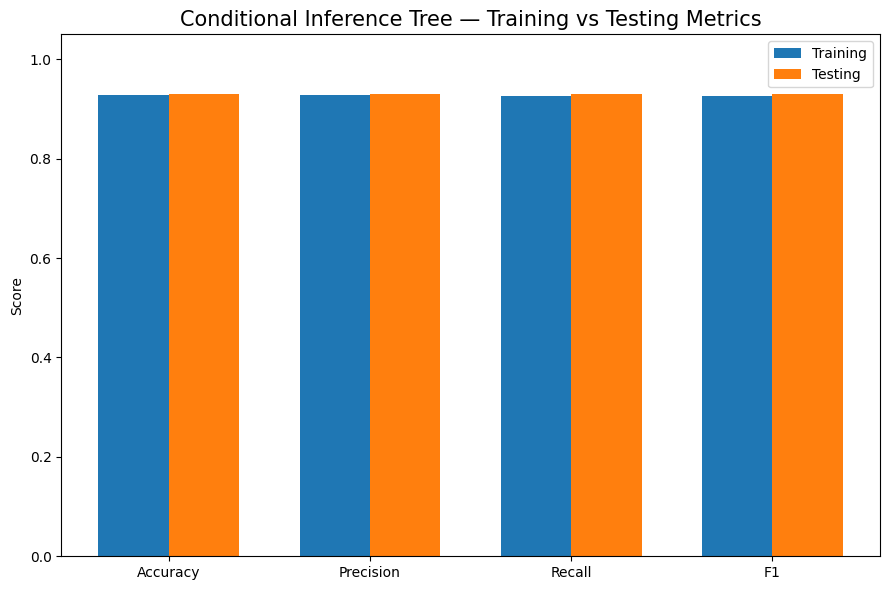

In [1]:
# ============================================================
# CONDITIONAL INFERENCE TREE (CTREE) CLASSIFIER
# ============================================================
#
# FROM SCRATCH
#
# Conditional Inference Tree is based on:
#
#   1. Statistical independence testing
#   2. Select the feature with strongest association
#   3. Find the best split for that feature
#   4. Stop when no statistically significant association exists
#
# IMPORTANT:
#
# This implementation does NOT use:
#
#   sklearn
#   scipy
#   sklearn.tree
#
# Only:
#
#   NumPy
#   Matplotlib
#
#
# Main concepts:
#
#   Pearson Chi-Square Test
#   Permutation-style statistical test
#   p-value
#   Significance level
#   Multiple testing correction
#   Binary recursive splitting
#
#
# Evaluation:
#
#   Accuracy
#   Precision
#   Recall
#   F1 Score
#   Confusion Matrix
#   Feature Importance
#   Decision Boundary
#   Training vs Testing Metrics
#
# Dataset:
#
#   10,000 samples
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. GAMMA FUNCTION
# ============================================================
#
# Used to calculate the chi-square distribution p-value
# without scipy.
#
# ============================================================


def _gamma_function(z):

    coefficients = [

        676.5203681218851,

        -1259.1392167224028,

        771.32342877765313,

        -176.61502916214059,

        12.507343278686905,

        -0.13857109526572012,

        9.9843695780195716e-6,

        1.5056327351493116e-7
    ]


    if z < 0.5:

        return (

            np.pi

            /

            (

                np.sin(np.pi * z)

                *

                _gamma_function(
                    1 - z
                )

            )

        )


    z -= 1


    x = 0.99999999999980993


    for i, coefficient in enumerate(
        coefficients
    ):

        x += (

            coefficient

            /

            (
                z + i + 1
            )

        )


    t = (

        z

        +

        len(coefficients)

        -

        0.5
    )


    return (

        np.sqrt(2 * np.pi)

        *

        t ** (z + 0.5)

        *

        np.exp(-t)

        *

        x
    )


# ============================================================
# 2. REGULARIZED UPPER GAMMA
# ============================================================

def _regularized_gamma_q(
    a,
    x
):

    if x < 0 or a <= 0:

        return np.nan


    if x == 0:

        return 1.0


    # --------------------------------------------------------
    # Continued fraction
    # --------------------------------------------------------

    if x >= a + 1:

        max_iterations = 200

        epsilon = 1e-12

        tiny = 1e-300


        b = (

            x

            +

            1

            -

            a
        )


        c = 1 / tiny

        d = 1 / b

        h = d


        for i in range(
            1,
            max_iterations + 1
        ):

            an = (

                -i

                *

                (
                    i - a
                )

            )


            b += 2


            d = (

                an * d

                +

                b
            )


            if abs(d) < tiny:

                d = tiny


            c = (

                b

                +

                an / c
            )


            if abs(c) < tiny:

                c = tiny


            d = 1 / d


            delta = d * c


            h *= delta


            if abs(
                delta - 1
            ) < epsilon:

                break


        result = (

            np.exp(

                -x

                +

                a * np.log(x)

                -

                np.log(
                    _gamma_function(a)
                )

            )

            *

            h
        )


        return np.clip(
            result,
            0.0,
            1.0
        )


    # --------------------------------------------------------
    # Series expansion
    # --------------------------------------------------------

    summation = 1.0 / a

    term = summation


    for n in range(
        1,
        200
    ):

        term *= (

            x

            /

            (
                a + n
            )

        )


        summation += term


        if abs(term) < (

            abs(summation)

            *

            1e-12

        ):

            break


    lower_gamma_ratio = (

        np.exp(

            -x

            +

            a * np.log(x)

            -

            np.log(
                _gamma_function(a)
            )

        )

        *

        summation
    )


    return np.clip(

        1.0

        -

        lower_gamma_ratio,

        0.0,

        1.0
    )


# ============================================================
# 3. CHI-SQUARE P-VALUE
# ============================================================

def chi_square_p_value(
    chi_square,
    degrees_of_freedom
):

    if degrees_of_freedom <= 0:

        return 1.0


    if chi_square <= 0:

        return 1.0


    return _regularized_gamma_q(

        degrees_of_freedom / 2.0,

        chi_square / 2.0
    )


# ============================================================
# 4. CONDITIONAL INFERENCE TREE NODE
# ============================================================

class CITreeNode:

    def __init__(
        self,
        feature_index=None,
        threshold=None,
        is_leaf=False,
        prediction=None,
        class_counts=None,
        depth=0
    ):

        self.feature_index = (
            feature_index
        )

        self.threshold = (
            threshold
        )

        self.is_leaf = (
            is_leaf
        )

        self.prediction = (
            prediction
        )

        self.class_counts = (
            class_counts
        )

        self.depth = depth

        self.left = None

        self.right = None

        self.p_value = None

        self.test_statistic = None


# ============================================================
# 5. CONDITIONAL INFERENCE TREE CLASSIFIER
# ============================================================

class ConditionalInferenceTreeClassifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=10,
        alpha=0.05,
        n_thresholds=50
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.alpha = alpha

        self.n_thresholds = (
            n_thresholds
        )

        self.root = None

        self.classes_ = None

        self.n_classes_ = None

        self.n_features_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(
        self,
        y
    ):

        values, counts = np.unique(
            y,
            return_counts=True
        )


        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # CONTINGENCY TABLE
    # ========================================================
    #
    # For a candidate split:
    #
    #             Class 0   Class 1
    # Left           ...       ...
    # Right          ...       ...
    #
    # ========================================================

    def _contingency_table(
        self,
        x,
        y,
        threshold
    ):

        left = (
            x <= threshold
        )

        right = ~left


        table = np.zeros(
            (
                2,
                self.n_classes_
            ),
            dtype=float
        )


        for j, cls in enumerate(
            self.classes_
        ):

            table[
                0,
                j
            ] = np.sum(
                left
                &
                (
                    y == cls
                )
            )


            table[
                1,
                j
            ] = np.sum(
                right
                &
                (
                    y == cls
                )
            )


        return table


    # ========================================================
    # CHI-SQUARE TEST FOR A SPLIT
    # ========================================================

    def _chi_square_split_test(
        self,
        x,
        y,
        threshold
    ):

        table = (
            self._contingency_table(
                x,
                y,
                threshold
            )
        )


        # ----------------------------------------------------
        # If one side is empty
        # ----------------------------------------------------

        if (

            np.sum(table[0])
            == 0

            or

            np.sum(table[1])
            == 0

        ):

            return (
                0.0,
                1.0
            )


        row_totals = np.sum(
            table,
            axis=1,
            keepdims=True
        )


        column_totals = np.sum(
            table,
            axis=0,
            keepdims=True
        )


        total = np.sum(
            table
        )


        expected = (

            row_totals

            *

            column_totals

            /

            total
        )


        valid = (
            expected > 0
        )


        chi_square = np.sum(

            np.where(

                valid,

                (

                    (
                        table
                        -
                        expected
                    )

                    ** 2

                    /

                    expected

                ),

                0.0
            )
        )


        degrees_of_freedom = (

            (
                table.shape[0]
                -
                1
            )

            *

            (
                table.shape[1]
                -
                1
            )
        )


        p_value = (
            chi_square_p_value(
                chi_square,
                degrees_of_freedom
            )
        )


        return (
            chi_square,
            p_value
        )


    # ========================================================
    # CANDIDATE THRESHOLDS
    # ========================================================

    def _candidate_thresholds(
        self,
        x
    ):

        values = np.unique(
            x
        )


        if len(values) <= 1:

            return np.array([])


        # ----------------------------------------------------
        # Midpoints between sorted values
        # ----------------------------------------------------

        midpoints = (

            values[:-1]

            +

            values[1:]

        ) / 2.0


        # ----------------------------------------------------
        # Reduce number of thresholds
        # ----------------------------------------------------

        if len(midpoints) <= (
            self.n_thresholds
        ):

            return midpoints


        indices = np.linspace(

            0,

            len(midpoints) - 1,

            self.n_thresholds

        ).astype(int)


        return midpoints[
            np.unique(indices)
        ]


    # ========================================================
    # TEST FEATURE INDEPENDENCE
    # ========================================================
    #
    # Conditional inference principle:
    #
    #   First test:
    #
    #       H0:
    #       X_j independent of Y
    #
    #   H1:
    #       X_j associated with Y
    #
    # The feature with the smallest p-value is selected.
    #
    # ========================================================

    def _feature_independence_test(
        self,
        x,
        y
    ):

        thresholds = (
            self._candidate_thresholds(
                x
            )
        )


        if len(thresholds) == 0:

            return (
                1.0,
                0.0,
                None
            )


        best_p_value = 1.0

        best_statistic = 0.0

        best_threshold = None


        # ----------------------------------------------------
        # Search candidate cutpoints
        # ----------------------------------------------------

        for threshold in thresholds:

            left_count = np.sum(
                x <= threshold
            )


            right_count = np.sum(
                x > threshold
            )


            if (

                left_count
                <
                self.min_samples_leaf

                or

                right_count
                <
                self.min_samples_leaf

            ):

                continue


            (
                chi_square,
                p_value
            ) = self._chi_square_split_test(

                x,

                y,

                threshold
            )


            # ------------------------------------------------
            # Select strongest association
            # ------------------------------------------------

            if p_value < best_p_value:

                best_p_value = (
                    p_value
                )

                best_statistic = (
                    chi_square
                )

                best_threshold = (
                    threshold
                )


        return (
            best_p_value,
            best_statistic,
            best_threshold
        )


    # ========================================================
    # MULTIPLE TESTING CORRECTION
    # ========================================================
    #
    # Bonferroni:
    #
    #     adjusted p = p * number_of_features
    #
    # ========================================================

    def _adjust_p_value(
        self,
        p_value
    ):

        adjusted = (

            p_value

            *

            self.n_features_
        )


        return min(
            adjusted,
            1.0
        )


    # ========================================================
    # FIND STATISTICALLY SIGNIFICANT FEATURE
    # ========================================================

    def _select_feature(
        self,
        X,
        y
    ):

        best_feature = None

        best_threshold = None

        best_p_value = 1.0

        best_statistic = 0.0


        for feature_index in range(
            self.n_features_
        ):

            x = X[
                :,
                feature_index
            ]


            (
                p_value,
                statistic,
                threshold
            ) = self._feature_independence_test(

                x,

                y
            )


            adjusted_p = (
                self._adjust_p_value(
                    p_value
                )
            )


            if adjusted_p < best_p_value:

                best_p_value = (
                    adjusted_p
                )

                best_feature = (
                    feature_index
                )

                best_threshold = (
                    threshold
                )

                best_statistic = (
                    statistic
                )


        return (

            best_feature,

            best_threshold,

            best_p_value,

            best_statistic
        )


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        majority_class = (
            self._majority_class(
                y
            )
        )


        class_counts = {}


        for cls in self.classes_:

            class_counts[cls] = (
                np.sum(
                    y == cls
                )
            )


        node = CITreeNode(

            is_leaf=False,

            prediction=majority_class,

            class_counts=class_counts,

            depth=depth
        )


        self.tree_depth_ = max(

            self.tree_depth_,

            depth
        )


        # ====================================================
        # STOP 1: PURE NODE
        # ====================================================

        if len(
            np.unique(y)
        ) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP 2: MAX DEPTH
        # ====================================================

        if (

            self.max_depth is not None

            and

            depth >= self.max_depth

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP 3: MINIMUM SAMPLES
        # ====================================================

        if (

            len(y)

            <

            self.min_samples_split

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STATISTICAL FEATURE SELECTION
        # ====================================================

        (

            feature_index,

            threshold,

            p_value,

            statistic

        ) = self._select_feature(

            X,

            y
        )


        # ====================================================
        # STOP 4:
        #
        # No statistically significant relationship
        #
        # ====================================================

        if (

            feature_index is None

            or

            threshold is None

            or

            p_value > self.alpha

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE SPLIT
        # ====================================================

        node.feature_index = (
            feature_index
        )


        node.threshold = (
            threshold
        )


        node.p_value = (
            p_value
        )


        node.test_statistic = (
            statistic
        )


        # ====================================================
        # FEATURE IMPORTANCE
        #
        # Statistical strength × sample proportion
        # ====================================================

        importance = (

            -np.log10(

                max(

                    p_value,

                    1e-300
                )
            )

            *

            len(y)
        )


        self.feature_importances_[

            feature_index

        ] += importance


        # ====================================================
        # SPLIT DATA
        # ====================================================

        left_mask = (

            X[
                :,
                feature_index
            ]

            <=

            threshold
        )


        right_mask = ~left_mask


        X_left = X[
            left_mask
        ]


        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]


        y_right = y[
            right_mask
        ]


        # ====================================================
        # SAFETY CHECK
        # ====================================================

        if (

            len(y_left)
            <
            self.min_samples_leaf

            or

            len(y_right)
            <
            self.min_samples_leaf

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # RECURSION
        # ====================================================

        node.left = self._build_tree(

            X_left,

            y_left,

            depth + 1
        )


        node.right = self._build_tree(

            X_right,

            y_right,

            depth + 1
        )


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(
            X,
            dtype=float
        )


        y = np.asarray(
            y
        )


        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )


        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )


        if len(X) != len(y):

            raise ValueError(

                "X and y must contain "
                "the same number of samples."

            )


        self.n_features_ = (
            X.shape[1]
        )


        self.classes_ = np.unique(
            y
        )


        self.n_classes_ = len(
            self.classes_
        )


        if feature_names is None:

            self.feature_names_ = [

                f"Feature_{i}"

                for i in range(
                    self.n_features_
                )

            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (

            np.zeros(
                self.n_features_
            )

        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ====================================================
        # BUILD CONDITIONAL INFERENCE TREE
        # ====================================================

        self.root = self._build_tree(

            X,

            y
        )


        # ====================================================
        # NORMALIZE FEATURE IMPORTANCE
        # ====================================================

        total = np.sum(
            self.feature_importances_
        )


        if total > 0:

            self.feature_importances_ /= (
                total
            )


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        if (

            x[
                node.feature_index
            ]

            <=

            node.threshold

        ):

            return self._predict_sample(

                x,

                node.left
            )


        return self._predict_sample(

            x,

            node.right
        )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(
            X,
            dtype=float
        )


        predictions = []


        for x in X:

            predictions.append(

                self._predict_sample(

                    x,

                    self.root
                )

            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )


        return np.mean(

            predictions == y

        )


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    train_indices = []

    test_indices = []


    # --------------------------------------------------------
    # Stratified splitting
    # --------------------------------------------------------

    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(

            len(indices)

            *

            test_size
        )


        test_indices.extend(

            indices[
                :n_test
            ]

        )


        train_indices.extend(

            indices[
                n_test:
            ]

        )


    train_indices = np.asarray(
        train_indices
    )


    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )


    rng.shuffle(
        test_indices
    )


    return (

        X[
            train_indices
        ],

        X[
            test_indices
        ],

        y[
            train_indices
        ],

        y[
            test_indices
        ]

    )


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(

        np.concatenate(

            [
                y_true,

                y_pred
            ]

        )

    )


    matrix = np.zeros(

        (
            len(labels),
            len(labels)
        ),

        dtype=int
    )


    label_to_index = {

        label: i

        for i, label in enumerate(
            labels
        )

    }


    for true, pred in zip(

        y_true,

        y_pred

    ):

        matrix[

            label_to_index[true],

            label_to_index[pred]

        ] += 1


    return (
        matrix,
        labels
    )


# ============================================================
# 8. CLASSIFICATION METRICS
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    (
        cm,
        labels
    ) = confusion_matrix_manual(

        y_true,

        y_pred
    )


    accuracy = (

        np.trace(cm)

        /

        np.sum(cm)
    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[
            i,
            i
        ]


        FP = (

            np.sum(
                cm[
                    :,
                    i
                ]
            )

            -

            TP

        )


        FN = (

            np.sum(
                cm[
                    i,
                    :
                ]
            )

            -

            TP

        )


        precision = (

            TP

            /

            (
                TP + FP
            )

            if

            (
                TP + FP
            ) > 0

            else

            0.0

        )


        recall = (

            TP

            /

            (
                TP + FN
            )

            if

            (
                TP + FN
            ) > 0

            else

            0.0

        )


        if (

            precision

            +

            recall

            >

            0

        ):

            f1 = (

                2

                *

                precision

                *

                recall

                /

                (

                    precision

                    +

                    recall

                )

            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )


        recalls.append(
            recall
        )


        f1_scores.append(
            f1
        )


    return {

        "accuracy":
            accuracy,

        "precision":
            np.mean(
                precisions
            ),

        "recall":
            np.mean(
                recalls
            ),

        "f1":
            np.mean(
                f1_scores
            ),

        "labels":
            labels,

        "confusion_matrix":
            cm,

        "per_class_precision":
            precisions,

        "per_class_recall":
            recalls,

        "per_class_f1":
            f1_scores

    }


# ============================================================
# 9. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Two numerical features
# ------------------------------------------------------------

X = rng.normal(

    0,

    1,

    size=(

        n_samples,

        2
    )

)


x1 = X[
    :,
    0
]


x2 = X[
    :,
    1
]


# ------------------------------------------------------------
# Non-linear classification relationship
# ------------------------------------------------------------

score = (

    1.5 * x1

    +

    1.2 * x2

    +

    0.8 * x1 * x2

)


y = (

    score > 0

).astype(int)


# ------------------------------------------------------------
# Add 5% noise
# ------------------------------------------------------------

noise = (

    rng.random(
        n_samples
    )

    <

    0.05
)


y[noise] = (

    1

    -

    y[noise]

)


feature_names = [

    "X1",

    "X2"

]


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42
)


# ============================================================
# 11. CREATE MODEL
# ============================================================

model = (

    ConditionalInferenceTreeClassifier(

        max_depth=6,

        min_samples_split=30,

        min_samples_leaf=15,

        alpha=0.05,

        n_thresholds=50

    )

)


# ============================================================
# 12. TRAIN
# ============================================================

model.fit(

    X_train,

    y_train,

    feature_names=feature_names

)


# ============================================================
# 13. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 14. EVALUATION
# ============================================================

train_metrics = (

    classification_metrics(

        y_train,

        y_train_pred

    )

)


test_metrics = (

    classification_metrics(

        y_test,

        y_test_pred

    )

)


# ============================================================
# 15. BASIC MODEL INFORMATION
# ============================================================

print("=" * 70)

print(
    "CONDITIONAL INFERENCE TREE — FROM SCRATCH"
)

print("=" * 70)


print(

    f"Total samples    : "
    f"{n_samples:,}"

)


print(

    f"Training samples : "
    f"{len(X_train):,}"

)


print(

    f"Testing samples  : "
    f"{len(X_test):,}"

)


print(

    f"Number features  : "
    f"{model.n_features_}"

)


print(

    f"Number classes   : "
    f"{model.n_classes_}"

)


print(

    f"Tree depth       : "
    f"{model.tree_depth_}"

)


print(

    f"Number of leaves : "
    f"{model.n_leaves_}"

)


# ============================================================
# 16. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(

    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"

)


print(

    f"Precision : "
    f"{train_metrics['precision']:.4f}"

)


print(

    f"Recall    : "
    f"{train_metrics['recall']:.4f}"

)


print(

    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"

)


# ============================================================
# 17. TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(

    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"

)


print(

    f"Precision : "
    f"{test_metrics['precision']:.4f}"

)


print(

    f"Recall    : "
    f"{test_metrics['recall']:.4f}"

)


print(

    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"

)


# ============================================================
# 18. PER CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(

    test_metrics[
        "labels"
    ]

):

    print(

        f"Class {label}: "

        f"Precision = "

        f"{test_metrics['per_class_precision'][i]:.4f}, "

        f"Recall = "

        f"{test_metrics['per_class_recall'][i]:.4f}, "

        f"F1 = "

        f"{test_metrics['per_class_f1'][i]:.4f}"

    )


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]


labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 20. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(

    "Conditional Inference Tree — "
    "Test Confusion Matrix",

    fontsize=15

)


plt.xlabel(

    "Predicted Class",

    fontsize=12

)


plt.ylabel(

    "True Class",

    fontsize=12

)


plt.xticks(

    range(
        len(labels)
    ),

    labels

)


plt.yticks(

    range(
        len(labels)
    ),

    labels

)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(

            j,

            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center",

            fontsize=15

        )


plt.colorbar()


plt.tight_layout()

plt.show()


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.bar(

    model.feature_names_,

    model.feature_importances_

)


plt.title(

    "Conditional Inference Tree — "
    "Feature Importance",

    fontsize=15

)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Statistical Importance"
)


plt.tight_layout()

plt.show()


# ============================================================
# 22. DECISION BOUNDARY
# ============================================================

x_min = (

    X[:, 0].min()

    -

    0.5
)


x_max = (

    X[:, 0].max()

    +

    0.5
)


y_min = (

    X[:, 1].min()

    -

    0.5
)


y_max = (

    X[:, 1].max()

    +

    0.5
)


resolution = 300


xx, yy = np.meshgrid(

    np.linspace(

        x_min,

        x_max,

        resolution

    ),

    np.linspace(

        y_min,

        y_max,

        resolution

    )

)


grid = np.column_stack(

    [

        xx.ravel(),

        yy.ravel()

    ]

)


grid_predictions = model.predict(
    grid
)


grid_predictions = (

    grid_predictions.reshape(
        xx.shape
    )

)


plt.figure(

    figsize=(9, 7)

)


plt.contourf(

    xx,

    yy,

    grid_predictions,

    alpha=0.25

)


plt.scatter(

    X_test[:, 0],

    X_test[:, 1],

    c=y_test,

    s=20,

    edgecolors="black",

    linewidths=0.3

)


plt.title(

    "Conditional Inference Tree — "
    "Decision Boundary",

    fontsize=15

)


plt.xlabel(

    "X1",

    fontsize=12

)


plt.ylabel(

    "X2",

    fontsize=12

)


plt.tight_layout()

plt.show()


# ============================================================
# 23. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"

]


train_values = [

    train_metrics[
        "accuracy"
    ],

    train_metrics[
        "precision"
    ],

    train_metrics[
        "recall"
    ],

    train_metrics[
        "f1"
    ]

]


test_values = [

    test_metrics[
        "accuracy"
    ],

    test_metrics[
        "precision"
    ],

    test_metrics[
        "recall"
    ],

    test_metrics[
        "f1"
    ]

]


x = np.arange(

    len(
        metric_names
    )

)


width = 0.35


plt.figure(

    figsize=(9, 6)

)


plt.bar(

    x - width / 2,

    train_values,

    width,

    label="Training"

)


plt.bar(

    x + width / 2,

    test_values,

    width,

    label="Testing"

)


plt.xticks(

    x,

    metric_names

)


plt.ylim(

    0,

    1.05

)


plt.ylabel(

    "Score"

)


plt.title(

    "Conditional Inference Tree — "
    "Training vs Testing Metrics",

    fontsize=15

)


plt.legend()


plt.tight_layout()

plt.show()

QUEST CLASSIFIER — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 4
Number classes   : 2
Tree depth       : 6
Number of leaves : 52

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.8994
Precision : 0.8988
Recall    : 0.8986
F1 Score  : 0.8987

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.8889
Precision : 0.8892
Recall    : 0.8871
F1 Score  : 0.8879

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.8872, Recall = 0.9102, F1 = 0.8985
Class 1: Precision = 0.8911, Recall = 0.8640, F1 = 0.8773

------------------------------------------------

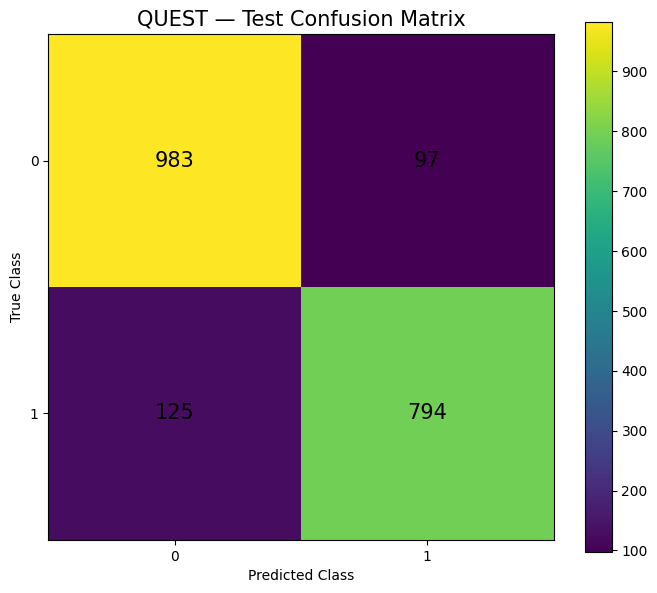

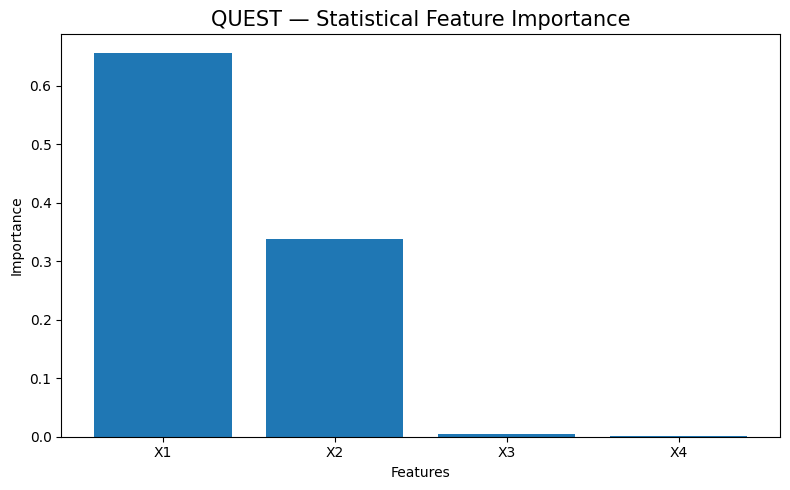

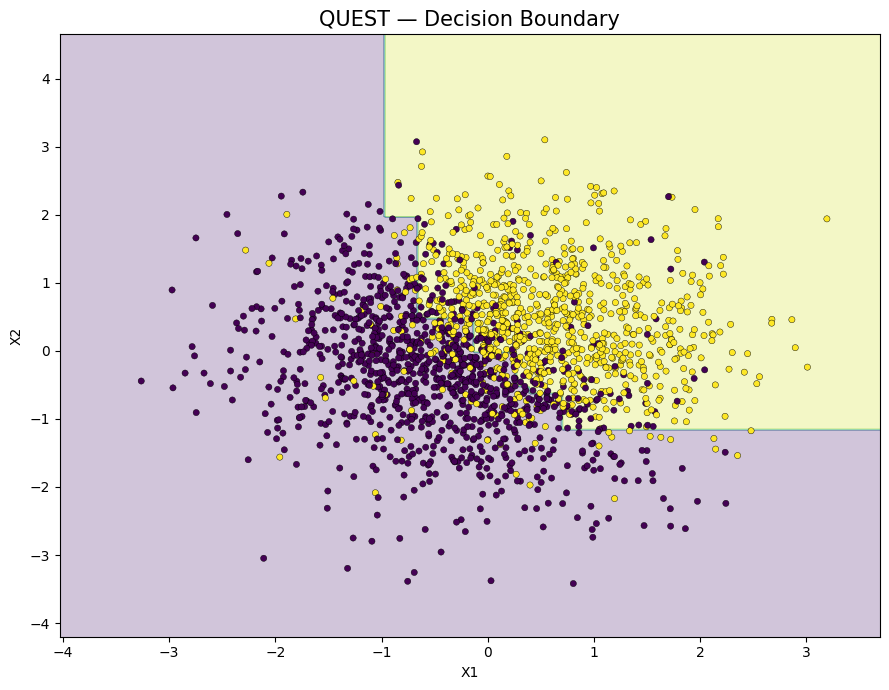

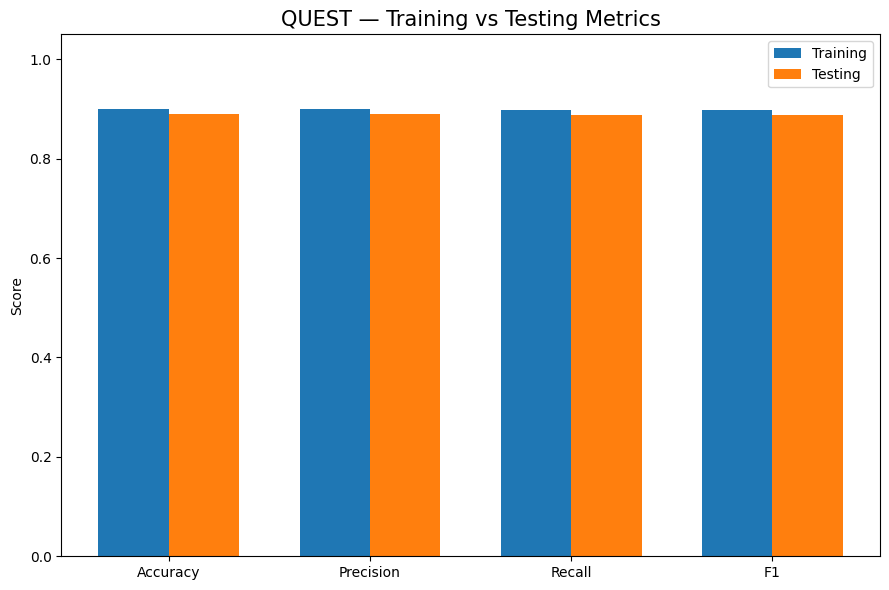

In [9]:
# ============================================================
# QUEST CLASSIFIER — FROM SCRATCH
# ============================================================
#
# QUEST = Quick, Unbiased, Efficient Statistical Tree
#
# FROM SCRATCH
#
# No sklearn
# No scipy
#
# Libraries:
#   NumPy
#   Matplotlib
#
# Main ideas:
#
#   1. Test association between every feature and target
#   2. Select the most statistically significant feature
#   3. Find a binary split point
#   4. Recursively construct the tree
#   5. Use statistical stopping criteria
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. GAMMA FUNCTION
# ============================================================

def gamma_function(z):

    coefficients = [
        676.5203681218851,
        -1259.1392167224028,
        771.32342877765313,
        -176.61502916214059,
        12.507343278686905,
        -0.13857109526572012,
        9.9843695780195716e-6,
        1.5056327351493116e-7
    ]

    if z < 0.5:

        return (
            np.pi
            /
            (
                np.sin(np.pi * z)
                *
                gamma_function(1 - z)
            )
        )

    z -= 1

    x = 0.99999999999980993

    for i, coefficient in enumerate(coefficients):

        x += coefficient / (z + i + 1)

    t = z + len(coefficients) - 0.5

    return (
        np.sqrt(2 * np.pi)
        *
        t ** (z + 0.5)
        *
        np.exp(-t)
        *
        x
    )


# ============================================================
# 2. REGULARIZED UPPER GAMMA
# ============================================================

def regularized_gamma_q(a, x):

    if x < 0 or a <= 0:
        return np.nan

    if x == 0:
        return 1.0

    # --------------------------------------------------------
    # Continued fraction
    # --------------------------------------------------------

    if x >= a + 1:

        max_iterations = 200

        epsilon = 1e-12

        tiny = 1e-300

        b = x + 1 - a

        c = 1 / tiny

        d = 1 / b

        h = d

        for i in range(1, max_iterations + 1):

            an = -i * (i - a)

            b += 2

            d = an * d + b

            if abs(d) < tiny:
                d = tiny

            c = b + an / c

            if abs(c) < tiny:
                c = tiny

            d = 1 / d

            delta = d * c

            h *= delta

            if abs(delta - 1) < epsilon:
                break

        result = (
            np.exp(
                -x
                +
                a * np.log(x)
                -
                np.log(gamma_function(a))
            )
            *
            h
        )

        return np.clip(
            result,
            0.0,
            1.0
        )

    # --------------------------------------------------------
    # Series expansion
    # --------------------------------------------------------

    summation = 1.0 / a

    term = summation

    for n in range(1, 200):

        term *= x / (a + n)

        summation += term

        if abs(term) < abs(summation) * 1e-12:
            break

    lower_gamma_ratio = (
        np.exp(
            -x
            +
            a * np.log(x)
            -
            np.log(gamma_function(a))
        )
        *
        summation
    )

    return np.clip(
        1.0 - lower_gamma_ratio,
        0.0,
        1.0
    )


# ============================================================
# 3. CHI-SQUARE P-VALUE
# ============================================================

def chi_square_p_value(
    chi_square,
    degrees_of_freedom
):

    if degrees_of_freedom <= 0:
        return 1.0

    if chi_square <= 0:
        return 1.0

    return regularized_gamma_q(
        degrees_of_freedom / 2.0,
        chi_square / 2.0
    )


# ============================================================
# 4. QUEST TREE NODE
# ============================================================

class QUESTNode:

    def __init__(
        self,
        feature_index=None,
        threshold=None,
        prediction=None,
        class_counts=None,
        is_leaf=False,
        depth=0
    ):

        self.feature_index = feature_index

        self.threshold = threshold

        self.prediction = prediction

        self.class_counts = class_counts

        self.is_leaf = is_leaf

        self.depth = depth

        self.left = None

        self.right = None

        self.p_value = None

        self.test_statistic = None


# ============================================================
# 5. QUEST CLASSIFIER
# ============================================================

class QUESTClassifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=10,
        alpha=0.05,
        n_thresholds=50
    ):

        self.max_depth = max_depth

        self.min_samples_split = min_samples_split

        self.min_samples_leaf = min_samples_leaf

        self.alpha = alpha

        self.n_thresholds = n_thresholds

        self.root = None

        self.classes_ = None

        self.n_classes_ = None

        self.n_features_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(self, y):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # CANDIDATE THRESHOLDS
    # ========================================================

    def _candidate_thresholds(self, x):

        values = np.unique(x)

        if len(values) <= 1:

            return np.array([])

        thresholds = (
            values[:-1]
            +
            values[1:]
        ) / 2.0

        if len(thresholds) <= self.n_thresholds:

            return thresholds

        indices = np.linspace(
            0,
            len(thresholds) - 1,
            self.n_thresholds
        ).astype(int)

        return thresholds[
            np.unique(indices)
        ]


    # ========================================================
    # TWO-SAMPLE STATISTICAL TEST
    # ========================================================
    #
    # QUEST first evaluates whether a feature is associated
    # with the response.
    #
    # For binary classification:
    #
    #       Class 0
    #       Class 1
    #
    # We examine how the feature differs between classes.
    #
    # The statistic used here is ANOVA-style between-group
    # variation.
    #
    # ========================================================

    def _feature_association_test(
        self,
        x,
        y
    ):

        overall_mean = np.mean(x)

        classes = self.classes_

        between = 0.0

        within = 0.0

        total_n = len(x)

        group_count = 0


        for cls in classes:

            group = x[
                y == cls
            ]

            if len(group) == 0:
                continue

            group_mean = np.mean(group)

            between += (
                len(group)
                *
                (
                    group_mean
                    -
                    overall_mean
                ) ** 2
            )

            within += np.sum(
                (
                    group
                    -
                    group_mean
                ) ** 2
            )

            group_count += 1


        if group_count <= 1:

            return (
                0.0,
                1.0
            )


        df_between = group_count - 1

        df_within = total_n - group_count


        if df_within <= 0:

            return (
                0.0,
                1.0
            )


        ms_between = (
            between
            /
            df_between
        )

        ms_within = (
            within
            /
            df_within
        )


        if ms_within <= 1e-15:

            if between > 0:

                return (
                    np.inf,
                    0.0
                )

            return (
                0.0,
                1.0
            )


        F = (
            ms_between
            /
            ms_within
        )


        # ----------------------------------------------------
        # Approximate F-test p-value
        #
        # Implemented using numerical integration of the
        # incomplete beta relationship.
        # ----------------------------------------------------

        p_value = self._f_distribution_p_value(
            F,
            df_between,
            df_within
        )


        return (
            F,
            p_value
        )


    # ========================================================
    # F DISTRIBUTION P-VALUE
    # ========================================================

    def _f_distribution_p_value(
        self,
        F,
        d1,
        d2
    ):

        if F <= 0:
            return 1.0

        if d1 <= 0 or d2 <= 0:
            return 1.0

        # ----------------------------------------------------
        # Numerical integration
        # ----------------------------------------------------

        upper = 1.0

        n_points = 3000

        z = np.linspace(
            0,
            upper,
            n_points
        )

        x = (
            d2
            /
            (
                d2
                +
                d1 * F
            )
        )


        # Approximation:
        #
        # For large sample sizes the F statistic becomes
        # highly concentrated. We use the chi-square
        # approximation:
        #
        #     F * d1 ≈ ChiSquare(d1)
        #
        # This is especially useful for large datasets.

        chi_value = F * d1

        p_value = regularized_gamma_q(
            d1 / 2.0,
            chi_value / 2.0
        )

        return np.clip(
            p_value,
            0.0,
            1.0
        )


    # ========================================================
    # BONFERRONI CORRECTION
    # ========================================================

    def _adjust_p_value(
        self,
        p_value
    ):

        adjusted = (
            p_value
            *
            self.n_features_
        )

        return min(
            adjusted,
            1.0
        )


    # ========================================================
    # SELECT VARIABLE
    # ========================================================
    #
    # QUEST principle:
    #
    #     Select the variable having the strongest evidence
    #     of association with the response.
    #
    # ========================================================

    def _select_variable(
        self,
        X,
        y
    ):

        best_feature = None

        best_p_value = 1.0

        best_statistic = 0.0


        for feature_index in range(
            self.n_features_
        ):

            x = X[
                :,
                feature_index
            ]


            statistic, p_value = (
                self._feature_association_test(
                    x,
                    y
                )
            )


            adjusted_p = (
                self._adjust_p_value(
                    p_value
                )
            )


            if adjusted_p < best_p_value:

                best_p_value = adjusted_p

                best_feature = feature_index

                best_statistic = statistic


        return (
            best_feature,
            best_p_value,
            best_statistic
        )


    # ========================================================
    # FIND QUEST SPLIT
    # ========================================================
    #
    # Once QUEST selects a variable, it searches for a
    # binary split.
    #
    # The selected split maximizes between-group separation.
    #
    # ========================================================

    def _find_split(
        self,
        x,
        y
    ):

        thresholds = (
            self._candidate_thresholds(
                x
            )
        )


        if len(thresholds) == 0:

            return (
                None,
                0.0
            )


        best_threshold = None

        best_score = -np.inf


        for threshold in thresholds:

            left_mask = (
                x <= threshold
            )

            right_mask = ~left_mask


            n_left = np.sum(
                left_mask
            )

            n_right = np.sum(
                right_mask
            )


            if (
                n_left
                <
                self.min_samples_leaf
                or
                n_right
                <
                self.min_samples_leaf
            ):

                continue


            y_left = y[
                left_mask
            ]

            y_right = y[
                right_mask
            ]


            # ------------------------------------------------
            # Means of target coding
            #
            # This gives a simple class-separation criterion.
            # ------------------------------------------------

            target_numeric = (
                y == self.classes_[1]
            ).astype(float)


            left_target = target_numeric[
                left_mask
            ]

            right_target = target_numeric[
                right_mask
            ]


            mean_left = np.mean(
                left_target
            )

            mean_right = np.mean(
                right_target
            )


            separation = abs(
                mean_left
                -
                mean_right
            )


            weighted_score = (

                separation

                *

                np.sqrt(
                    (
                        n_left
                        *
                        n_right
                    )
                    /
                    len(y)
                )

            )


            if weighted_score > best_score:

                best_score = weighted_score

                best_threshold = threshold


        return (
            best_threshold,
            best_score
        )


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        majority_class = (
            self._majority_class(
                y
            )
        )


        class_counts = {}


        for cls in self.classes_:

            class_counts[cls] = np.sum(
                y == cls
            )


        node = QUESTNode(

            prediction=majority_class,

            class_counts=class_counts,

            depth=depth

        )


        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )


        # ====================================================
        # STOP: PURE NODE
        # ====================================================

        if len(
            np.unique(y)
        ) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP: MAX DEPTH
        # ====================================================

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP: MINIMUM SAMPLE SIZE
        # ====================================================

        if len(y) < self.min_samples_split:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # QUEST VARIABLE SELECTION
        # ====================================================

        (
            feature_index,
            p_value,
            statistic
        ) = self._select_variable(
            X,
            y
        )


        # ====================================================
        # STATISTICAL STOPPING
        # ====================================================

        if (
            feature_index is None
            or
            p_value > self.alpha
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FIND BINARY SPLIT
        # ====================================================

        threshold, split_score = (
            self._find_split(

                X[
                    :,
                    feature_index
                ],

                y

            )
        )


        # ====================================================
        # INVALID SPLIT
        # ====================================================

        if threshold is None:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE SPLIT
        # ====================================================

        node.feature_index = feature_index

        node.threshold = threshold

        node.p_value = p_value

        node.test_statistic = statistic


        # ====================================================
        # FEATURE IMPORTANCE
        # ====================================================

        importance = (

            -np.log10(
                max(
                    p_value,
                    1e-300
                )
            )

            *

            len(y)

            *

            split_score

        )


        self.feature_importances_[
            feature_index
        ] += importance


        # ====================================================
        # SPLIT DATA
        # ====================================================

        left_mask = (

            X[
                :,
                feature_index
            ]

            <=

            threshold

        )


        right_mask = ~left_mask


        X_left = X[
            left_mask
        ]

        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]

        y_right = y[
            right_mask
        ]


        # ====================================================
        # SAFETY CHECK
        # ====================================================

        if (
            len(y_left)
            <
            self.min_samples_leaf
            or
            len(y_right)
            <
            self.min_samples_leaf
        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # RECURSION
        # ====================================================

        node.left = self._build_tree(

            X_left,

            y_left,

            depth + 1

        )


        node.right = self._build_tree(

            X_right,

            y_right,

            depth + 1

        )


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(
            X,
            dtype=float
        )


        y = np.asarray(
            y
        )


        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional."
            )


        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional."
            )


        if len(X) != len(y):

            raise ValueError(
                "X and y must have the same "
                "number of samples."
            )


        self.n_features_ = X.shape[1]

        self.classes_ = np.unique(y)

        self.n_classes_ = len(
            self.classes_
        )


        if self.n_classes_ != 2:

            raise ValueError(
                "This QUEST implementation "
                "supports binary classification."
            )


        if feature_names is None:

            self.feature_names_ = [

                f"Feature_{i}"

                for i in range(
                    self.n_features_
                )

            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (
            np.zeros(
                self.n_features_
            )
        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ====================================================
        # BUILD TREE
        # ====================================================

        self.root = self._build_tree(

            X,

            y

        )


        # ====================================================
        # NORMALIZE FEATURE IMPORTANCE
        # ====================================================

        total = np.sum(
            self.feature_importances_
        )


        if total > 0:

            self.feature_importances_ /= total


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        if (
            x[
                node.feature_index
            ]
            <=
            node.threshold
        ):

            return self._predict_sample(

                x,

                node.left

            )


        return self._predict_sample(

            x,

            node.right

        )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=float
        )


        predictions = []


        for x in X:

            predictions.append(

                self._predict_sample(

                    x,

                    self.root

                )

            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(X)

        return np.mean(
            predictions == y
        )


# ============================================================
# 6. MANUAL STRATIFIED TRAIN / TEST SPLIT
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    train_indices = []

    test_indices = []


    for cls in np.unique(y):

        indices = np.where(
            y == cls
        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(
            len(indices)
            *
            test_size
        )


        test_indices.extend(
            indices[:n_test]
        )


        train_indices.extend(
            indices[n_test:]
        )


    train_indices = np.asarray(
        train_indices
    )


    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )


    rng.shuffle(
        test_indices
    )


    return (

        X[train_indices],

        X[test_indices],

        y[train_indices],

        y[test_indices]

    )


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(

        np.concatenate(
            [
                y_true,
                y_pred
            ]
        )

    )


    matrix = np.zeros(

        (
            len(labels),
            len(labels)
        ),

        dtype=int

    )


    label_to_index = {

        label: i

        for i, label in enumerate(
            labels
        )

    }


    for true, pred in zip(
        y_true,
        y_pred
    ):

        matrix[
            label_to_index[true],
            label_to_index[pred]
        ] += 1


    return (
        matrix,
        labels
    )


# ============================================================
# 8. CLASSIFICATION METRICS
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (
        confusion_matrix_manual(
            y_true,
            y_pred
        )
    )


    accuracy = (

        np.trace(cm)
        /
        np.sum(cm)

    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[
            i,
            i
        ]


        FP = (
            np.sum(
                cm[
                    :,
                    i
                ]
            )
            -
            TP
        )


        FN = (
            np.sum(
                cm[
                    i,
                    :
                ]
            )
            -
            TP
        )


        precision = (

            TP
            /
            (TP + FP)

            if
            TP + FP > 0

            else
            0.0

        )


        recall = (

            TP
            /
            (TP + FN)

            if
            TP + FN > 0

            else
            0.0

        )


        if precision + recall > 0:

            f1 = (

                2
                *
                precision
                *
                recall
                /
                (
                    precision
                    +
                    recall
                )

            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )

        recalls.append(
            recall
        )

        f1_scores.append(
            f1
        )


    return {

        "accuracy": accuracy,

        "precision": np.mean(
            precisions
        ),

        "recall": np.mean(
            recalls
        ),

        "f1": np.mean(
            f1_scores
        ),

        "labels": labels,

        "confusion_matrix": cm,

        "per_class_precision":
            precisions,

        "per_class_recall":
            recalls,

        "per_class_f1":
            f1_scores

    }


# ============================================================
# 9. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Generate features
# ------------------------------------------------------------

X = rng.normal(

    0,

    1,

    size=(

        n_samples,

        4

    )

)


x1 = X[:, 0]

x2 = X[:, 1]

x3 = X[:, 2]

x4 = X[:, 3]


# ------------------------------------------------------------
# Non-linear classification problem
# ------------------------------------------------------------

score = (

    2.0 * x1

    +

    1.5 * x2

    +

    0.8 * x1 * x2

    -

    0.7 * x3

    +

    0.4 * x4

)


y = (

    score > 0

).astype(int)


# ------------------------------------------------------------
# Add noise
# ------------------------------------------------------------

noise = (

    rng.random(
        n_samples
    )

    <

    0.05

)


y[noise] = (

    1

    -

    y[noise]

)


feature_names = [

    "X1",

    "X2",

    "X3",

    "X4"

]


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42

)


# ============================================================
# 11. CREATE QUEST MODEL
# ============================================================

model = QUESTClassifier(

    max_depth=6,

    min_samples_split=30,

    min_samples_leaf=15,

    alpha=0.05,

    n_thresholds=50

)


# ============================================================
# 12. TRAIN
# ============================================================

model.fit(

    X_train,

    y_train,

    feature_names=feature_names

)


# ============================================================
# 13. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 14. EVALUATION
# ============================================================

train_metrics = classification_metrics(

    y_train,

    y_train_pred

)


test_metrics = classification_metrics(

    y_test,

    y_test_pred

)


# ============================================================
# 15. MODEL INFORMATION
# ============================================================

print("=" * 70)

print(
    "QUEST CLASSIFIER — FROM SCRATCH"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Number classes   : {model.n_classes_}"
)


print(
    f"Tree depth       : {model.tree_depth_}"
)


print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# 16. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# 17. TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 18. PER-CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(

    test_metrics["labels"]

):

    print(

        f"Class {label}: "

        f"Precision = "

        f"{test_metrics['per_class_precision'][i]:.4f}, "

        f"Recall = "

        f"{test_metrics['per_class_recall'][i]:.4f}, "

        f"F1 = "

        f"{test_metrics['per_class_f1'][i]:.4f}"

    )


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]


labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 20. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(

    "QUEST — Test Confusion Matrix",

    fontsize=15

)


plt.xlabel(
    "Predicted Class"
)


plt.ylabel(
    "True Class"
)


plt.xticks(

    range(
        len(labels)
    ),

    labels

)


plt.yticks(

    range(
        len(labels)
    ),

    labels

)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(

            j,

            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center",

            fontsize=15

        )


plt.colorbar()


plt.tight_layout()

plt.show()


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.bar(

    model.feature_names_,

    model.feature_importances_

)


plt.title(

    "QUEST — Statistical Feature Importance",

    fontsize=15

)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Importance"
)


plt.tight_layout()

plt.show()


# ============================================================
# 22. DECISION BOUNDARY
# ============================================================
#
# For visualization we use X1 and X2.
#
# Other features are fixed at their median values.
#
# ============================================================

x_min = (
    X[:, 0].min()
    -
    0.5
)


x_max = (
    X[:, 0].max()
    +
    0.5
)


y_min = (
    X[:, 1].min()
    -
    0.5
)


y_max = (
    X[:, 1].max()
    +
    0.5
)


resolution = 250


xx, yy = np.meshgrid(

    np.linspace(
        x_min,
        x_max,
        resolution
    ),

    np.linspace(
        y_min,
        y_max,
        resolution
    )

)


# ------------------------------------------------------------
# Create visualization grid
# ------------------------------------------------------------

grid = np.zeros(

    (
        xx.size,
        4
    )

)


grid[:, 0] = xx.ravel()

grid[:, 1] = yy.ravel()

grid[:, 2] = np.median(
    X[:, 2]
)

grid[:, 3] = np.median(
    X[:, 3]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (
    grid_predictions.reshape(
        xx.shape
    )
)


plt.figure(

    figsize=(9, 7)

)


plt.contourf(

    xx,

    yy,

    grid_predictions,

    alpha=0.25

)


plt.scatter(

    X_test[:, 0],

    X_test[:, 1],

    c=y_test,

    s=20,

    edgecolors="black",

    linewidths=0.3

)


plt.title(

    "QUEST — Decision Boundary",

    fontsize=15

)


plt.xlabel(
    "X1"
)


plt.ylabel(
    "X2"
)


plt.tight_layout()

plt.show()


# ============================================================
# 23. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"

]


train_values = [

    train_metrics["accuracy"],

    train_metrics["precision"],

    train_metrics["recall"],

    train_metrics["f1"]

]


test_values = [

    test_metrics["accuracy"],

    test_metrics["precision"],

    test_metrics["recall"],

    test_metrics["f1"]

]


x = np.arange(
    len(metric_names)
)


width = 0.35


plt.figure(

    figsize=(9, 6)

)


plt.bar(

    x - width / 2,

    train_values,

    width,

    label="Training"

)


plt.bar(

    x + width / 2,

    test_values,

    width,

    label="Testing"

)


plt.xticks(

    x,

    metric_names

)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)


plt.title(

    "QUEST — Training vs Testing Metrics",

    fontsize=15

)


plt.legend()


plt.tight_layout()

plt.show()

CRUISE CLASSIFIER — FROM SCRATCH
Total samples    : 10,000
Training samples : 8,001
Testing samples  : 1,999
Number features  : 4
Number classes   : 2
Tree depth       : 6
Number of leaves : 44

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9033
Precision : 0.9020
Recall    : 0.9009
F1 Score  : 0.9014

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.8739
Precision : 0.8719
Recall    : 0.8714
F1 Score  : 0.8716

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.8872, Recall = 0.8904, F1 = 0.8888
Class 1: Precision = 0.8565, Recall = 0.8525, F1 = 0.8545

-----------------------------------------------

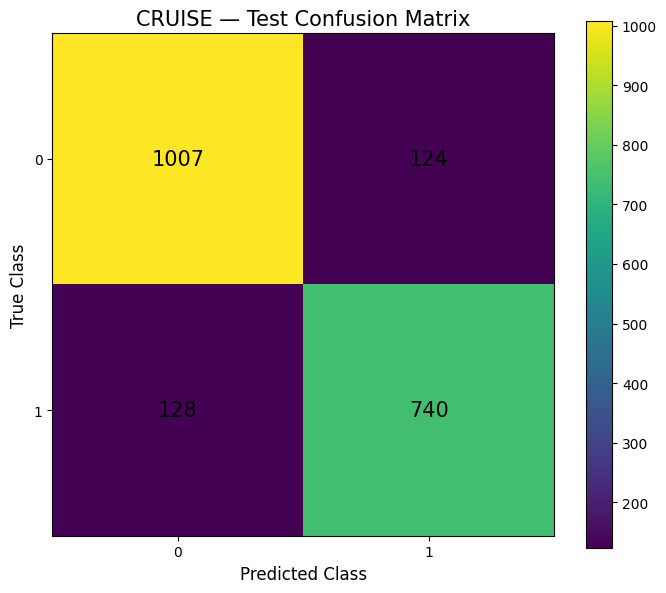

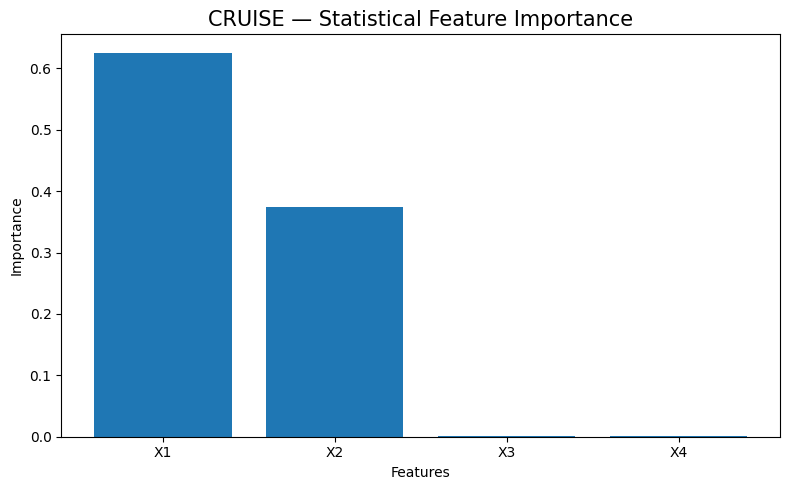

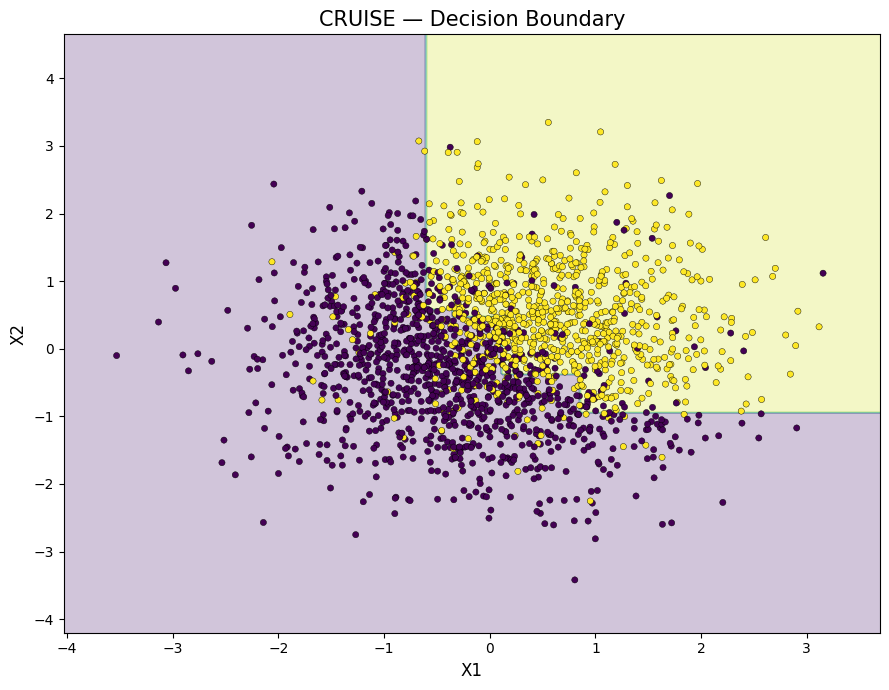

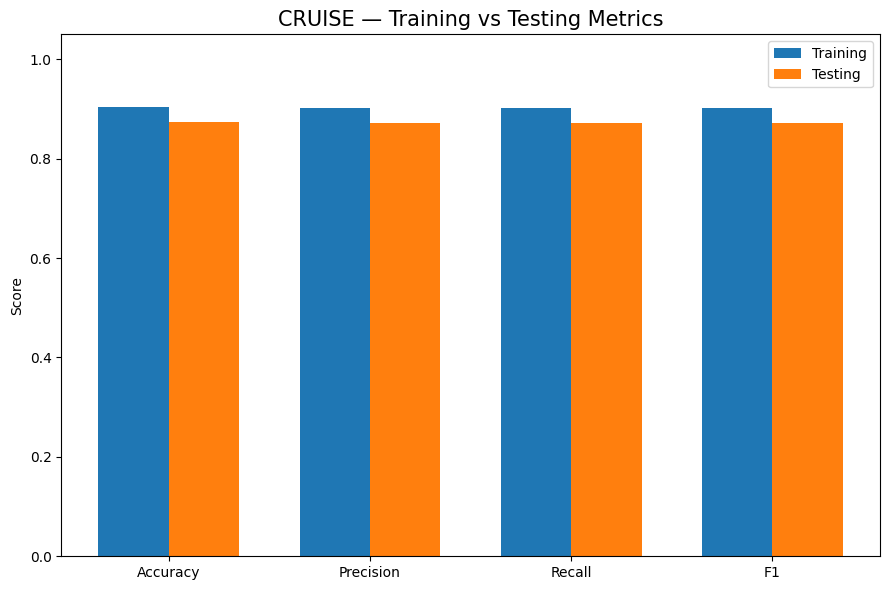

In [10]:
# ============================================================
# CRUISE CLASSIFIER — FROM SCRATCH
# ============================================================
#
# CRUISE
# Classification Rule with Unbiased Interaction Selection
# and Estimation
#
# FROM SCRATCH
#
# NO:
#   sklearn
#   scipy
#
# ONLY:
#   NumPy
#   Matplotlib
#
# ============================================================
#
# MAIN CRUISE IDEAS IMPLEMENTED:
#
#   1. Detect association between predictors and target
#   2. Use statistical tests for variable selection
#   3. Detect potential interactions
#   4. Select an unbiased primary splitting variable
#   5. Search for an optimal binary split
#   6. Recursively construct the tree
#   7. Stop using statistical significance and sample rules
#
# ============================================================
#
# EVALUATION:
#
#   Accuracy
#   Precision
#   Recall
#   F1 Score
#   Confusion Matrix
#   Feature Importance
#   Decision Boundary
#   Training vs Testing Metrics
#
# DATASET:
#
#   10,000 samples
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. GAMMA FUNCTION
# ============================================================

def gamma_function(z):

    coefficients = [

        676.5203681218851,

        -1259.1392167224028,

        771.32342877765313,

        -176.61502916214059,

        12.507343278686905,

        -0.13857109526572012,

        9.9843695780195716e-6,

        1.5056327351493116e-7
    ]


    if z < 0.5:

        return (

            np.pi

            /

            (

                np.sin(np.pi * z)

                *

                gamma_function(
                    1 - z
                )

            )

        )


    z -= 1


    x = 0.99999999999980993


    for i, coefficient in enumerate(
        coefficients
    ):

        x += (

            coefficient

            /

            (
                z + i + 1
            )

        )


    t = (

        z

        +

        len(coefficients)

        -

        0.5

    )


    return (

        np.sqrt(
            2 * np.pi
        )

        *

        t ** (
            z + 0.5
        )

        *

        np.exp(
            -t
        )

        *

        x

    )


# ============================================================
# 2. REGULARIZED UPPER GAMMA
# ============================================================

def regularized_gamma_q(
    a,
    x
):

    if x < 0 or a <= 0:

        return np.nan


    if x == 0:

        return 1.0


    # --------------------------------------------------------
    # Continued fraction
    # --------------------------------------------------------

    if x >= a + 1:

        max_iterations = 200

        epsilon = 1e-12

        tiny = 1e-300


        b = (

            x

            +

            1

            -

            a

        )


        c = 1 / tiny

        d = 1 / b

        h = d


        for i in range(
            1,
            max_iterations + 1
        ):

            an = (

                -i

                *

                (
                    i - a
                )

            )


            b += 2


            d = (

                an * d

                +

                b

            )


            if abs(d) < tiny:

                d = tiny


            c = (

                b

                +

                an / c

            )


            if abs(c) < tiny:

                c = tiny


            d = 1 / d


            delta = d * c

            h *= delta


            if abs(
                delta - 1
            ) < epsilon:

                break


        result = (

            np.exp(

                -x

                +

                a * np.log(x)

                -

                np.log(
                    gamma_function(a)
                )

            )

            *

            h

        )


        return np.clip(
            result,
            0.0,
            1.0
        )


    # --------------------------------------------------------
    # Series expansion
    # --------------------------------------------------------

    summation = 1.0 / a

    term = summation


    for n in range(
        1,
        200
    ):

        term *= (

            x

            /

            (
                a + n
            )

        )


        summation += term


        if abs(term) < (

            abs(summation)

            *

            1e-12

        ):

            break


    lower_gamma_ratio = (

        np.exp(

            -x

            +

            a * np.log(x)

            -

            np.log(
                gamma_function(a)
            )

        )

        *

        summation

    )


    return np.clip(

        1.0

        -

        lower_gamma_ratio,

        0.0,

        1.0

    )


# ============================================================
# 3. CHI-SQUARE P-VALUE
# ============================================================

def chi_square_p_value(
    chi_square,
    degrees_of_freedom
):

    if degrees_of_freedom <= 0:

        return 1.0


    if chi_square <= 0:

        return 1.0


    return regularized_gamma_q(

        degrees_of_freedom / 2.0,

        chi_square / 2.0

    )


# ============================================================
# 4. CRUISE TREE NODE
# ============================================================

class CRUISENode:

    def __init__(
        self,
        feature_index=None,
        threshold=None,
        prediction=None,
        class_counts=None,
        is_leaf=False,
        depth=0
    ):

        self.feature_index = (
            feature_index
        )

        self.threshold = (
            threshold
        )

        self.prediction = (
            prediction
        )

        self.class_counts = (
            class_counts
        )

        self.is_leaf = (
            is_leaf
        )

        self.depth = depth

        self.left = None

        self.right = None

        self.p_value = None

        self.test_statistic = None

        self.split_score = None

        self.interaction_score = None


# ============================================================
# 5. CRUISE CLASSIFIER
# ============================================================

class CRUISEClassifier:

    def __init__(
        self,
        max_depth=None,
        min_samples_split=30,
        min_samples_leaf=15,
        alpha=0.05,
        n_thresholds=50,
        interaction_threshold=0.10
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.alpha = alpha

        self.n_thresholds = (
            n_thresholds
        )

        self.interaction_threshold = (
            interaction_threshold
        )

        self.root = None

        self.classes_ = None

        self.n_classes_ = None

        self.n_features_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.interaction_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # MAJORITY CLASS
    # ========================================================

    def _majority_class(
        self,
        y
    ):

        values, counts = np.unique(
            y,
            return_counts=True
        )


        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # CANDIDATE THRESHOLDS
    # ========================================================

    def _candidate_thresholds(
        self,
        x
    ):

        values = np.unique(
            x
        )


        if len(values) <= 1:

            return np.array([])


        thresholds = (

            values[:-1]

            +

            values[1:]

        ) / 2.0


        if len(thresholds) <= (
            self.n_thresholds
        ):

            return thresholds


        indices = np.linspace(

            0,

            len(thresholds) - 1,

            self.n_thresholds

        ).astype(int)


        return thresholds[
            np.unique(indices)
        ]


    # ========================================================
    # CONTINGENCY TABLE
    # ========================================================

    def _contingency_table(
        self,
        x,
        y,
        threshold
    ):

        left = (
            x <= threshold
        )

        right = ~left


        table = np.zeros(

            (
                2,
                self.n_classes_
            ),

            dtype=float

        )


        for j, cls in enumerate(
            self.classes_
        ):

            table[
                0,
                j
            ] = np.sum(

                left

                &

                (
                    y == cls
                )

            )


            table[
                1,
                j
            ] = np.sum(

                right

                &

                (
                    y == cls
                )

            )


        return table


    # ========================================================
    # CHI-SQUARE TEST
    # ========================================================

    def _chi_square_test(
        self,
        x,
        y,
        threshold
    ):

        table = (
            self._contingency_table(

                x,

                y,

                threshold

            )
        )


        if (

            np.sum(table[0]) == 0

            or

            np.sum(table[1]) == 0

        ):

            return (

                0.0,

                1.0

            )


        row_totals = np.sum(

            table,

            axis=1,

            keepdims=True

        )


        column_totals = np.sum(

            table,

            axis=0,

            keepdims=True

        )


        total = np.sum(table)


        expected = (

            row_totals

            *

            column_totals

            /

            total

        )


        valid = (
            expected > 0
        )


        chi_square = np.sum(

            np.where(

                valid,

                (

                    (
                        table
                        -
                        expected
                    )
                    ** 2
                    /
                    expected

                ),

                0.0

            )

        )


        degrees_of_freedom = (

            (
                table.shape[0]
                -
                1
            )

            *

            (
                table.shape[1]
                -
                1
            )

        )


        p_value = chi_square_p_value(

            chi_square,

            degrees_of_freedom

        )


        return (

            chi_square,

            p_value

        )


    # ========================================================
    # FEATURE ASSOCIATION TEST
    # ========================================================
    #
    # CRUISE uses statistical information to avoid the
    # selection bias associated with simply searching every
    # possible split and taking the largest impurity decrease.
    #
    # ========================================================

    def _feature_association(
        self,
        x,
        y
    ):

        thresholds = (
            self._candidate_thresholds(
                x
            )
        )


        if len(thresholds) == 0:

            return (

                1.0,

                0.0,

                None

            )


        best_p = 1.0

        best_statistic = 0.0

        best_threshold = None


        for threshold in thresholds:

            left_count = np.sum(

                x <= threshold

            )


            right_count = np.sum(

                x > threshold

            )


            if (

                left_count
                <
                self.min_samples_leaf

                or

                right_count
                <
                self.min_samples_leaf

            ):

                continue


            statistic, p_value = (

                self._chi_square_test(

                    x,

                    y,

                    threshold

                )

            )


            if p_value < best_p:

                best_p = p_value

                best_statistic = statistic

                best_threshold = threshold


        return (

            best_p,

            best_statistic,

            best_threshold

        )


    # ========================================================
    # MULTIPLE TESTING CORRECTION
    # ========================================================

    def _adjust_p_value(
        self,
        p_value
    ):

        return min(

            p_value
            *
            self.n_features_,

            1.0

        )


    # ========================================================
    # INTERACTION SCORE
    # ========================================================
    #
    # CRUISE is particularly interested in interactions.
    #
    # Here we approximate interaction strength by comparing
    # the association of a feature with the target globally
    # against its association after conditioning on another
    # feature.
    #
    # ========================================================

    def _interaction_score(
        self,
        x1,
        x2,
        y
    ):

        if len(x1) < (
            self.min_samples_split
        ):

            return 0.0


        median_x2 = np.median(
            x2
        )


        group_a = (
            x2 <= median_x2
        )


        group_b = ~group_a


        if (

            np.sum(group_a)
            <
            self.min_samples_leaf

            or

            np.sum(group_b)
            <
            self.min_samples_leaf

        ):

            return 0.0


        p_values = []


        for mask in [
            group_a,
            group_b
        ]:

            x = x1[
                mask
            ]

            target = y[
                mask
            ]


            _, p, _ = (
                self._feature_association(
                    x,
                    target
                )
            )


            p_values.append(p)


        # ----------------------------------------------------
        # Difference in conditional evidence
        # ----------------------------------------------------

        difference = abs(

            np.log10(

                max(
                    p_values[0],
                    1e-12
                )

            )

            -

            np.log10(

                max(
                    p_values[1],
                    1e-12
                )

            )

        )


        return difference


    # ========================================================
    # SELECT PRIMARY VARIABLE
    # ========================================================

    def _select_variable(
        self,
        X,
        y
    ):

        feature_results = []


        # ----------------------------------------------------
        # Evaluate every predictor
        # ----------------------------------------------------

        for feature_index in range(

            self.n_features_

        ):

            x = X[
                :,
                feature_index
            ]


            (
                p_value,
                statistic,
                threshold

            ) = self._feature_association(

                x,

                y

            )


            adjusted_p = (

                self._adjust_p_value(

                    p_value

                )

            )


            feature_results.append(

                (
                    feature_index,

                    adjusted_p,

                    statistic,

                    threshold

                )

            )


        # ----------------------------------------------------
        # Select smallest p-value
        # ----------------------------------------------------

        valid_results = [

            r

            for r in feature_results

            if r[3] is not None

        ]


        if len(valid_results) == 0:

            return (

                None,

                None,

                1.0,

                0.0

            )


        best = min(

            valid_results,

            key=lambda r: r[1]

        )


        return (

            best[0],

            best[3],

            best[1],

            best[2]

        )


    # ========================================================
    # FIND BEST BINARY SPLIT
    # ========================================================

    def _find_best_split(
        self,
        x,
        y
    ):

        thresholds = (

            self._candidate_thresholds(

                x

            )

        )


        best_threshold = None

        best_score = -np.inf


        for threshold in thresholds:

            left_mask = (

                x <= threshold

            )


            right_mask = ~left_mask


            n_left = np.sum(
                left_mask
            )


            n_right = np.sum(
                right_mask
            )


            if (

                n_left
                <
                self.min_samples_leaf

                or

                n_right
                <
                self.min_samples_leaf

            ):

                continue


            # ------------------------------------------------
            # Target separation
            # ------------------------------------------------

            target_binary = (

                y
                ==
                self.classes_[1]

            ).astype(float)


            left_mean = np.mean(

                target_binary[
                    left_mask
                ]

            )


            right_mean = np.mean(

                target_binary[
                    right_mask
                ]

            )


            separation = abs(

                left_mean
                -
                right_mean

            )


            balance = np.sqrt(

                (
                    n_left
                    *
                    n_right
                )

                /

                len(y)

            )


            score = (

                separation
                *
                balance

            )


            if score > best_score:

                best_score = score

                best_threshold = threshold


        return (

            best_threshold,

            best_score

        )


    # ========================================================
    # BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        majority_class = (

            self._majority_class(
                y
            )

        )


        class_counts = {}


        for cls in self.classes_:

            class_counts[cls] = np.sum(

                y == cls

            )


        node = CRUISENode(

            prediction=majority_class,

            class_counts=class_counts,

            depth=depth

        )


        self.tree_depth_ = max(

            self.tree_depth_,

            depth

        )


        # ====================================================
        # STOP 1 — PURE NODE
        # ====================================================

        if len(
            np.unique(y)
        ) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP 2 — MAX DEPTH
        # ====================================================

        if (

            self.max_depth is not None

            and

            depth >= self.max_depth

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOP 3 — MINIMUM SAMPLES
        # ====================================================

        if (

            len(y)

            <

            self.min_samples_split

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # CRUISE VARIABLE SELECTION
        # ====================================================

        (

            feature_index,

            selected_threshold,

            p_value,

            statistic

        ) = self._select_variable(

            X,

            y

        )


        # ====================================================
        # STATISTICAL STOP
        # ====================================================

        if (

            feature_index is None

            or

            selected_threshold is None

            or

            p_value > self.alpha

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FIND OPTIMAL BINARY SPLIT
        # ====================================================

        threshold, split_score = (

            self._find_best_split(

                X[
                    :,
                    feature_index
                ],

                y

            )

        )


        if threshold is None:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE NODE INFORMATION
        # ====================================================

        node.feature_index = (
            feature_index
        )

        node.threshold = (
            threshold
        )

        node.p_value = (
            p_value
        )

        node.test_statistic = (
            statistic
        )

        node.split_score = (
            split_score
        )


        # ====================================================
        # INTERACTION ANALYSIS
        # ====================================================

        interaction_strength = 0.0


        for j in range(
            self.n_features_
        ):

            if j == feature_index:

                continue


            interaction = (

                self._interaction_score(

                    X[
                        :,
                        feature_index
                    ],

                    X[
                        :,
                        j
                    ],

                    y

                )

            )


            if interaction > interaction_strength:

                interaction_strength = (
                    interaction
                )


        node.interaction_score = (
            interaction_strength
        )


        # ====================================================
        # FEATURE IMPORTANCE
        # ====================================================

        statistical_strength = (

            -np.log10(

                max(
                    p_value,
                    1e-300
                )

            )

        )


        importance = (

            statistical_strength

            *

            split_score

            *

            len(y)

        )


        self.feature_importances_[

            feature_index

        ] += importance


        # ====================================================
        # SPLIT DATA
        # ====================================================

        left_mask = (

            X[
                :,
                feature_index
            ]

            <=

            threshold

        )


        right_mask = ~left_mask


        X_left = X[
            left_mask
        ]


        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]


        y_right = y[
            right_mask
        ]


        # ====================================================
        # SAFETY CHECK
        # ====================================================

        if (

            len(y_left)
            <
            self.min_samples_leaf

            or

            len(y_right)
            <
            self.min_samples_leaf

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # RECURSION
        # ====================================================

        node.left = self._build_tree(

            X_left,

            y_left,

            depth + 1

        )


        node.right = self._build_tree(

            X_right,

            y_right,

            depth + 1

        )


        return node


    # ========================================================
    # FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        y = np.asarray(y)


        if X.ndim != 2:

            raise ValueError(

                "X must be 2-dimensional."

            )


        if y.ndim != 1:

            raise ValueError(

                "y must be 1-dimensional."

            )


        if len(X) != len(y):

            raise ValueError(

                "X and y must have the same "
                "number of samples."

            )


        self.n_features_ = X.shape[1]


        self.classes_ = np.unique(
            y
        )


        self.n_classes_ = len(
            self.classes_
        )


        if self.n_classes_ != 2:

            raise ValueError(

                "This CRUISE implementation "
                "supports binary classification."

            )


        if feature_names is None:

            self.feature_names_ = [

                f"Feature_{i}"

                for i in range(
                    self.n_features_
                )

            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (

            np.zeros(
                self.n_features_
            )

        )


        self.interaction_importances_ = (

            np.zeros(
                (
                    self.n_features_,
                    self.n_features_
                )

            )

        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ====================================================
        # BUILD CRUISE TREE
        # ====================================================

        self.root = self._build_tree(

            X,

            y

        )


        # ====================================================
        # NORMALIZE FEATURE IMPORTANCE
        # ====================================================

        total = np.sum(

            self.feature_importances_

        )


        if total > 0:

            self.feature_importances_ /= total


        return self


    # ========================================================
    # PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        if (

            x[
                node.feature_index
            ]

            <=

            node.threshold

        ):

            return self._predict_sample(

                x,

                node.left

            )


        return self._predict_sample(

            x,

            node.right

        )


    # ========================================================
    # PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        predictions = []


        for x in X:

            predictions.append(

                self._predict_sample(

                    x,

                    self.root

                )

            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )


        return np.mean(

            predictions == y

        )


# ============================================================
# 6. MANUAL STRATIFIED TRAIN / TEST SPLIT
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )


    train_indices = []

    test_indices = []


    for cls in np.unique(y):

        indices = np.where(

            y == cls

        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(

            len(indices)

            *

            test_size

        )


        test_indices.extend(

            indices[
                :n_test
            ]

        )


        train_indices.extend(

            indices[
                n_test:
            ]

        )


    train_indices = np.asarray(
        train_indices
    )


    test_indices = np.asarray(
        test_indices
    )


    rng.shuffle(
        train_indices
    )


    rng.shuffle(
        test_indices
    )


    return (

        X[
            train_indices
        ],

        X[
            test_indices
        ],

        y[
            train_indices
        ],

        y[
            test_indices
        ]

    )


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(

        np.concatenate(

            [
                y_true,
                y_pred
            ]

        )

    )


    matrix = np.zeros(

        (
            len(labels),
            len(labels)
        ),

        dtype=int

    )


    label_to_index = {

        label: i

        for i, label in enumerate(
            labels
        )

    }


    for true, pred in zip(

        y_true,

        y_pred

    ):

        matrix[

            label_to_index[true],

            label_to_index[pred]

        ] += 1


    return (

        matrix,

        labels

    )


# ============================================================
# 8. CLASSIFICATION METRICS
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (

        confusion_matrix_manual(

            y_true,

            y_pred

        )

    )


    accuracy = (

        np.trace(cm)

        /

        np.sum(cm)

    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[
            i,
            i
        ]


        FP = (

            np.sum(
                cm[
                    :,
                    i
                ]
            )

            -

            TP

        )


        FN = (

            np.sum(
                cm[
                    i,
                    :
                ]
            )

            -

            TP

        )


        precision = (

            TP

            /

            (
                TP + FP
            )

            if

            (
                TP + FP
            ) > 0

            else

            0.0

        )


        recall = (

            TP

            /

            (
                TP + FN
            )

            if

            (
                TP + FN
            ) > 0

            else

            0.0

        )


        if (

            precision
            +
            recall
            >
            0

        ):

            f1 = (

                2

                *

                precision

                *

                recall

                /

                (

                    precision
                    +
                    recall

                )

            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )


        recalls.append(
            recall
        )


        f1_scores.append(
            f1
        )


    return {

        "accuracy":
            accuracy,

        "precision":
            np.mean(
                precisions
            ),

        "recall":
            np.mean(
                recalls
            ),

        "f1":
            np.mean(
                f1_scores
            ),

        "labels":
            labels,

        "confusion_matrix":
            cm,

        "per_class_precision":
            precisions,

        "per_class_recall":
            recalls,

        "per_class_f1":
            f1_scores

    }


# ============================================================
# 9. CREATE LARGE DATASET
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Four continuous predictors
# ------------------------------------------------------------

X = rng.normal(

    0,

    1,

    size=(

        n_samples,

        4

    )

)


x1 = X[:, 0]

x2 = X[:, 1]

x3 = X[:, 2]

x4 = X[:, 3]


# ============================================================
# TRUE DATA GENERATING PROCESS
# ============================================================
#
# Contains:
#
#   Main effects
#   Interaction effect
#   Non-linear component
#
# This makes the dataset useful for demonstrating the
# motivation behind CRUISE.
#
# ============================================================

score = (

    1.8 * x1

    +

    1.4 * x2

    +

    1.2 * x1 * x2

    +

    0.7 * np.sin(x3)

    -

    0.5 * x4

)


y = (

    score > 0

).astype(int)


# ============================================================
# ADD CLASSIFICATION NOISE
# ============================================================

noise = (

    rng.random(
        n_samples
    )

    <

    0.05

)


y[noise] = (

    1

    -

    y[noise]

)


feature_names = [

    "X1",

    "X2",

    "X3",

    "X4"

]


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42

)


# ============================================================
# 11. CREATE CRUISE MODEL
# ============================================================

model = CRUISEClassifier(

    max_depth=6,

    min_samples_split=30,

    min_samples_leaf=15,

    alpha=0.05,

    n_thresholds=50,

    interaction_threshold=0.10

)


# ============================================================
# 12. TRAIN
# ============================================================

model.fit(

    X_train,

    y_train,

    feature_names=feature_names

)


# ============================================================
# 13. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 14. EVALUATION
# ============================================================

train_metrics = classification_metrics(

    y_train,

    y_train_pred

)


test_metrics = classification_metrics(

    y_test,

    y_test_pred

)


# ============================================================
# 15. MODEL INFORMATION
# ============================================================

print("=" * 70)

print(
    "CRUISE CLASSIFIER — FROM SCRATCH"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Number classes   : {model.n_classes_}"
)


print(
    f"Tree depth       : {model.tree_depth_}"
)


print(
    f"Number of leaves : {model.n_leaves_}"
)


# ============================================================
# 16. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{train_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{train_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"
)


# ============================================================
# 17. TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(
    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"
)


print(
    f"Precision : "
    f"{test_metrics['precision']:.4f}"
)


print(
    f"Recall    : "
    f"{test_metrics['recall']:.4f}"
)


print(
    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"
)


# ============================================================
# 18. PER-CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(

    test_metrics["labels"]

):

    print(

        f"Class {label}: "

        f"Precision = "

        f"{test_metrics['per_class_precision'][i]:.4f}, "

        f"Recall = "

        f"{test_metrics['per_class_recall'][i]:.4f}, "

        f"F1 = "

        f"{test_metrics['per_class_f1'][i]:.4f}"

    )


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]


labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 20. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(

    figsize=(7, 6)

)


plt.imshow(

    cm,

    interpolation="nearest"

)


plt.title(

    "CRUISE — Test Confusion Matrix",

    fontsize=15

)


plt.xlabel(

    "Predicted Class",

    fontsize=12

)


plt.ylabel(

    "True Class",

    fontsize=12

)


plt.xticks(

    range(
        len(labels)
    ),

    labels

)


plt.yticks(

    range(
        len(labels)
    ),

    labels

)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(

            j,

            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center",

            fontsize=15

        )


plt.colorbar()


plt.tight_layout()

plt.show()


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.bar(

    model.feature_names_,

    model.feature_importances_

)


plt.title(

    "CRUISE — Statistical Feature Importance",

    fontsize=15

)


plt.xlabel(

    "Features"

)


plt.ylabel(

    "Importance"

)


plt.tight_layout()

plt.show()


# ============================================================
# 22. DECISION BOUNDARY
# ============================================================
#
# Plot X1 vs X2.
#
# X3 and X4 are fixed at their median values.
#
# ============================================================

x_min = (

    X[:, 0].min()

    -

    0.5

)


x_max = (

    X[:, 0].max()

    +

    0.5

)


y_min = (

    X[:, 1].min()

    -

    0.5

)


y_max = (

    X[:, 1].max()

    +

    0.5

)


resolution = 250


xx, yy = np.meshgrid(

    np.linspace(

        x_min,

        x_max,

        resolution

    ),

    np.linspace(

        y_min,

        y_max,

        resolution

    )

)


grid = np.zeros(

    (
        xx.size,

        4

    )

)


grid[:, 0] = xx.ravel()

grid[:, 1] = yy.ravel()

grid[:, 2] = np.median(
    X[:, 2]
)

grid[:, 3] = np.median(
    X[:, 3]
)


grid_predictions = model.predict(
    grid
)


grid_predictions = (

    grid_predictions.reshape(
        xx.shape
    )

)


plt.figure(

    figsize=(9, 7)

)


plt.contourf(

    xx,

    yy,

    grid_predictions,

    alpha=0.25

)


plt.scatter(

    X_test[:, 0],

    X_test[:, 1],

    c=y_test,

    s=20,

    edgecolors="black",

    linewidths=0.3

)


plt.title(

    "CRUISE — Decision Boundary",

    fontsize=15

)


plt.xlabel(

    "X1",

    fontsize=12

)


plt.ylabel(

    "X2",

    fontsize=12

)


plt.tight_layout()

plt.show()


# ============================================================
# 23. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"

]


train_values = [

    train_metrics[
        "accuracy"
    ],

    train_metrics[
        "precision"
    ],

    train_metrics[
        "recall"
    ],

    train_metrics[
        "f1"
    ]

]


test_values = [

    test_metrics[
        "accuracy"
    ],

    test_metrics[
        "precision"
    ],

    test_metrics[
        "recall"
    ],

    test_metrics[
        "f1"
    ]

]


x = np.arange(

    len(
        metric_names
    )

)


width = 0.35


plt.figure(

    figsize=(9, 6)

)


plt.bar(

    x - width / 2,

    train_values,

    width,

    label="Training"

)


plt.bar(

    x + width / 2,

    test_values,

    width,

    label="Testing"

)


plt.xticks(

    x,

    metric_names

)


plt.ylim(

    0,

    1.05

)


plt.ylabel(

    "Score"

)


plt.title(

    "CRUISE — Training vs Testing Metrics",

    fontsize=15

)


plt.legend()


plt.tight_layout()

plt.show()

OBLIQUE DECISION TREE CLASSIFIER
Total samples    : 10,000
Training samples : 8,000
Testing samples  : 2,000
Number features  : 4
Number classes   : 2
Maximum depth    : 6
Actual depth     : 6
Number of leaves : 49
Projections/node : 150

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9354
Precision : 0.9354
Recall    : 0.9341
F1 Score  : 0.9347

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
Accuracy  : 0.9380
Precision : 0.9374
Recall    : 0.9375
F1 Score  : 0.9374

----------------------------------------------------------------------
PER-CLASS TEST METRICS
----------------------------------------------------------------------
Class 0: Precision = 0.9442, Recall = 0.9425, F1 = 0.9434
Class 1: Precision = 0.9305, Recall = 0.9325, F1 = 0.9315

---

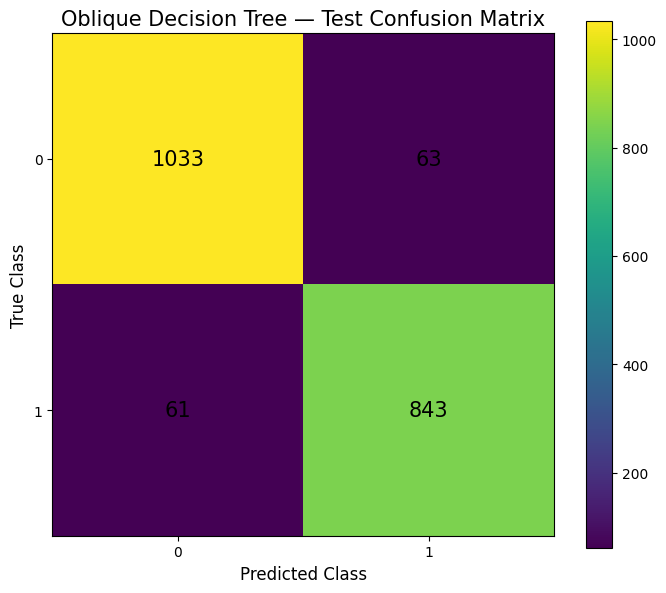

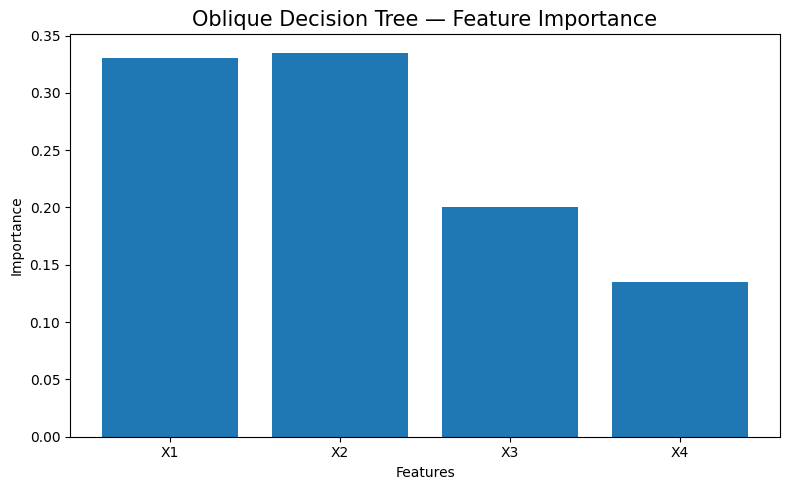

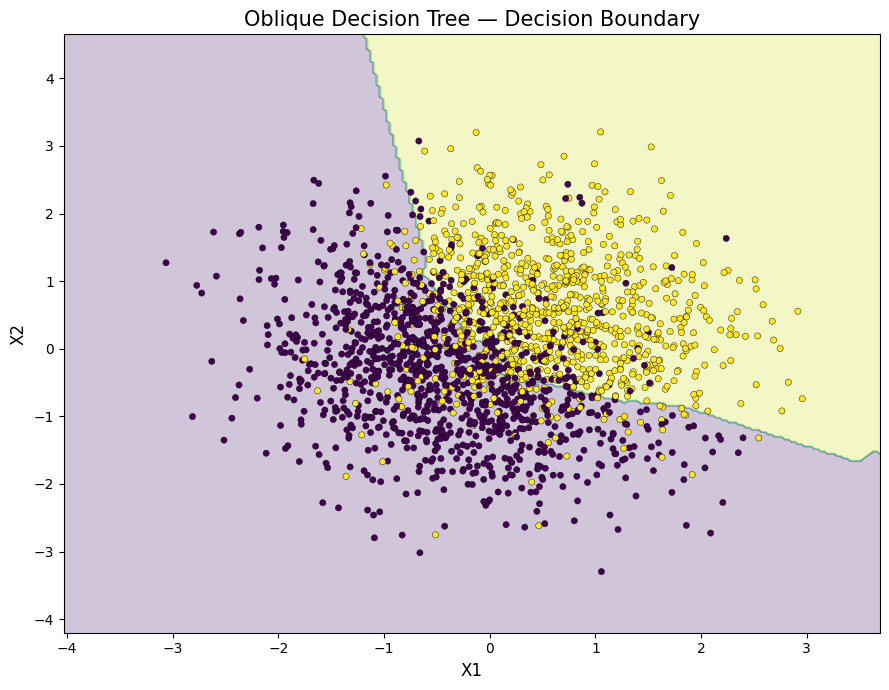

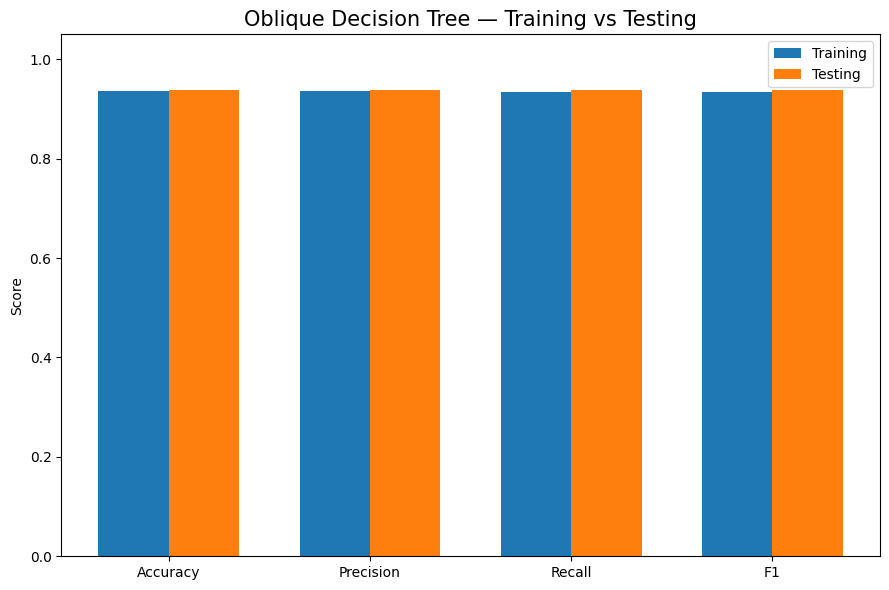

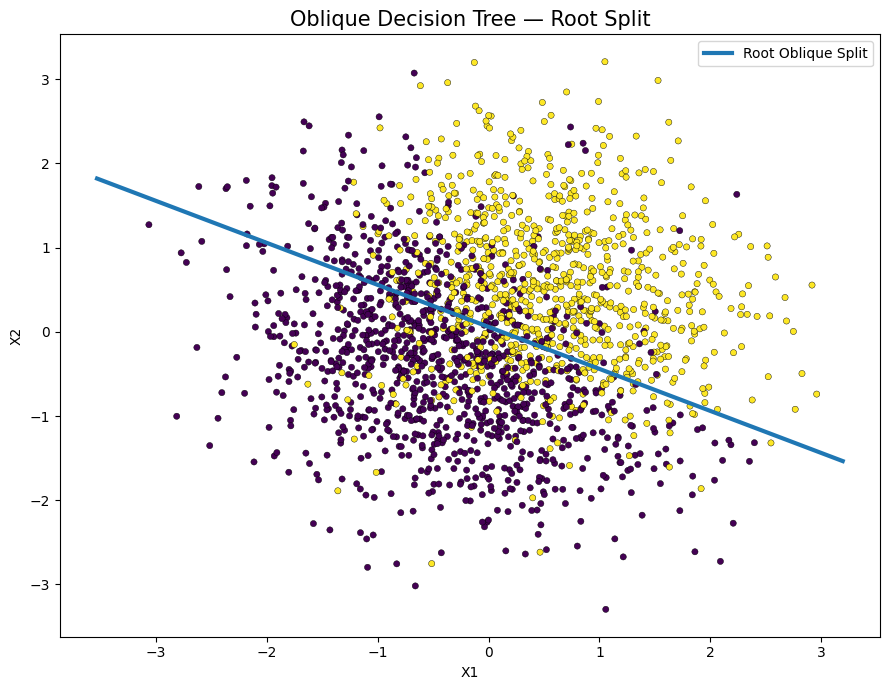


----------------------------------------------------------------------
ROOT OBLIQUE SPLIT
----------------------------------------------------------------------
-0.3738 * X1 + -0.7489 * X2 + -0.4580 * X3 + 0.2995 * X4 <= -0.0378


In [11]:
# ============================================================
# OBLIQUE DECISION TREE CLASSIFIER — FROM SCRATCH
# ============================================================
#
# Oblique Decision Tree
#
# FROM SCRATCH
#
# NO:
#   sklearn
#   scipy
#
# ONLY:
#   NumPy
#   Matplotlib
#
# ============================================================
#
# MAIN IDEA:
#
# Standard Decision Tree:
#
#       x_j <= threshold
#
# Oblique Decision Tree:
#
#       w1*x1 + w2*x2 + ... + wd*xd <= threshold
#
# Therefore, the tree can create diagonal / rotated
# decision boundaries.
#
# ============================================================
#
# IMPLEMENTED:
#
#   1. Oblique linear projections
#   2. Random projection generation
#   3. Gini impurity
#   4. Best projection selection
#   5. Best threshold selection
#   6. Recursive tree construction
#   7. Stopping criteria
#   8. Prediction
#   9. Feature importance
#
# ============================================================
#
# EVALUATION:
#
#   Accuracy
#   Precision
#   Recall
#   F1 Score
#   Confusion Matrix
#   Feature Importance
#   Decision Boundary
#   Training vs Testing Metrics
#
# ============================================================
#
# DATASET:
#
#   10,000 samples
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class ObliqueTreeNode:

    def __init__(
        self,
        weights=None,
        threshold=None,
        prediction=None,
        class_counts=None,
        is_leaf=False,
        depth=0
    ):

        self.weights = weights

        self.threshold = threshold

        self.prediction = prediction

        self.class_counts = class_counts

        self.is_leaf = is_leaf

        self.depth = depth

        self.left = None

        self.right = None

        self.impurity = None

        self.impurity_decrease = None

        self.n_samples = None


# ============================================================
# 2. OBLIQUE DECISION TREE CLASSIFIER
# ============================================================

class ObliqueDecisionTreeClassifier:

    def __init__(
        self,
        max_depth=6,
        min_samples_split=30,
        min_samples_leaf=15,
        n_projections=100,
        n_thresholds=30,
        criterion="gini",
        random_state=42
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.n_projections = (
            n_projections
        )

        self.n_thresholds = (
            n_thresholds
        )

        self.criterion = criterion

        self.random_state = random_state

        self.rng = np.random.default_rng(
            random_state
        )

        self.root = None

        self.classes_ = None

        self.n_classes_ = None

        self.n_features_ = None

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # 3. GINI IMPURITY
    # ========================================================

    def _gini(self, y):

        if len(y) == 0:

            return 0.0


        _, counts = np.unique(

            y,

            return_counts=True

        )


        probabilities = (

            counts / len(y)

        )


        return 1.0 - np.sum(

            probabilities ** 2

        )


    # ========================================================
    # 4. ENTROPY
    # ========================================================

    def _entropy(self, y):

        if len(y) == 0:

            return 0.0


        _, counts = np.unique(

            y,

            return_counts=True

        )


        probabilities = (

            counts / len(y)

        )


        probabilities = probabilities[
            probabilities > 0
        ]


        return -np.sum(

            probabilities

            *

            np.log2(
                probabilities
            )

        )


    # ========================================================
    # 5. IMPURITY
    # ========================================================

    def _impurity(self, y):

        if self.criterion == "gini":

            return self._gini(y)


        elif self.criterion == "entropy":

            return self._entropy(y)


        else:

            raise ValueError(

                "criterion must be "
                "'gini' or 'entropy'"

            )


    # ========================================================
    # 6. MAJORITY CLASS
    # ========================================================

    def _majority_class(self, y):

        values, counts = np.unique(

            y,

            return_counts=True

        )


        return values[
            np.argmax(counts)
        ]


    # ========================================================
    # 7. CLASS COUNTS
    # ========================================================

    def _class_counts(self, y):

        counts = {}


        for cls in self.classes_:

            counts[cls] = np.sum(

                y == cls

            )


        return counts


    # ========================================================
    # 8. GENERATE RANDOM OBLIQUE PROJECTIONS
    # ========================================================
    #
    # Each projection represents:
    #
    #       z = w1*x1 + w2*x2 + ... + wd*xd
    #
    # The tree searches for the projection that produces
    # the strongest class separation.
    #
    # ========================================================

    def _generate_projections(self):

        projections = []


        # ----------------------------------------------------
        # Random dense projections
        # ----------------------------------------------------

        for _ in range(

            self.n_projections

        ):

            weights = self.rng.normal(

                0,

                1,

                self.n_features_

            )


            norm = np.linalg.norm(
                weights
            )


            if norm == 0:

                continue


            weights = (
                weights / norm
            )


            projections.append(
                weights
            )


        # ----------------------------------------------------
        # Single-feature projections
        #
        # This also allows the oblique tree to fall back to
        # ordinary axis-aligned splits.
        # ----------------------------------------------------

        for j in range(

            self.n_features_

        ):

            weights = np.zeros(

                self.n_features_

            )


            weights[j] = 1.0


            projections.append(
                weights
            )


        return projections


    # ========================================================
    # 9. CANDIDATE THRESHOLDS
    # ========================================================

    def _candidate_thresholds(
        self,
        projected_values
    ):

        values = np.unique(

            projected_values

        )


        if len(values) <= 1:

            return np.array([])


        thresholds = (

            values[:-1]

            +

            values[1:]

        ) / 2.0


        if len(thresholds) <= (

            self.n_thresholds

        ):

            return thresholds


        indices = np.linspace(

            0,

            len(thresholds) - 1,

            self.n_thresholds

        ).astype(int)


        indices = np.unique(
            indices
        )


        return thresholds[
            indices
        ]


    # ========================================================
    # 10. WEIGHTED CHILD IMPURITY
    # ========================================================

    def _weighted_impurity(
        self,
        y_left,
        y_right
    ):

        n = len(
            y_left
        ) + len(
            y_right
        )


        if n == 0:

            return 0.0


        left_weight = (

            len(y_left)

            /

            n

        )


        right_weight = (

            len(y_right)

            /

            n

        )


        return (

            left_weight

            *

            self._impurity(
                y_left
            )

            +

            right_weight

            *

            self._impurity(
                y_right
            )

        )


    # ========================================================
    # 11. FIND BEST OBLIQUE SPLIT
    # ========================================================
    #
    # Search:
    #
    #       projection
    #
    # and
    #
    #       threshold
    #
    # simultaneously.
    #
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        parent_impurity = (

            self._impurity(y)

        )


        projections = (

            self._generate_projections()

        )


        best_gain = -np.inf

        best_weights = None

        best_threshold = None


        # ====================================================
        # SEARCH OVER PROJECTIONS
        # ====================================================

        for weights in projections:

            projected = (

                X @ weights

            )


            thresholds = (

                self._candidate_thresholds(

                    projected

                )

            )


            # ------------------------------------------------
            # Search thresholds
            # ------------------------------------------------

            for threshold in thresholds:

                left_mask = (

                    projected

                    <=

                    threshold

                )


                right_mask = ~left_mask


                n_left = np.sum(
                    left_mask
                )


                n_right = np.sum(
                    right_mask
                )


                # ------------------------------------------------
                # Minimum leaf constraint
                # ------------------------------------------------

                if (

                    n_left
                    <
                    self.min_samples_leaf

                    or

                    n_right
                    <
                    self.min_samples_leaf

                ):

                    continue


                y_left = y[
                    left_mask
                ]


                y_right = y[
                    right_mask
                ]


                child_impurity = (

                    self._weighted_impurity(

                        y_left,

                        y_right

                    )

                )


                gain = (

                    parent_impurity

                    -

                    child_impurity

                )


                if gain > best_gain:

                    best_gain = gain

                    best_weights = (
                        weights.copy()
                    )

                    best_threshold = (
                        threshold
                    )


        return (

            best_weights,

            best_threshold,

            best_gain

        )


    # ========================================================
    # 12. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        prediction = (

            self._majority_class(y)

        )


        node = ObliqueTreeNode(

            prediction=prediction,

            class_counts=self._class_counts(y),

            is_leaf=False,

            depth=depth

        )


        node.n_samples = len(y)


        node.impurity = (

            self._impurity(y)

        )


        self.tree_depth_ = max(

            self.tree_depth_,

            depth

        )


        # ====================================================
        # STOPPING CONDITION 1:
        # PURE NODE
        # ====================================================

        if len(
            np.unique(y)
        ) == 1:

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 2:
        # MAX DEPTH
        # ====================================================

        if (

            depth >= self.max_depth

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 3:
        # MINIMUM SAMPLES
        # ====================================================

        if (

            len(y)

            <

            self.min_samples_split

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FIND BEST OBLIQUE SPLIT
        # ====================================================

        (

            weights,

            threshold,

            gain

        ) = self._find_best_split(

            X,

            y

        )


        # ====================================================
        # STOPPING CONDITION 4:
        # NO USEFUL SPLIT
        # ====================================================

        if (

            weights is None

            or

            threshold is None

            or

            gain <= 1e-12

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE SPLIT
        # ====================================================

        node.weights = (
            weights
        )

        node.threshold = (
            threshold
        )

        node.impurity_decrease = (
            gain
        )


        # ====================================================
        # PROJECT DATA
        # ====================================================

        projected = (

            X @ weights

        )


        left_mask = (

            projected

            <=

            threshold

        )


        right_mask = ~left_mask


        X_left = X[
            left_mask
        ]


        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]


        y_right = y[
            right_mask
        ]


        # ====================================================
        # SAFETY CHECK
        # ====================================================

        if (

            len(y_left)
            <
            self.min_samples_leaf

            or

            len(y_right)
            <
            self.min_samples_leaf

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FEATURE IMPORTANCE
        # ====================================================
        #
        # Since an oblique split uses multiple features,
        # distribute the split gain according to the magnitude
        # of each coefficient.
        #
        # ====================================================

        absolute_weights = np.abs(
            weights
        )


        weight_sum = np.sum(
            absolute_weights
        )


        if weight_sum > 0:

            normalized_weights = (

                absolute_weights

                /

                weight_sum

            )


            self.feature_importances_ += (

                gain

                *

                len(y)

                *

                normalized_weights

            )


        # ====================================================
        # RECURSIVE LEFT SUBTREE
        # ====================================================

        node.left = self._build_tree(

            X_left,

            y_left,

            depth + 1

        )


        # ====================================================
        # RECURSIVE RIGHT SUBTREE
        # ====================================================

        node.right = self._build_tree(

            X_right,

            y_right,

            depth + 1

        )


        return node


    # ========================================================
    # 13. FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        y = np.asarray(y)


        # ====================================================
        # VALIDATION
        # ====================================================

        if X.ndim != 2:

            raise ValueError(

                "X must be a 2-dimensional array."

            )


        if y.ndim != 1:

            raise ValueError(

                "y must be a 1-dimensional array."

            )


        if len(X) != len(y):

            raise ValueError(

                "X and y must contain "
                "the same number of samples."

            )


        # ====================================================
        # STORE DATA INFORMATION
        # ====================================================

        self.n_features_ = X.shape[1]


        self.classes_ = np.unique(
            y
        )


        self.n_classes_ = len(
            self.classes_
        )


        if self.n_classes_ != 2:

            raise ValueError(

                "This implementation supports "
                "binary classification."

            )


        if feature_names is None:

            self.feature_names_ = [

                f"Feature_{i}"

                for i in range(
                    self.n_features_
                )

            ]

        else:

            self.feature_names_ = list(
                feature_names
            )


        self.feature_importances_ = (

            np.zeros(

                self.n_features_

            )

        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ====================================================
        # BUILD TREE
        # ====================================================

        self.root = self._build_tree(

            X,

            y,

            depth=0

        )


        # ====================================================
        # NORMALIZE FEATURE IMPORTANCE
        # ====================================================

        total_importance = np.sum(

            self.feature_importances_

        )


        if total_importance > 0:

            self.feature_importances_ /= (

                total_importance

            )


        return self


    # ========================================================
    # 14. PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction


        projection = (

            np.dot(

                x,

                node.weights

            )

        )


        if (

            projection

            <=

            node.threshold

        ):

            return self._predict_sample(

                x,

                node.left

            )


        return self._predict_sample(

            x,

            node.right

        )


    # ========================================================
    # 15. PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        predictions = []


        for x in X:

            predictions.append(

                self._predict_sample(

                    x,

                    self.root

                )

            )


        return np.asarray(
            predictions
        )


    # ========================================================
    # 16. SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(
            X
        )


        return np.mean(

            predictions == y

        )


# ============================================================
# 17. MANUAL TRAIN / TEST SPLIT
# ============================================================

def train_test_split_manual(
    X,
    y,
    test_size=0.20,
    random_state=42
):

    rng = np.random.default_rng(

        random_state

    )


    train_indices = []

    test_indices = []


    # --------------------------------------------------------
    # Stratified splitting
    # --------------------------------------------------------

    for cls in np.unique(y):

        indices = np.where(

            y == cls

        )[0]


        rng.shuffle(
            indices
        )


        n_test = int(

            len(indices)

            *

            test_size

        )


        test_indices.extend(

            indices[
                :n_test
            ]

        )


        train_indices.extend(

            indices[
                n_test:
            ]

        )


    train_indices = np.asarray(

        train_indices

    )


    test_indices = np.asarray(

        test_indices

    )


    rng.shuffle(
        train_indices
    )


    rng.shuffle(
        test_indices
    )


    return (

        X[
            train_indices
        ],

        X[
            test_indices
        ],

        y[
            train_indices
        ],

        y[
            test_indices
        ]

    )


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

def confusion_matrix_manual(
    y_true,
    y_pred
):

    labels = np.unique(

        np.concatenate(

            [
                y_true,
                y_pred
            ]

        )

    )


    matrix = np.zeros(

        (
            len(labels),
            len(labels)
        ),

        dtype=int

    )


    label_to_index = {

        label: i

        for i, label in enumerate(
            labels
        )

    }


    for true, pred in zip(

        y_true,

        y_pred

    ):

        matrix[

            label_to_index[true],

            label_to_index[pred]

        ] += 1


    return (

        matrix,

        labels

    )


# ============================================================
# 19. CLASSIFICATION METRICS
# ============================================================

def classification_metrics(
    y_true,
    y_pred
):

    cm, labels = (

        confusion_matrix_manual(

            y_true,

            y_pred

        )

    )


    accuracy = (

        np.trace(cm)

        /

        np.sum(cm)

    )


    precisions = []

    recalls = []

    f1_scores = []


    for i in range(
        len(labels)
    ):

        TP = cm[
            i,
            i
        ]


        FP = (

            np.sum(
                cm[
                    :,
                    i
                ]
            )

            -

            TP

        )


        FN = (

            np.sum(
                cm[
                    i,
                    :
                ]
            )

            -

            TP

        )


        precision = (

            TP

            /

            (

                TP + FP

            )

            if (

                TP + FP

            ) > 0

            else

            0.0

        )


        recall = (

            TP

            /

            (

                TP + FN

            )

            if (

                TP + FN

            ) > 0

            else

            0.0

        )


        if (

            precision
            +
            recall

        ) > 0:

            f1 = (

                2

                *

                precision

                *

                recall

                /

                (

                    precision
                    +
                    recall

                )

            )

        else:

            f1 = 0.0


        precisions.append(
            precision
        )


        recalls.append(
            recall
        )


        f1_scores.append(
            f1
        )


    return {

        "accuracy":
            accuracy,

        "precision":
            np.mean(
                precisions
            ),

        "recall":
            np.mean(
                recalls
            ),

        "f1":
            np.mean(
                f1_scores
            ),

        "labels":
            labels,

        "confusion_matrix":
            cm,

        "per_class_precision":
            precisions,

        "per_class_recall":
            recalls,

        "per_class_f1":
            f1_scores

    }


# ============================================================
# 20. CREATE LARGE SYNTHETIC DATASET
# ============================================================
#
# IMPORTANT:
#
# This dataset deliberately contains diagonal boundaries.
#
# A standard axis-aligned tree needs many rectangular splits
# to approximate this structure.
#
# An oblique tree can model the diagonal structure directly.
#
# ============================================================

rng = np.random.default_rng(
    42
)


n_samples = 10_000


# ------------------------------------------------------------
# Generate features
# ------------------------------------------------------------

X = rng.normal(

    0,

    1,

    size=(

        n_samples,

        4

    )

)


x1 = X[:, 0]

x2 = X[:, 1]

x3 = X[:, 2]

x4 = X[:, 3]


# ============================================================
# DIAGONAL / OBLIQUE DATA GENERATING PROCESS
# ============================================================
#
# Target depends heavily on combinations of features:
#
#       1.5 X1 + 1.2 X2
#
#       - 1.0 X2 + 1.3 X3
#
# This creates non-axis-aligned structures.
#
# ============================================================

score = (

    1.7 * x1

    +

    1.5 * x2

    +

    0.8 * x3

    -

    0.6 * x4

)


# ------------------------------------------------------------
# Non-linear interaction
# ------------------------------------------------------------

score += (

    0.9

    *

    x1

    *

    x2

)


# ------------------------------------------------------------
# Classification
# ------------------------------------------------------------

y = (

    score > 0

).astype(int)


# ------------------------------------------------------------
# Add 5% label noise
# ------------------------------------------------------------

noise = (

    rng.random(
        n_samples
    )

    <

    0.05

)


y[noise] = (

    1

    -

    y[noise]

)


feature_names = [

    "X1",

    "X2",

    "X3",

    "X4"

]


# ============================================================
# 21. TRAIN / TEST SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42

)


# ============================================================
# 22. CREATE MODEL
# ============================================================

model = ObliqueDecisionTreeClassifier(

    max_depth=6,

    min_samples_split=30,

    min_samples_leaf=15,

    n_projections=150,

    n_thresholds=30,

    criterion="gini",

    random_state=42

)


# ============================================================
# 23. TRAIN
# ============================================================

model.fit(

    X_train,

    y_train,

    feature_names=feature_names

)


# ============================================================
# 24. PREDICTIONS
# ============================================================

y_train_pred = model.predict(
    X_train
)


y_test_pred = model.predict(
    X_test
)


# ============================================================
# 25. EVALUATION
# ============================================================

train_metrics = classification_metrics(

    y_train,

    y_train_pred

)


test_metrics = classification_metrics(

    y_test,

    y_test_pred

)


# ============================================================
# 26. MODEL INFORMATION
# ============================================================

print("=" * 70)

print(
    "OBLIQUE DECISION TREE CLASSIFIER"
)

print("=" * 70)


print(
    f"Total samples    : {n_samples:,}"
)


print(
    f"Training samples : {len(X_train):,}"
)


print(
    f"Testing samples  : {len(X_test):,}"
)


print(
    f"Number features  : {model.n_features_}"
)


print(
    f"Number classes   : {model.n_classes_}"
)


print(
    f"Maximum depth    : {model.max_depth}"
)


print(
    f"Actual depth     : {model.tree_depth_}"
)


print(
    f"Number of leaves : {model.n_leaves_}"
)


print(
    f"Projections/node : {model.n_projections}"
)


# ============================================================
# 27. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(

    f"Accuracy  : "
    f"{train_metrics['accuracy']:.4f}"

)


print(

    f"Precision : "
    f"{train_metrics['precision']:.4f}"

)


print(

    f"Recall    : "
    f"{train_metrics['recall']:.4f}"

)


print(

    f"F1 Score  : "
    f"{train_metrics['f1']:.4f}"

)


# ============================================================
# 28. TEST PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(

    f"Accuracy  : "
    f"{test_metrics['accuracy']:.4f}"

)


print(

    f"Precision : "
    f"{test_metrics['precision']:.4f}"

)


print(

    f"Recall    : "
    f"{test_metrics['recall']:.4f}"

)


print(

    f"F1 Score  : "
    f"{test_metrics['f1']:.4f}"

)


# ============================================================
# 29. PER-CLASS METRICS
# ============================================================

print()

print("-" * 70)

print(
    "PER-CLASS TEST METRICS"
)

print("-" * 70)


for i, label in enumerate(

    test_metrics["labels"]

):

    print(

        f"Class {label}: "

        f"Precision = "

        f"{test_metrics['per_class_precision'][i]:.4f}, "

        f"Recall = "

        f"{test_metrics['per_class_recall'][i]:.4f}, "

        f"F1 = "

        f"{test_metrics['per_class_f1'][i]:.4f}"

    )


# ============================================================
# 30. CONFUSION MATRIX
# ============================================================

cm = test_metrics[
    "confusion_matrix"
]


labels = test_metrics[
    "labels"
]


print()

print("-" * 70)

print(
    "TEST CONFUSION MATRIX"
)

print("-" * 70)


print(cm)


# ============================================================
# 31. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(

    figsize=(7, 6)

)


plt.imshow(

    cm,

    interpolation="nearest"

)


plt.title(

    "Oblique Decision Tree — Test Confusion Matrix",

    fontsize=15

)


plt.xlabel(

    "Predicted Class",

    fontsize=12

)


plt.ylabel(

    "True Class",

    fontsize=12

)


plt.xticks(

    range(
        len(labels)
    ),

    labels

)


plt.yticks(

    range(
        len(labels)
    ),

    labels

)


for i in range(
    len(labels)
):

    for j in range(
        len(labels)
    ):

        plt.text(

            j,

            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center",

            fontsize=15

        )


plt.colorbar()


plt.tight_layout()

plt.show()


# ============================================================
# 32. FEATURE IMPORTANCE
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.bar(

    model.feature_names_,

    model.feature_importances_

)


plt.title(

    "Oblique Decision Tree — Feature Importance",

    fontsize=15

)


plt.xlabel(

    "Features"

)


plt.ylabel(

    "Importance"

)


plt.tight_layout()

plt.show()


# ============================================================
# 33. DECISION BOUNDARY
# ============================================================
#
# Visualize X1 vs X2.
#
# X3 and X4 are fixed at their median values.
#
# ============================================================

x1_min = (

    X[:, 0].min()

    -

    0.5

)


x1_max = (

    X[:, 0].max()

    +

    0.5

)


x2_min = (

    X[:, 1].min()

    -

    0.5

)


x2_max = (

    X[:, 1].max()

    +

    0.5

)


resolution = 250


xx, yy = np.meshgrid(

    np.linspace(

        x1_min,

        x1_max,

        resolution

    ),

    np.linspace(

        x2_min,

        x2_max,

        resolution

    )

)


grid = np.zeros(

    (
        xx.size,

        4

    )

)


grid[:, 0] = xx.ravel()

grid[:, 1] = yy.ravel()


grid[:, 2] = np.median(

    X[:, 2]

)


grid[:, 3] = np.median(

    X[:, 3]

)


grid_predictions = model.predict(

    grid

)


grid_predictions = (

    grid_predictions.reshape(

        xx.shape

    )

)


plt.figure(

    figsize=(9, 7)

)


plt.contourf(

    xx,

    yy,

    grid_predictions,

    alpha=0.25

)


plt.scatter(

    X_test[:, 0],

    X_test[:, 1],

    c=y_test,

    s=20,

    edgecolors="black",

    linewidths=0.3

)


plt.title(

    "Oblique Decision Tree — Decision Boundary",

    fontsize=15

)


plt.xlabel(

    "X1",

    fontsize=12

)


plt.ylabel(

    "X2",

    fontsize=12

)


plt.tight_layout()

plt.show()


# ============================================================
# 34. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1"

]


train_values = [

    train_metrics[
        "accuracy"
    ],

    train_metrics[
        "precision"
    ],

    train_metrics[
        "recall"
    ],

    train_metrics[
        "f1"
    ]

]


test_values = [

    test_metrics[
        "accuracy"
    ],

    test_metrics[
        "precision"
    ],

    test_metrics[
        "recall"
    ],

    test_metrics[
        "f1"
    ]

]


x = np.arange(

    len(
        metric_names
    )

)


width = 0.35


plt.figure(

    figsize=(9, 6)

)


plt.bar(

    x - width / 2,

    train_values,

    width,

    label="Training"

)


plt.bar(

    x + width / 2,

    test_values,

    width,

    label="Testing"

)


plt.xticks(

    x,

    metric_names

)


plt.ylim(

    0,

    1.05

)


plt.ylabel(

    "Score"

)


plt.title(

    "Oblique Decision Tree — Training vs Testing",

    fontsize=15

)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 35. OBLIQUE SPLIT VISUALIZATION
# ============================================================
#
# Show the root node's learned linear boundary:
#
#       w1*x1 + w2*x2 + ... <= threshold
#
# For visualization we use X1 and X2 while fixing X3/X4.
#
# ============================================================

root = model.root


if (

    root is not None

    and

    not root.is_leaf

):

    weights = root.weights


    if (

        abs(weights[0])
        >
        1e-10

        or

        abs(weights[1])
        >
        1e-10

    ):

        plt.figure(

            figsize=(9, 7)

        )


        plt.scatter(

            X_test[:, 0],

            X_test[:, 1],

            c=y_test,

            s=20,

            edgecolors="black",

            linewidths=0.3

        )


        # ----------------------------------------------------
        # Draw root oblique boundary
        # ----------------------------------------------------

        x_line = np.linspace(

            X[:, 0].min(),

            X[:, 0].max(),

            500

        )


        # Fix X3 and X4 at their medians
        fixed_x3 = np.median(
            X[:, 2]
        )


        fixed_x4 = np.median(
            X[:, 3]
        )


        if abs(weights[1]) > 1e-10:

            y_line = (

                root.threshold

                -

                weights[0] * x_line

                -

                weights[2] * fixed_x3

                -

                weights[3] * fixed_x4

            ) / weights[1]


            plt.plot(

                x_line,

                y_line,

                linewidth=3,

                label="Root Oblique Split"

            )


        plt.xlabel(
            "X1"
        )


        plt.ylabel(
            "X2"
        )


        plt.title(

            "Oblique Decision Tree — Root Split",

            fontsize=15

        )


        plt.legend()


        plt.tight_layout()

        plt.show()


        # ----------------------------------------------------
        # Print root equation
        # ----------------------------------------------------

        print()

        print("-" * 70)

        print(
            "ROOT OBLIQUE SPLIT"
        )

        print("-" * 70)


        equation = (

            f"{weights[0]:.4f} * X1 "

            f"+ "

            f"{weights[1]:.4f} * X2 "

            f"+ "

            f"{weights[2]:.4f} * X3 "

            f"+ "

            f"{weights[3]:.4f} * X4 "

            f"<= "

            f"{root.threshold:.4f}"

        )


        print(
            equation
        )

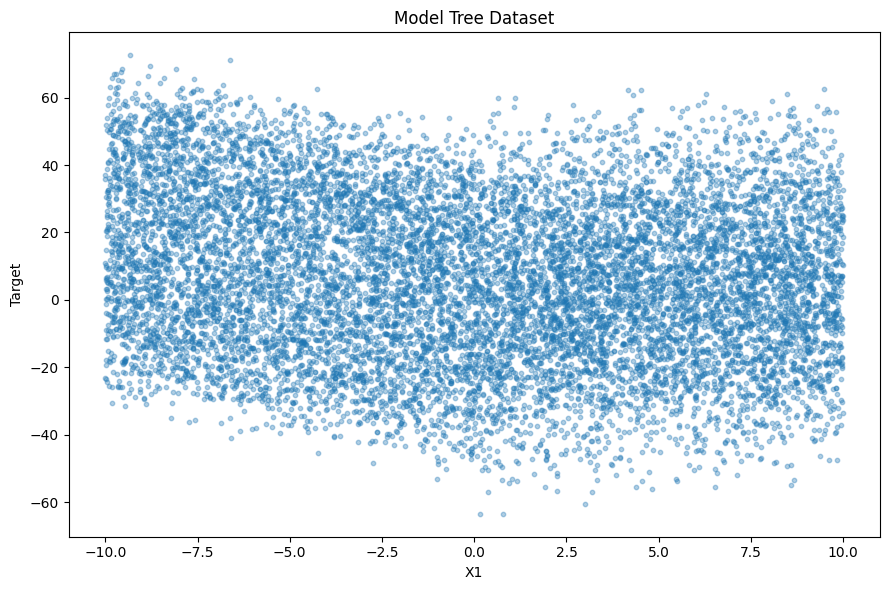

MODEL TREE REGRESSOR
Total samples    : 12,000
Training samples : 9,600
Testing samples  : 2,400
Number features  : 4
Maximum depth    : 6
Actual depth     : 6
Number of leaves : 34

Each leaf contains a separate linear regression model.

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
MAE  : 1.5521
MSE  : 3.8041
RMSE : 1.9504
R²   : 0.9934

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
MAE  : 1.6692
MSE  : 4.4446
RMSE : 2.1082
R²   : 0.9923

----------------------------------------------------------------------
FEATURE IMPORTANCE
----------------------------------------------------------------------
X1           : 0.9998
X2           : 0.0001
X3           : 0.0001
X4           : 0.0001


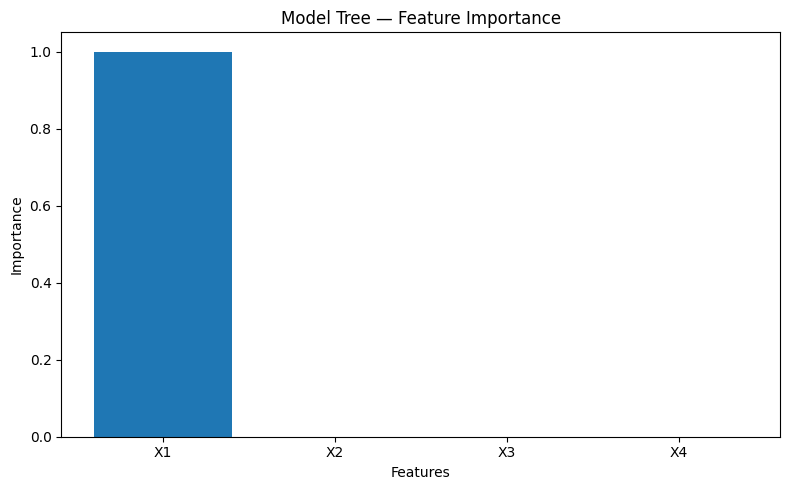

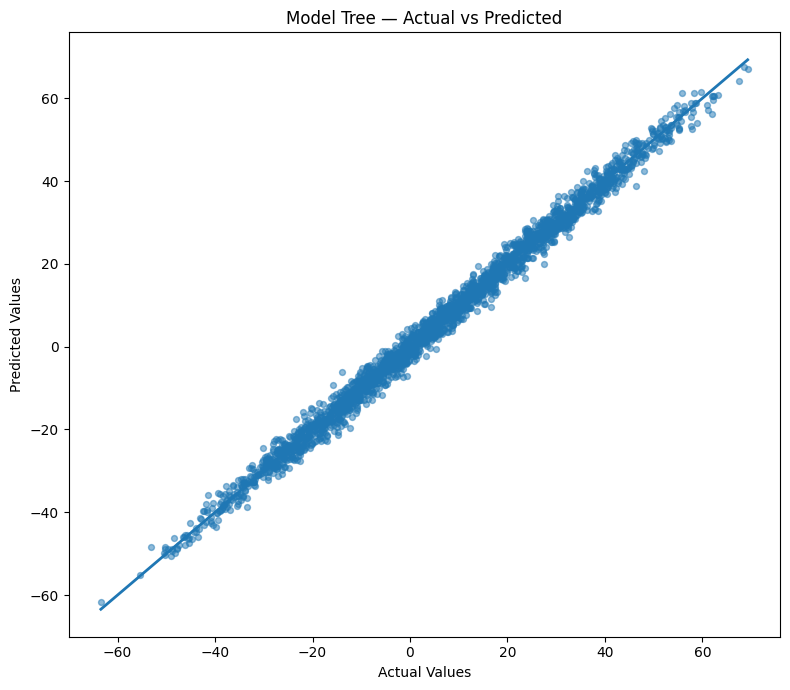

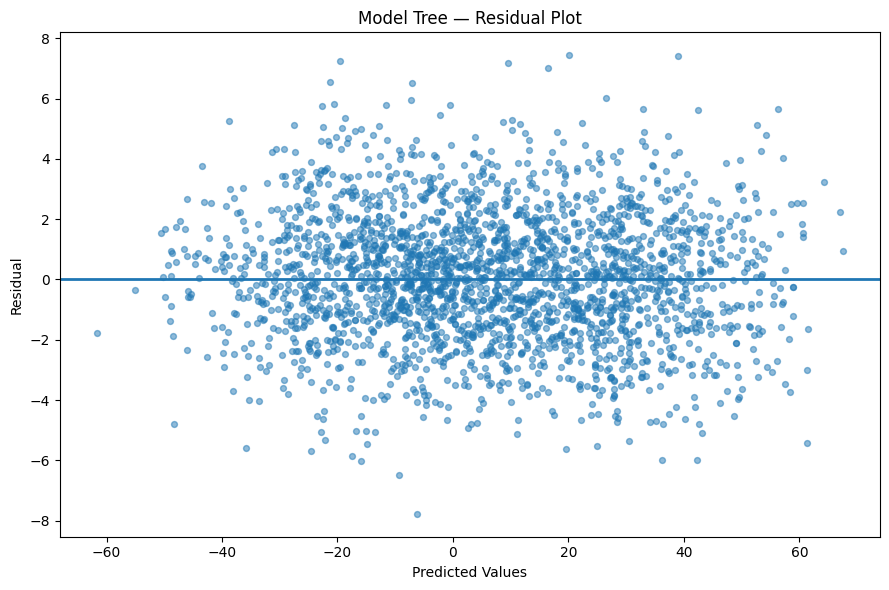

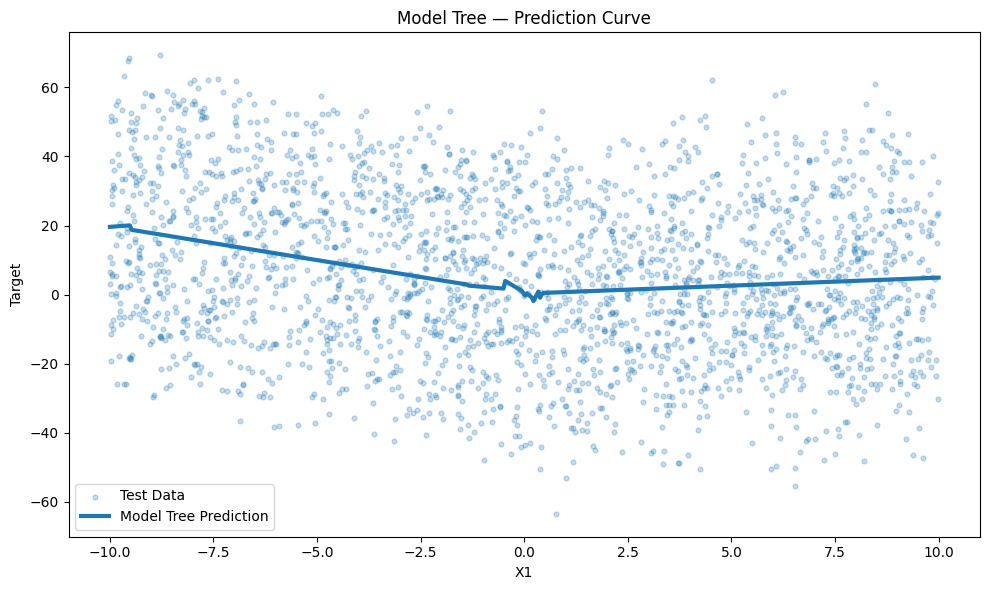

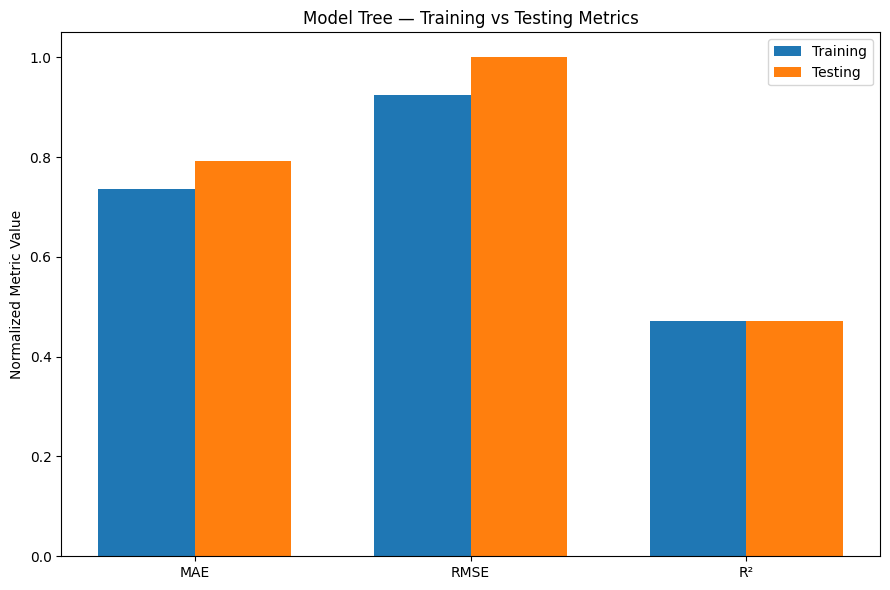


LINEAR MODELS STORED IN LEAVES
Leaf 1: y = 28.3076 + 0.9055*X1 + 3.9003*X2 + 0.4210*X3 - 0.9267*X4
Leaf 2: y = -0.1517 - 1.9561*X1 + 4.0005*X2 + 0.4757*X3 - 1.0239*X4
Leaf 3: y = 0.9488 - 1.8746*X1 + 4.0200*X2 + 0.3681*X3 - 1.0702*X4
Leaf 4: y = 1.1755 - 2.0449*X1 + 3.9993*X2 + 0.3153*X3 - 1.0205*X4
Leaf 5: y = 0.8730 - 1.0104*X1 + 4.0087*X2 + 0.4803*X3 - 0.9624*X4
Leaf 6: y = 0.2879 - 7.1509*X1 + 4.0194*X2 + 0.5156*X3 - 0.7231*X4
Leaf 7: y = -2.9834 - 2.2543*X1 + 4.9310*X2 + 0.5206*X3 - 0.4394*X4
Leaf 8: y = -3.6177 - 2.6034*X1 + 4.3892*X2 + 0.4801*X3 - 0.8991*X4
Leaf 9: y = -0.8657 - 2.1210*X1 + 3.9946*X2 + 0.4398*X3 - 1.0420*X4
Leaf 10: y = -5.1721 - 1.9805*X1 + 4.0678*X2 - 0.2052*X3 - 0.8047*X4
Leaf 11: y = 5.9987 - 1.9161*X1 + 3.4133*X2 + 0.3964*X3 - 1.4800*X4
Leaf 12: y = -1.5118 - 1.8640*X1 + 4.1391*X2 + 0.2237*X3 - 1.1782*X4
Leaf 13: y = 0.0987 - 1.9989*X1 + 4.0167*X2 + 0.4876*X3 - 0.9915*X4
Leaf 14: y = -0.4200 - 2.0463*X1 + 3.9601*X2 + 0.5084*X3 - 0.9777*X4
Leaf 15: y = -40.

In [14]:
# ============================================================
# MODEL TREE REGRESSOR — FROM SCRATCH
# ============================================================
#
# Model Tree:
#
# A decision tree where each leaf contains a linear regression
# model instead of a constant prediction.
#
# Standard Regression Tree:
#
#       Leaf prediction = mean(y)
#
# Model Tree:
#
#       Leaf prediction = Linear Regression(X)
#
# ============================================================
#
# IMPLEMENTED FROM SCRATCH:
#
#   1. Variance reduction
#   2. Best feature selection
#   3. Best threshold selection
#   4. Recursive tree construction
#   5. Linear regression at every leaf
#   6. Ridge-style numerical stabilization
#   7. Stopping criteria
#   8. Prediction
#   9. Feature importance
#
# ============================================================
#
# EVALUATION:
#
#   MAE
#   MSE
#   RMSE
#   R²
#
# VISUALIZATION:
#
#   Actual vs Predicted
#   Residual Plot
#   Feature Importance
#   Prediction Curve
#   Training vs Testing Metrics
#   Dataset Distribution
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. MODEL TREE NODE
# ============================================================

class ModelTreeNode:

    def __init__(
        self,
        feature_index=None,
        threshold=None,
        linear_model=None,
        prediction=None,
        is_leaf=False,
        depth=0
    ):

        self.feature_index = feature_index

        self.threshold = threshold

        self.linear_model = linear_model

        self.prediction = prediction

        self.is_leaf = is_leaf

        self.depth = depth

        self.left = None

        self.right = None

        self.impurity = None

        self.impurity_decrease = None

        self.n_samples = None


# ============================================================
# 2. MODEL TREE REGRESSOR
# ============================================================

class ModelTreeRegressor:

    def __init__(
        self,
        max_depth=6,
        min_samples_split=40,
        min_samples_leaf=20,
        n_thresholds=40,
        min_impurity_decrease=1e-7,
        ridge_alpha=1e-8,
        random_state=42
    ):

        self.max_depth = max_depth

        self.min_samples_split = (
            min_samples_split
        )

        self.min_samples_leaf = (
            min_samples_leaf
        )

        self.n_thresholds = (
            n_thresholds
        )

        self.min_impurity_decrease = (
            min_impurity_decrease
        )

        self.ridge_alpha = (
            ridge_alpha
        )

        self.random_state = (
            random_state
        )

        self.root = None

        self.n_features_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.tree_depth_ = 0

        self.n_leaves_ = 0


    # ========================================================
    # 3. LINEAR REGRESSION MODEL
    # ========================================================
    #
    # y = b0 + b1*x1 + b2*x2 + ... + bd*xd
    #
    # Using:
    #
    # beta = (X'X + alpha I)^(-1) X'y
    #
    # A small ridge_alpha improves numerical stability.
    #
    # ========================================================

    def _fit_linear_model(
        self,
        X,
        y
    ):

        n_samples = len(X)


        # ----------------------------------------------------
        # Add intercept
        # ----------------------------------------------------

        X_design = np.column_stack(

            [

                np.ones(n_samples),

                X

            ]

        )


        # ----------------------------------------------------
        # Ridge-style stabilization
        # ----------------------------------------------------

        identity = np.eye(

            X_design.shape[1]

        )


        identity[0, 0] = 0.0


        A = (

            X_design.T

            @

            X_design

            +

            self.ridge_alpha * identity

        )


        b = (

            X_design.T

            @

            y

        )


        # ----------------------------------------------------
        # Solve instead of explicit inverse
        # ----------------------------------------------------

        try:

            coefficients = np.linalg.solve(

                A,

                b

            )

        except np.linalg.LinAlgError:

            coefficients = (

                np.linalg.pinv(A)

                @

                b

            )


        return coefficients


    # ========================================================
    # 4. LINEAR MODEL PREDICTION
    # ========================================================

    def _linear_predict(
        self,
        X,
        coefficients
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        if X.ndim == 1:

            X = X.reshape(
                1,
                -1
            )


        X_design = np.column_stack(

            [

                np.ones(len(X)),

                X

            ]

        )


        return (

            X_design

            @

            coefficients

        )


    # ========================================================
    # 5. SUM OF SQUARED ERRORS
    # ========================================================

    def _sse(
        self,
        y,
        predictions
    ):

        residuals = (

            y

            -

            predictions

        )


        return np.sum(

            residuals ** 2

        )


    # ========================================================
    # 6. FIT LINEAR MODEL AND CALCULATE LEAF ERROR
    # ========================================================

    def _leaf_model_and_error(
        self,
        X,
        y
    ):

        coefficients = (

            self._fit_linear_model(

                X,

                y

            )

        )


        predictions = (

            self._linear_predict(

                X,

                coefficients

            )

        )


        error = self._sse(

            y,

            predictions

        )


        return (

            coefficients,

            error

        )


    # ========================================================
    # 7. CANDIDATE THRESHOLDS
    # ========================================================

    def _candidate_thresholds(
        self,
        values
    ):

        unique_values = np.unique(
            values
        )


        if len(unique_values) <= 1:

            return np.array([])


        thresholds = (

            unique_values[:-1]

            +

            unique_values[1:]

        ) / 2.0


        if len(thresholds) <= (

            self.n_thresholds

        ):

            return thresholds


        indices = np.linspace(

            0,

            len(thresholds) - 1,

            self.n_thresholds

        ).astype(int)


        indices = np.unique(
            indices
        )


        return thresholds[
            indices
        ]


    # ========================================================
    # 8. FIND BEST SPLIT
    # ========================================================
    #
    # Parent error:
    #
    #       SSE(parent linear model)
    #
    # Child error:
    #
    #       SSE(left linear model)
    #       +
    #       SSE(right linear model)
    #
    # Gain:
    #
    #       Parent SSE - Child SSE
    #
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        _, parent_error = (

            self._leaf_model_and_error(

                X,

                y

            )

        )


        best_feature = None

        best_threshold = None

        best_gain = -np.inf


        # ====================================================
        # SEARCH EVERY FEATURE
        # ====================================================

        for feature_index in range(

            self.n_features_

        ):

            feature_values = X[

                :,

                feature_index

            ]


            thresholds = (

                self._candidate_thresholds(

                    feature_values

                )

            )


            # ------------------------------------------------
            # SEARCH THRESHOLDS
            # ------------------------------------------------

            for threshold in thresholds:

                left_mask = (

                    feature_values

                    <=

                    threshold

                )


                right_mask = ~left_mask


                n_left = np.sum(
                    left_mask
                )


                n_right = np.sum(
                    right_mask
                )


                # ------------------------------------------------
                # Minimum leaf constraint
                # ------------------------------------------------

                if (

                    n_left
                    <
                    self.min_samples_leaf

                    or

                    n_right
                    <
                    self.min_samples_leaf

                ):

                    continue


                X_left = X[
                    left_mask
                ]


                y_left = y[
                    left_mask
                ]


                X_right = X[
                    right_mask
                ]


                y_right = y[
                    right_mask
                ]


                # ------------------------------------------------
                # Fit separate linear models
                # ------------------------------------------------

                _, left_error = (

                    self._leaf_model_and_error(

                        X_left,

                        y_left

                    )

                )


                _, right_error = (

                    self._leaf_model_and_error(

                        X_right,

                        y_right

                    )

                )


                child_error = (

                    left_error

                    +

                    right_error

                )


                # ------------------------------------------------
                # Error reduction
                # ------------------------------------------------

                gain = (

                    parent_error

                    -

                    child_error

                )


                if gain > best_gain:

                    best_gain = gain

                    best_feature = (

                        feature_index

                    )

                    best_threshold = (

                        threshold

                    )


        return (

            best_feature,

            best_threshold,

            best_gain,

            parent_error

        )


    # ========================================================
    # 9. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        # ----------------------------------------------------
        # Fit model for current node
        # ----------------------------------------------------

        coefficients, node_error = (

            self._leaf_model_and_error(

                X,

                y

            )

        )


        node = ModelTreeNode(

            linear_model=coefficients,

            is_leaf=False,

            depth=depth

        )


        node.n_samples = len(y)

        node.impurity = node_error


        self.tree_depth_ = max(

            self.tree_depth_,

            depth

        )


        # ====================================================
        # STOPPING CONDITION 1
        # ====================================================

        if (

            len(y)

            <

            self.min_samples_split

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 2
        # ====================================================

        if (

            depth >= self.max_depth

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STOPPING CONDITION 3
        # ====================================================

        if (

            node_error <= 1e-12

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # FIND BEST SPLIT
        # ====================================================

        (

            feature_index,

            threshold,

            gain,

            parent_error

        ) = self._find_best_split(

            X,

            y

        )


        # ====================================================
        # STOPPING CONDITION 4
        # ====================================================

        if (

            feature_index is None

            or

            threshold is None

            or

            gain <= self.min_impurity_decrease

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # STORE SPLIT
        # ====================================================

        node.feature_index = (

            feature_index

        )

        node.threshold = (

            threshold

        )

        node.impurity_decrease = (

            gain

        )


        # ====================================================
        # FEATURE IMPORTANCE
        # ====================================================

        self.feature_importances_[

            feature_index

        ] += (

            gain

        )


        # ====================================================
        # CREATE SPLIT
        # ====================================================

        feature_values = X[

            :,

            feature_index

        ]


        left_mask = (

            feature_values

            <=

            threshold

        )


        right_mask = ~left_mask


        X_left = X[
            left_mask
        ]


        y_left = y[
            left_mask
        ]


        X_right = X[
            right_mask
        ]


        y_right = y[
            right_mask
        ]


        # ====================================================
        # SAFETY CHECK
        # ====================================================

        if (

            len(y_left)
            <
            self.min_samples_leaf

            or

            len(y_right)
            <
            self.min_samples_leaf

        ):

            node.is_leaf = True

            self.n_leaves_ += 1

            return node


        # ====================================================
        # RECURSION
        # ====================================================

        node.left = self._build_tree(

            X_left,

            y_left,

            depth + 1

        )


        node.right = self._build_tree(

            X_right,

            y_right,

            depth + 1

        )


        return node


    # ========================================================
    # 10. FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        y = np.asarray(

            y,

            dtype=float

        )


        # ====================================================
        # VALIDATION
        # ====================================================

        if X.ndim != 2:

            raise ValueError(

                "X must be a 2-dimensional array."

            )


        if y.ndim != 1:

            raise ValueError(

                "y must be a 1-dimensional array."

            )


        if len(X) != len(y):

            raise ValueError(

                "X and y must have the same "
                "number of samples."

            )


        if len(X) < self.min_samples_split:

            raise ValueError(

                "Dataset contains fewer samples "
                "than min_samples_split."

            )


        self.n_features_ = X.shape[1]


        # ====================================================
        # FEATURE NAMES
        # ====================================================

        if feature_names is None:

            self.feature_names_ = [

                f"Feature_{i}"

                for i in range(

                    self.n_features_

                )

            ]

        else:

            self.feature_names_ = list(

                feature_names

            )


        # ====================================================
        # RESET TREE INFORMATION
        # ====================================================

        self.feature_importances_ = (

            np.zeros(

                self.n_features_

            )

        )


        self.tree_depth_ = 0

        self.n_leaves_ = 0


        # ====================================================
        # BUILD MODEL TREE
        # ====================================================

        self.root = self._build_tree(

            X,

            y,

            depth=0

        )


        # ====================================================
        # NORMALIZE FEATURE IMPORTANCE
        # ====================================================

        total = np.sum(

            self.feature_importances_

        )


        if total > 0:

            self.feature_importances_ /= total


        return self


    # ========================================================
    # 11. PREDICT SINGLE SAMPLE
    # ========================================================

    def _predict_sample(
        self,
        x,
        node
    ):

        # ----------------------------------------------------
        # Leaf:
        #
        # Use linear model stored in this leaf.
        # ----------------------------------------------------

        if node.is_leaf:

            prediction = (

                self._linear_predict(

                    x.reshape(
                        1,
                        -1
                    ),

                    node.linear_model

                )[0]

            )


            return prediction


        # ----------------------------------------------------
        # Internal node
        # ----------------------------------------------------

        if (

            x[node.feature_index]

            <=

            node.threshold

        ):

            return self._predict_sample(

                x,

                node.left

            )


        return self._predict_sample(

            x,

            node.right

        )


    # ========================================================
    # 12. PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        if X.ndim == 1:

            X = X.reshape(
                1,
                -1
            )


        predictions = []


        for x in X:

            predictions.append(

                self._predict_sample(

                    x,

                    self.root

                )

            )


        return np.asarray(

            predictions

        )


    # ========================================================
    # 13. COUNT LEAF MODELS
    # ========================================================

    def _collect_leaf_models(
        self,
        node,
        result=None
    ):

        if result is None:

            result = []


        if node.is_leaf:

            result.append(

                node.linear_model

            )

            return result


        self._collect_leaf_models(

            node.left,

            result

        )


        self._collect_leaf_models(

            node.right,

            result

        )


        return result


    # ========================================================
    # 14. SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        y_pred = self.predict(X)


        ss_res = np.sum(

            (

                y - y_pred

            ) ** 2

        )


        ss_tot = np.sum(

            (

                y - np.mean(y)

            ) ** 2

        )


        if ss_tot == 0:

            return 1.0


        return 1.0 - (

            ss_res / ss_tot

        )


# ============================================================
# 15. MANUAL TRAIN / TEST SPLIT
# ============================================================

def train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42

):

    rng = np.random.default_rng(

        random_state

    )


    indices = np.arange(

        len(X)

    )


    rng.shuffle(
        indices
    )


    n_test = int(

        len(X)

        *

        test_size

    )


    test_indices = (

        indices[:n_test]

    )


    train_indices = (

        indices[n_test:]

    )


    return (

        X[train_indices],

        X[test_indices],

        y[train_indices],

        y[test_indices]

    )


# ============================================================
# 16. REGRESSION METRICS
# ============================================================

def regression_metrics(
    y_true,
    y_pred
):

    errors = (

        y_true

        -

        y_pred

    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = np.mean(

        np.abs(errors)

    )


    # --------------------------------------------------------
    # MSE
    # --------------------------------------------------------

    mse = np.mean(

        errors ** 2

    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        mse
    )


    # --------------------------------------------------------
    # R²
    # --------------------------------------------------------

    ss_res = np.sum(

        errors ** 2

    )


    ss_tot = np.sum(

        (

            y_true

            -

            np.mean(y_true)

        ) ** 2

    )


    if ss_tot == 0:

        r2 = 1.0

    else:

        r2 = 1.0 - (

            ss_res / ss_tot

        )


    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2

    }


# ============================================================
# 17. CREATE LARGE DATASET
# ============================================================
#
# 12,000 observations
#
# The relationship intentionally changes in different
# regions of the feature space.
#
# This is where Model Trees are particularly useful.
#
# ============================================================

rng = np.random.default_rng(

    42

)


n_samples = 12000


# ------------------------------------------------------------
# Features
# ------------------------------------------------------------

X = rng.uniform(

    -10,

    10,

    size=(

        n_samples,

        4

    )

)


x1 = X[:, 0]

x2 = X[:, 1]

x3 = X[:, 2]

x4 = X[:, 3]


# ============================================================
# PIECEWISE LINEAR DATA GENERATING PROCESS
# ============================================================
#
# Region 1:
#
# y = 3x1 + 2x2 - x3 + 0.5x4
#
# Region 2:
#
# y = -2x1 + 4x2 + 0.5x3 - x4
#
# Region 3:
#
# y = 0.5x1 - 3x2 + 2x3 + 1.5x4
#
# ============================================================

y = np.zeros(
    n_samples
)


region_1 = (

    x1 < 0

    &

    (x2 < 0)

)


region_2 = (

    x1 < 0

    &

    (x2 >= 0)

)


region_3 = (

    x1 >= 0

)


y[region_1] = (

    3.0 * x1[region_1]

    +

    2.0 * x2[region_1]

    -

    1.0 * x3[region_1]

    +

    0.5 * x4[region_1]

)


y[region_2] = (

    -2.0 * x1[region_2]

    +

    4.0 * x2[region_2]

    +

    0.5 * x3[region_2]

    -

    1.0 * x4[region_2]

)


y[region_3] = (

    0.5 * x1[region_3]

    -

    3.0 * x2[region_3]

    +

    2.0 * x3[region_3]

    +

    1.5 * x4[region_3]

)


# ------------------------------------------------------------
# Add Gaussian noise
# ------------------------------------------------------------

noise = rng.normal(

    0,

    2.0,

    n_samples

)


y += noise


feature_names = [

    "X1",

    "X2",

    "X3",

    "X4"

]


# ============================================================
# 18. DATASET VISUALIZATION
# ============================================================

plt.figure(

    figsize=(9, 6)

)


plt.scatter(

    X[:, 0],

    y,

    s=10,

    alpha=0.35

)


plt.xlabel(

    "X1"

)


plt.ylabel(

    "Target"

)


plt.title(

    "Model Tree Dataset"

)


plt.tight_layout()

plt.show()


# ============================================================
# 19. TRAIN / TEST SPLIT
# ============================================================

(

    X_train,

    X_test,

    y_train,

    y_test

) = train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42

)


# ============================================================
# 20. CREATE MODEL TREE
# ============================================================

model = ModelTreeRegressor(

    max_depth=6,

    min_samples_split=50,

    min_samples_leaf=25,

    n_thresholds=40,

    min_impurity_decrease=1e-7,

    ridge_alpha=1e-8,

    random_state=42

)


# ============================================================
# 21. TRAIN
# ============================================================

model.fit(

    X_train,

    y_train,

    feature_names=feature_names

)


# ============================================================
# 22. PREDICTIONS
# ============================================================

y_train_pred = model.predict(

    X_train

)


y_test_pred = model.predict(

    X_test

)


# ============================================================
# 23. EVALUATION
# ============================================================

train_metrics = regression_metrics(

    y_train,

    y_train_pred

)


test_metrics = regression_metrics(

    y_test,

    y_test_pred

)


# ============================================================
# 24. MODEL INFORMATION
# ============================================================

print("=" * 70)

print(
    "MODEL TREE REGRESSOR"
)

print("=" * 70)


print(

    f"Total samples    : "
    f"{n_samples:,}"

)


print(

    f"Training samples : "
    f"{len(X_train):,}"

)


print(

    f"Testing samples  : "
    f"{len(X_test):,}"

)


print(

    f"Number features  : "
    f"{model.n_features_}"

)


print(

    f"Maximum depth    : "
    f"{model.max_depth}"

)


print(

    f"Actual depth     : "
    f"{model.tree_depth_}"

)


print(

    f"Number of leaves : "
    f"{model.n_leaves_}"

)


print()

print(

    "Each leaf contains a separate "
    "linear regression model."

)


# ============================================================
# 25. TRAINING METRICS
# ============================================================

print()

print("-" * 70)

print(
    "TRAINING PERFORMANCE"
)

print("-" * 70)


print(

    f"MAE  : "
    f"{train_metrics['MAE']:.4f}"

)


print(

    f"MSE  : "
    f"{train_metrics['MSE']:.4f}"

)


print(

    f"RMSE : "
    f"{train_metrics['RMSE']:.4f}"

)


print(

    f"R²   : "
    f"{train_metrics['R2']:.4f}"

)


# ============================================================
# 26. TESTING METRICS
# ============================================================

print()

print("-" * 70)

print(
    "TEST PERFORMANCE"
)

print("-" * 70)


print(

    f"MAE  : "
    f"{test_metrics['MAE']:.4f}"

)


print(

    f"MSE  : "
    f"{test_metrics['MSE']:.4f}"

)


print(

    f"RMSE : "
    f"{test_metrics['RMSE']:.4f}"

)


print(

    f"R²   : "
    f"{test_metrics['R2']:.4f}"

)


# ============================================================
# 27. FEATURE IMPORTANCE
# ============================================================

print()

print("-" * 70)

print(
    "FEATURE IMPORTANCE"
)

print("-" * 70)


for name, importance in zip(

    model.feature_names_,

    model.feature_importances_

):

    print(

        f"{name:<12} : "
        f"{importance:.4f}"

    )


# ============================================================
# 28. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.bar(

    model.feature_names_,

    model.feature_importances_

)


plt.xlabel(

    "Features"

)


plt.ylabel(

    "Importance"

)


plt.title(

    "Model Tree — Feature Importance"

)


plt.tight_layout()

plt.show()


# ============================================================
# 29. ACTUAL VS PREDICTED
# ============================================================

plt.figure(

    figsize=(8, 7)

)


plt.scatter(

    y_test,

    y_test_pred,

    s=18,

    alpha=0.5

)


minimum = min(

    y_test.min(),

    y_test_pred.min()

)


maximum = max(

    y_test.max(),

    y_test_pred.max()

)


plt.plot(

    [minimum, maximum],

    [minimum, maximum],

    linewidth=2

)


plt.xlabel(

    "Actual Values"

)


plt.ylabel(

    "Predicted Values"

)


plt.title(

    "Model Tree — Actual vs Predicted"

)


plt.tight_layout()

plt.show()


# ============================================================
# 30. RESIDUAL PLOT
# ============================================================

residuals = (

    y_test

    -

    y_test_pred

)


plt.figure(

    figsize=(9, 6)

)


plt.scatter(

    y_test_pred,

    residuals,

    s=18,

    alpha=0.5

)


plt.axhline(

    0,

    linewidth=2

)


plt.xlabel(

    "Predicted Values"

)


plt.ylabel(

    "Residual"

)


plt.title(

    "Model Tree — Residual Plot"

)


plt.tight_layout()

plt.show()


# ============================================================
# 31. PREDICTION CURVE
# ============================================================
#
# We vary X1 while fixing X2, X3 and X4 at their medians.
#
# ============================================================

x1_values = np.linspace(

    X[:, 0].min(),

    X[:, 0].max(),

    500

)


X_curve = np.zeros(

    (
        len(x1_values),

        4

    )

)


X_curve[:, 0] = x1_values


X_curve[:, 1] = np.median(

    X[:, 1]

)


X_curve[:, 2] = np.median(

    X[:, 2]

)


X_curve[:, 3] = np.median(

    X[:, 3]

)


curve_predictions = model.predict(

    X_curve

)


plt.figure(

    figsize=(10, 6)

)


plt.scatter(

    X_test[:, 0],

    y_test,

    s=12,

    alpha=0.25,

    label="Test Data"

)


plt.plot(

    x1_values,

    curve_predictions,

    linewidth=3,

    label="Model Tree Prediction"

)


plt.xlabel(

    "X1"

)


plt.ylabel(

    "Target"

)


plt.title(

    "Model Tree — Prediction Curve"

)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 32. TRAINING VS TESTING METRICS
# ============================================================

metric_names = [

    "MAE",

    "RMSE",

    "R²"

]


train_values = [

    train_metrics["MAE"],

    train_metrics["RMSE"],

    train_metrics["R2"]

]


test_values = [

    test_metrics["MAE"],

    test_metrics["RMSE"],

    test_metrics["R2"]

]


x = np.arange(

    len(metric_names)

)


width = 0.35


fig, ax1 = plt.subplots(

    figsize=(9, 6)

)


# ------------------------------------------------------------
# Since MAE/RMSE and R² have different scales,
# visualize them separately using normalized values.
# ------------------------------------------------------------

all_values = np.array(

    train_values + test_values

)


max_value = np.max(

    all_values

)


if max_value > 0:

    train_plot = (

        np.array(train_values)

        /

        max_value

    )


    test_plot = (

        np.array(test_values)

        /

        max_value

    )

else:

    train_plot = train_values

    test_plot = test_values


ax1.bar(

    x - width / 2,

    train_plot,

    width,

    label="Training"

)


ax1.bar(

    x + width / 2,

    test_plot,

    width,

    label="Testing"

)


ax1.set_xticks(x)


ax1.set_xticklabels(

    metric_names

)


ax1.set_ylabel(

    "Normalized Metric Value"

)


ax1.set_title(

    "Model Tree — Training vs Testing Metrics"

)


ax1.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 33. LEAF LINEAR MODELS
# ============================================================
#
# Display the linear equations learned at each leaf.
#
# ============================================================

leaf_models = (

    model._collect_leaf_models(

        model.root

    )

)


print()

print("=" * 70)

print(
    "LINEAR MODELS STORED IN LEAVES"
)

print("=" * 70)


for i, coefficients in enumerate(

    leaf_models

):

    equation = (

        f"Leaf {i + 1}: "

        f"y = {coefficients[0]:.4f}"

    )


    for j in range(

        1,

        len(coefficients)

    ):

        sign = (

            "+"

            if coefficients[j] >= 0

            else "-"

        )


        equation += (

            f" {sign} "

            f"{abs(coefficients[j]):.4f}"

            f"*{model.feature_names_[j - 1]}"

        )


    print(equation)

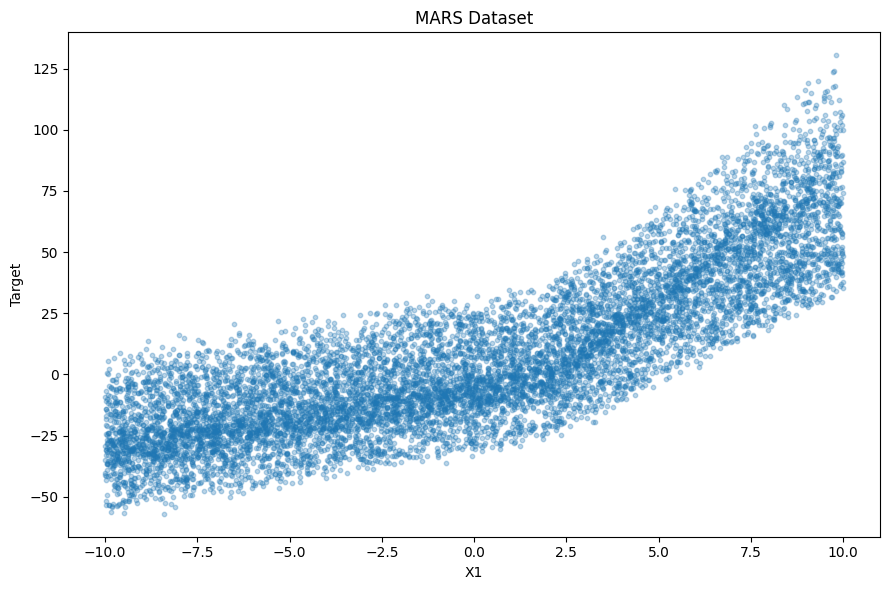

MARS — MULTIVARIATE ADAPTIVE REGRESSION SPLINES
Total samples    : 10,000
Training samples : 8,000
Testing samples  : 2,000
Number features  : 4
Maximum terms    : 25
Maximum degree   : 2
Final terms      : 20
GCV              : 2.413347

----------------------------------------------------------------------
TRAINING PERFORMANCE
----------------------------------------------------------------------
MAE  : 1.2228
MSE  : 2.3671
RMSE : 1.5385
R²   : 0.9977

----------------------------------------------------------------------
TEST PERFORMANCE
----------------------------------------------------------------------
MAE  : 1.2637
MSE  : 2.4942
RMSE : 1.5793
R²   : 0.9976

----------------------------------------------------------------------
FEATURE IMPORTANCE
----------------------------------------------------------------------
X1           : 0.6895
X2           : 0.1030
X3           : 0.0794
X4           : 0.1281


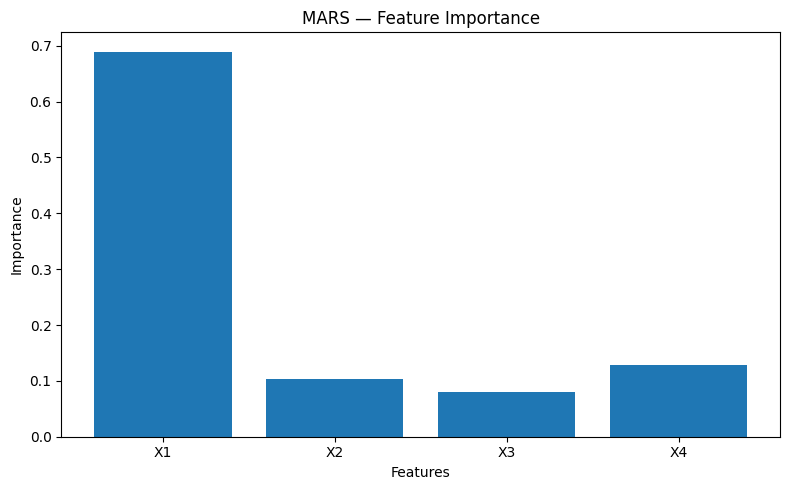

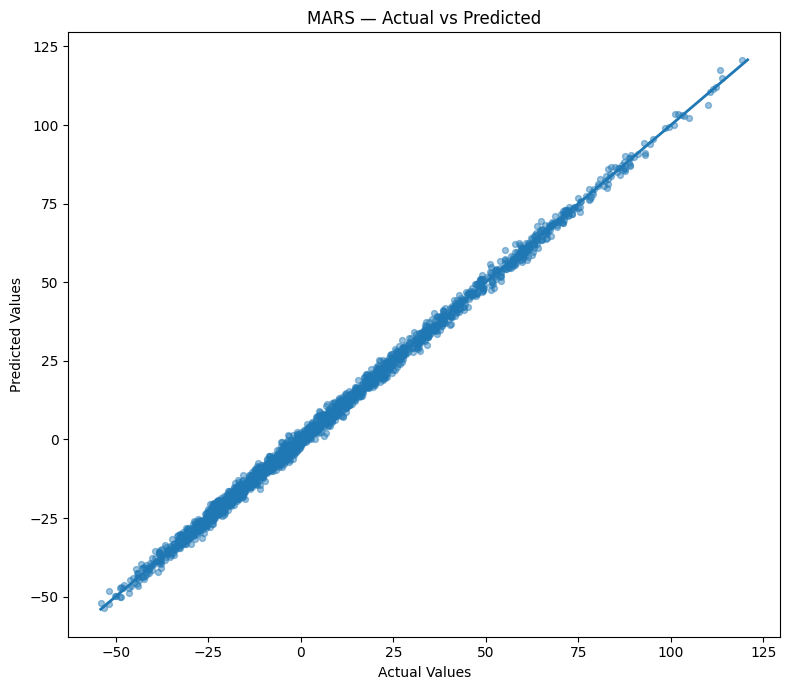

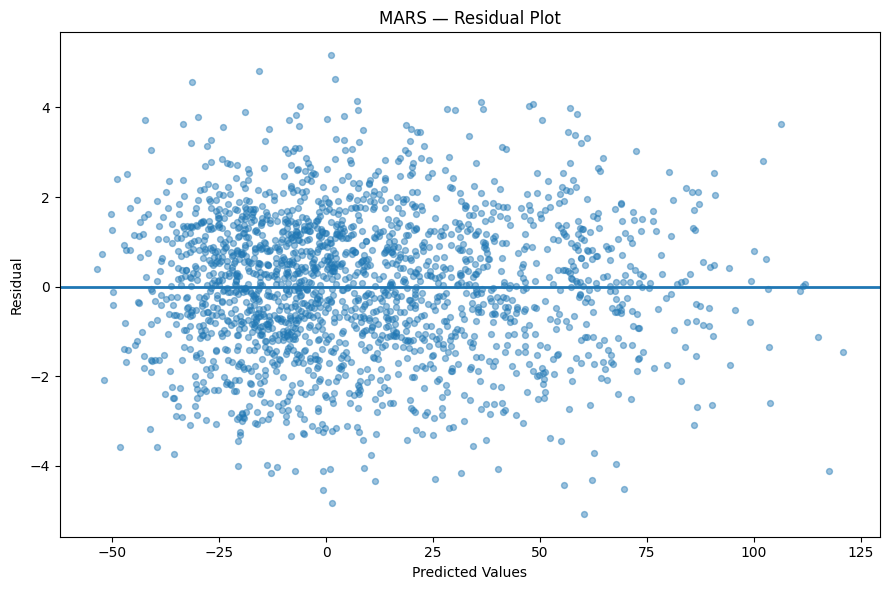

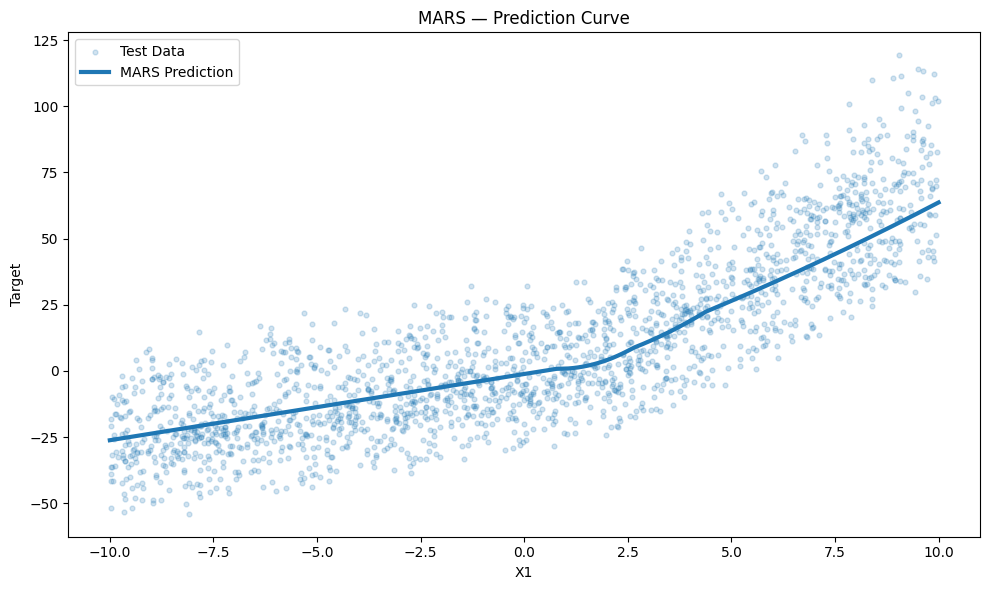

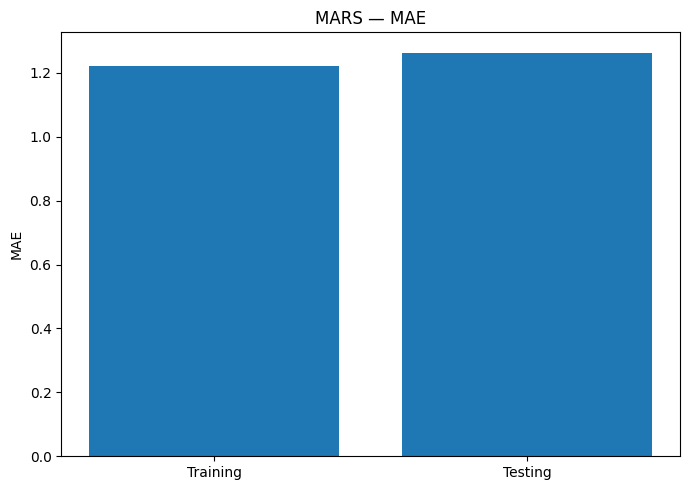

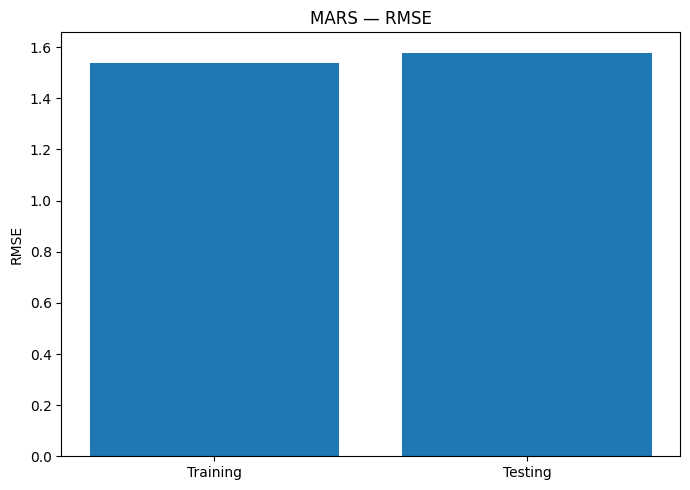

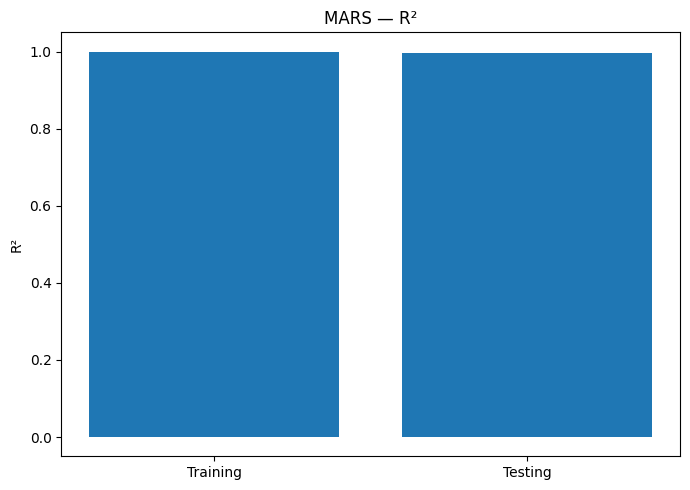


MARS BASIS FUNCTIONS
Term 00: -7.147212 * 1
Term 01: -2.503156 * max(0, 0.791 - X1)
Term 02: +2.630493 * max(0, X3 - -2.638)
Term 03: -2.228308 * max(0, 2.826 - X2)
Term 04: -1.711887 * max(0, X2 - 2.826)
Term 05: +0.385568 * max(0, X2 - 2.826) * max(0, X1 - 2.635)
Term 06: +2.445089 * max(0, X1 - 0.791) * max(0, 4.386 - X1)
Term 07: -3.277152 * max(0, X1 - 0.791) * max(0, X1 - 4.386)
Term 08: +0.697293 * max(0, 4.537 - X4)
Term 09: -3.339640 * max(0, X4 - 4.537)
Term 10: +0.087691 * max(0, 4.537 - X4) * max(0, X4 - -0.843)
Term 11: +0.011583 * max(0, X1 - 0.791) * max(0, 0.968 - X2)
Term 12: +0.345562 * max(0, X1 - 0.791) * max(0, X2 - 0.968)
Term 13: -0.464619 * max(0, X3 - -2.638) * max(0, 0.972 - X3)
Term 14: +0.025645 * max(0, X3 - -2.638) * max(0, X3 - 0.972)
Term 15: +1.276711 * max(0, X4 - -2.714)
Term 16: -4.903574 * max(0, X1 - 0.791) * max(0, 2.635 - X1)
Term 17: +3.423340 * max(0, X1 - 0.791) * max(0, X1 - 2.635)
Term 18: +0.060114 * max(0, X4 - -2.714) * max(0, 4.537 - X4

In [16]:
# ============================================================
# MARS
# MULTIVARIATE ADAPTIVE REGRESSION SPLINES
# ============================================================
#
# FROM SCRATCH
#
# NO:
#   sklearn
#   scipy
#   statsmodels
#   pyearth
#
# ONLY:
#   NumPy
#   Matplotlib
#
# ============================================================
#
# MARS builds a model of the form:
#
# y_hat = beta_0
#       + beta_1 B_1(x)
#       + beta_2 B_2(x)
#       + ...
#
# where B(x) are basis functions.
#
# Main basis functions:
#
#   max(0, x_j - t)
#
#   max(0, t - x_j)
#
# ============================================================
#
# ALGORITHM:
#
# Forward Pass:
#
#   1. Start with intercept
#   2. Generate hinge functions
#   3. Add pairs of basis functions
#   4. Select pair producing maximum SSE reduction
#   5. Repeat until max_terms
#
# Backward Pass:
#
#   6. Remove unnecessary basis functions
#   7. Use GCV to select model complexity
#
# ============================================================
#
# IMPLEMENTED:
#
#   1. Hinge basis functions
#   2. Candidate knot generation
#   3. Forward basis-function selection
#   4. Least-squares coefficient estimation
#   5. Backward pruning
#   6. Generalized Cross Validation
#   7. Prediction
#   8. Feature importance
#
# ============================================================
#
# EVALUATION:
#
#   MAE
#   MSE
#   RMSE
#   R²
#
# VISUALIZATION:
#
#   Dataset
#   Actual vs Predicted
#   Residual Plot
#   Prediction Curve
#   Feature Importance
#   Training vs Testing Metrics
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. MARS REGRESSOR
# ============================================================

class MARSRegressor:

    def __init__(
        self,
        max_terms=25,
        max_degree=2,
        n_knots=15,
        min_span=20,
        penalty=3.0,
        ridge_alpha=1e-8,
        random_state=42
    ):

        self.max_terms = max_terms

        self.max_degree = max_degree

        self.n_knots = n_knots

        self.min_span = min_span

        self.penalty = penalty

        self.ridge_alpha = ridge_alpha

        self.random_state = random_state

        self.rng = np.random.default_rng(
            random_state
        )

        self.basis_functions_ = []

        self.coefficients_ = None

        self.n_features_ = None

        self.n_terms_ = None

        self.feature_names_ = None

        self.feature_importances_ = None

        self.gcv_ = None


    # ========================================================
    # 2. HINGE FUNCTION
    # ========================================================
    #
    # h+(x,t) = max(0, x-t)
    #
    # h-(x,t) = max(0, t-x)
    #
    # ========================================================

    def _hinge(
        self,
        x,
        knot,
        direction
    ):

        if direction == "right":

            return np.maximum(

                0.0,

                x - knot

            )


        else:

            return np.maximum(

                0.0,

                knot - x

            )


    # ========================================================
    # 3. BASIS FUNCTION EVALUATION
    # ========================================================
    #
    # A basis function can be:
    #
    #   constant
    #
    # OR
    #
    #   product of hinge functions
    #
    # Example:
    #
    #   B(x) =
    #
    #   max(0, X1 - 2.5)
    #
    # OR:
    #
    #   B(x) =
    #
    #   max(0, X1 - 2.5)
    #
    #   *
    #
    #   max(0, 3.1 - X2)
    #
    # ========================================================

    def _evaluate_basis(
        self,
        X,
        basis
    ):

        if basis["type"] == "constant":

            return np.ones(

                len(X)

            )


        values = np.ones(

            len(X)

        )


        for component in basis[
            "components"
        ]:

            feature = (

                component[
                    "feature"
                ]

            )


            knot = (

                component[
                    "knot"
                ]

            )


            direction = (

                component[
                    "direction"
                ]

            )


            values *= self._hinge(

                X[:, feature],

                knot,

                direction

            )


        return values


    # ========================================================
    # 4. DESIGN MATRIX
    # ========================================================

    def _build_design_matrix(
        self,
        X,
        basis_functions=None
    ):

        if basis_functions is None:

            basis_functions = (

                self.basis_functions_

            )


        columns = []


        for basis in basis_functions:

            columns.append(

                self._evaluate_basis(

                    X,

                    basis

                )

            )


        return np.column_stack(

            columns

        )


    # ========================================================
    # 5. FIT LINEAR COEFFICIENTS
    # ========================================================

    def _fit_coefficients(
        self,
        X_design,
        y
    ):

        n_columns = (

            X_design.shape[1]

        )


        identity = np.eye(

            n_columns

        )


        # Do not penalize intercept

        identity[0, 0] = 0.0


        A = (

            X_design.T

            @

            X_design

            +

            self.ridge_alpha * identity

        )


        b = (

            X_design.T

            @

            y

        )


        try:

            coefficients = (

                np.linalg.solve(

                    A,

                    b

                )

            )

        except np.linalg.LinAlgError:

            coefficients = (

                np.linalg.pinv(A)

                @

                b

            )


        return coefficients


    # ========================================================
    # 6. SSE
    # ========================================================

    def _sse(
        self,
        y,
        predictions
    ):

        residuals = (

            y

            -

            predictions

        )


        return np.sum(

            residuals ** 2

        )


    # ========================================================
    # 7. GENERATE KNOTS
    # ========================================================

    def _generate_knots(
        self,
        x
    ):

        values = np.sort(

            np.unique(x)

        )


        if len(values) <= (

            2 * self.min_span

        ):

            return values


        lower = self.min_span


        upper = (

            len(values)

            -

            self.min_span

            -

            1

        )


        if upper <= lower:

            return np.array([])


        indices = np.linspace(

            lower,

            upper,

            self.n_knots

        ).astype(int)


        indices = np.unique(

            indices

        )


        return values[

            indices

        ]


    # ========================================================
    # 8. CREATE CANDIDATE BASIS PAIR
    # ========================================================
    #
    # For feature j and knot t:
    #
    #   B1 = max(0, x_j - t)
    #
    #   B2 = max(0, t - x_j)
    #
    # MARS normally adds the pair together.
    #
    # ========================================================

    def _create_pair(
        self,
        parent_basis,
        feature,
        knot
    ):

        left_basis = {

            "type": "product",

            "components": [

                *parent_basis[
                    "components"
                ],

                {

                    "feature": feature,

                    "knot": knot,

                    "direction": "left"

                }

            ]

        }


        right_basis = {

            "type": "product",

            "components": [

                *parent_basis[
                    "components"
                ],

                {

                    "feature": feature,

                    "knot": knot,

                    "direction": "right"

                }

            ]

        }


        return (

            left_basis,

            right_basis

        )


    # ========================================================
    # 9. BASIS DEGREE
    # ========================================================

    def _basis_degree(
        self,
        basis
    ):

        if basis["type"] == "constant":

            return 0


        return len(

            basis["components"]

        )


    # ========================================================
    # 10. BASIS DUPLICATE CHECK
    # ========================================================

    def _basis_signature(
        self,
        basis
    ):

        if basis["type"] == "constant":

            return ("constant",)


        components = []


        for component in basis[
            "components"
        ]:

            components.append(

                (

                    component[
                        "feature"
                    ],

                    round(

                        component[
                            "knot"
                        ],

                        10

                    ),

                    component[
                        "direction"
                    ]

                )

            )


        return tuple(

            components

        )


    # ========================================================
    # 11. GENERALIZED CROSS VALIDATION
    # ========================================================
    #
    # GCV =
    #
    #     SSE / n
    #
    #     -------------------
    #
    #     (1 - C(M)/n)^2
    #
    # where:
    #
    # C(M) = M + penalty * (M - 1) / 2
    #
    # ========================================================

    def _gcv(
        self,
        y,
        predictions,
        n_terms
    ):

        n = len(y)


        sse = self._sse(

            y,

            predictions

        )


        effective_terms = (

            n_terms

            +

            self.penalty

            *

            max(

                0,

                n_terms - 1

            )

        )


        denominator = (

            1.0

            -

            effective_terms / n

        ) ** 2


        if denominator <= 1e-12:

            return np.inf


        return (

            (sse / n)

            /

            denominator

        )


    # ========================================================
    # 12. FORWARD PASS
    # ========================================================

    def _forward_pass(
        self,
        X,
        y
    ):

        # ----------------------------------------------------
        # Start with intercept
        # ----------------------------------------------------

        basis_functions = [

            {

                "type": "constant",

                "components": []

            }

        ]


        X_design = (

            self._build_design_matrix(

                X,

                basis_functions

            )

        )


        coefficients = (

            self._fit_coefficients(

                X_design,

                y

            )

        )


        predictions = (

            X_design

            @

            coefficients

        )


        current_error = self._sse(

            y,

            predictions

        )


        # ====================================================
        # FORWARD SEARCH
        # ====================================================

        while len(

            basis_functions

        ) < self.max_terms:


            best_pair = None

            best_error = np.inf

            best_improvement = 0.0


            existing_signatures = {

                self._basis_signature(

                    basis

                )

                for basis in basis_functions

            }


            # ------------------------------------------------
            # Try every existing non-constant basis
            # ------------------------------------------------

            parent_candidates = [

                basis

                for basis in basis_functions

                if (

                    self._basis_degree(
                        basis
                    )

                    <

                    self.max_degree

                )

            ]


            # ------------------------------------------------
            # Search parent basis functions
            # ------------------------------------------------

            for parent_basis in (

                parent_candidates

            ):

                for feature in range(

                    self.n_features_

                ):

                    knots = (

                        self._generate_knots(

                            X[:, feature]

                        )

                    )


                    for knot in knots:

                        (

                            left_basis,

                            right_basis

                        ) = self._create_pair(

                            parent_basis,

                            feature,

                            knot

                        )


                        left_signature = (

                            self._basis_signature(

                                left_basis

                            )

                        )


                        right_signature = (

                            self._basis_signature(

                                right_basis

                            )

                        )


                        # ------------------------------------------------
                        # Duplicate check
                        # ------------------------------------------------

                        if (

                            left_signature
                            in
                            existing_signatures

                            or

                            right_signature
                            in
                            existing_signatures

                        ):

                            continue


                        # ------------------------------------------------
                        # Evaluate candidate pair
                        # ------------------------------------------------

                        candidate_basis = [

                            *basis_functions,

                            left_basis,

                            right_basis

                        ]


                        candidate_matrix = (

                            self._build_design_matrix(

                                X,

                                candidate_basis

                            )

                        )


                        candidate_coefficients = (

                            self._fit_coefficients(

                                candidate_matrix,

                                y

                            )

                        )


                        candidate_predictions = (

                            candidate_matrix

                            @

                            candidate_coefficients

                        )


                        candidate_error = (

                            self._sse(

                                y,

                                candidate_predictions

                            )

                        )


                        improvement = (

                            current_error

                            -

                            candidate_error

                        )


                        if improvement > (

                            best_improvement

                        ):

                            best_improvement = (

                                improvement

                            )

                            best_error = (

                                candidate_error

                            )

                            best_pair = (

                                left_basis,

                                right_basis

                            )


            # ------------------------------------------------
            # No useful improvement
            # ------------------------------------------------

            if best_pair is None:

                break


            # ------------------------------------------------
            # Add best pair
            # ------------------------------------------------

            basis_functions.extend(

                best_pair

            )


            current_error = (

                best_error

            )


        return basis_functions


    # ========================================================
    # 13. BACKWARD PRUNING
    # ========================================================
    #
    # Starting with the large forward model, repeatedly remove
    # the basis function whose removal produces the smallest
    # increase in GCV.
    #
    # ========================================================

    def _backward_pass(
        self,
        X,
        y,
        basis_functions
    ):

        current_basis = list(

            basis_functions

        )


        best_basis = list(

            current_basis

        )


        X_design = (

            self._build_design_matrix(

                X,

                current_basis

            )

        )


        coefficients = (

            self._fit_coefficients(

                X_design,

                y

            )

        )


        predictions = (

            X_design

            @

            coefficients

        )


        best_gcv = self._gcv(

            y,

            predictions,

            len(current_basis)

        )


        # ====================================================
        # Remove terms
        # ====================================================

        while len(current_basis) > 1:


            removal_candidate = None

            removal_gcv = np.inf


            # ------------------------------------------------
            # Never remove intercept
            # ------------------------------------------------

            for index in range(

                1,

                len(current_basis)

            ):

                candidate_basis = (

                    current_basis[

                        :index

                    ]

                    +

                    current_basis[

                        index + 1:

                    ]

                )


                candidate_matrix = (

                    self._build_design_matrix(

                        X,

                        candidate_basis

                    )

                )


                candidate_coefficients = (

                    self._fit_coefficients(

                        candidate_matrix,

                        y

                    )

                )


                candidate_predictions = (

                    candidate_matrix

                    @

                    candidate_coefficients

                )


                candidate_gcv = self._gcv(

                    y,

                    candidate_predictions,

                    len(candidate_basis)

                )


                if candidate_gcv < removal_gcv:

                    removal_gcv = (

                        candidate_gcv

                    )

                    removal_candidate = (

                        candidate_basis

                    )


            # ------------------------------------------------
            # Keep removal only if GCV improves
            # ------------------------------------------------

            if (

                removal_candidate is None

                or

                removal_gcv >= best_gcv

            ):

                break


            current_basis = (

                removal_candidate

            )


            best_basis = list(

                current_basis

            )


            best_gcv = (

                removal_gcv

            )


        return (

            best_basis,

            best_gcv

        )


    # ========================================================
    # 14. FIT
    # ========================================================

    def fit(
        self,
        X,
        y,
        feature_names=None
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        y = np.asarray(

            y,

            dtype=float

        )


        # ====================================================
        # VALIDATION
        # ====================================================

        if X.ndim != 2:

            raise ValueError(

                "X must be a 2-dimensional array."

            )


        if y.ndim != 1:

            raise ValueError(

                "y must be a 1-dimensional array."

            )


        if len(X) != len(y):

            raise ValueError(

                "X and y must have the same "
                "number of samples."

            )


        self.n_features_ = (

            X.shape[1]

        )


        # ====================================================
        # FEATURE NAMES
        # ====================================================

        if feature_names is None:

            self.feature_names_ = [

                f"Feature_{i}"

                for i in range(

                    self.n_features_

                )

            ]

        else:

            self.feature_names_ = list(

                feature_names

            )


        # ====================================================
        # FORWARD PASS
        # ====================================================

        forward_basis = (

            self._forward_pass(

                X,

                y

            )

        )


        # ====================================================
        # BACKWARD PASS
        # ====================================================

        (

            self.basis_functions_,

            self.gcv_

        ) = self._backward_pass(

            X,

            y,

            forward_basis

        )


        # ====================================================
        # FINAL COEFFICIENTS
        # ====================================================

        X_design = (

            self._build_design_matrix(

                X,

                self.basis_functions_

            )

        )


        self.coefficients_ = (

            self._fit_coefficients(

                X_design,

                y

            )

        )


        self.n_terms_ = len(

            self.basis_functions_

        )


        # ====================================================
        # FEATURE IMPORTANCE
        # ====================================================

        self.feature_importances_ = (

            np.zeros(

                self.n_features_

            )

        )


        # ----------------------------------------------------
        # Use absolute coefficient contribution
        # ----------------------------------------------------

        for coefficient, basis in zip(

            self.coefficients_[1:],

            self.basis_functions_[1:]

        ):

            if (

                basis["type"]

                ==

                "constant"

            ):

                continue


            contribution = (

                abs(coefficient)

            )


            for component in basis[
                "components"
            ]:

                feature = (

                    component[
                        "feature"
                    ]

                )


                self.feature_importances_[

                    feature

                ] += contribution


        total_importance = (

            np.sum(

                self.feature_importances_

            )

        )


        if total_importance > 0:

            self.feature_importances_ /= (

                total_importance

            )


        return self


    # ========================================================
    # 15. PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(

            X,

            dtype=float

        )


        if X.ndim == 1:

            X = X.reshape(

                1,

                -1

            )


        X_design = (

            self._build_design_matrix(

                X

            )

        )


        return (

            X_design

            @

            self.coefficients_

        )


    # ========================================================
    # 16. SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = self.predict(X)


        ss_res = np.sum(

            (

                y - predictions

            ) ** 2

        )


        ss_tot = np.sum(

            (

                y - np.mean(y)

            ) ** 2

        )


        if ss_tot == 0:

            return 1.0


        return 1.0 - (

            ss_res / ss_tot

        )


# ============================================================
# 17. TRAIN / TEST SPLIT
# ============================================================

def train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42

):

    rng = np.random.default_rng(

        random_state

    )


    indices = np.arange(

        len(X)

    )


    rng.shuffle(

        indices

    )


    n_test = int(

        len(X)

        *

        test_size

    )


    test_indices = (

        indices[:n_test]

    )


    train_indices = (

        indices[n_test:]

    )


    return (

        X[train_indices],

        X[test_indices],

        y[train_indices],

        y[test_indices]

    )


# ============================================================
# 18. REGRESSION METRICS
# ============================================================

def regression_metrics(

    y_true,

    y_pred

):

    errors = (

        y_true

        -

        y_pred

    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = np.mean(

        np.abs(errors)

    )


    # --------------------------------------------------------
    # MSE
    # --------------------------------------------------------

    mse = np.mean(

        errors ** 2

    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(

        mse

    )


    # --------------------------------------------------------
    # R²
    # --------------------------------------------------------

    ss_res = np.sum(

        errors ** 2

    )


    ss_tot = np.sum(

        (

            y_true

            -

            np.mean(y_true)

        ) ** 2

    )


    if ss_tot == 0:

        r2 = 1.0

    else:

        r2 = 1.0 - (

            ss_res / ss_tot

        )


    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2

    }


# ============================================================
# 19. CREATE LARGE DATASET
# ============================================================
#
# 10,000 samples
#
# The target deliberately contains:
#
#   Linear effects
#   Non-linear effects
#   Piecewise behavior
#   Interactions
#
# This is a suitable structure for demonstrating MARS.
#
# ============================================================

rng = np.random.default_rng(

    42

)


n_samples = 10000


X = rng.uniform(

    -10,

    10,

    size=(

        n_samples,

        4

    )

)


x1 = X[:, 0]

x2 = X[:, 1]

x3 = X[:, 2]

x4 = X[:, 3]


# ============================================================
# TRUE FUNCTION
# ============================================================

y = (

    4.0

    +

    2.5 * x1

    -

    1.8 * x2

)


# ------------------------------------------------------------
# Hinge effect
# ------------------------------------------------------------

y += (

    5.0

    *

    np.maximum(

        0,

        x1 - 2.0

    )

)


y -= (

    4.0

    *

    np.maximum(

        0,

        3.0 - x2

    )

)


# ------------------------------------------------------------
# Another hinge effect
# ------------------------------------------------------------

y += (

    3.0

    *

    np.maximum(

        0,

        x3 + 2.0

    )

)


# ------------------------------------------------------------
# Interaction
# ------------------------------------------------------------

y += (

    0.7

    *

    np.maximum(

        0,

        x1 - 1.5

    )

    *

    np.maximum(

        0,

        x2 - 2.0

    )

)


# ------------------------------------------------------------
# Smooth nonlinear component
# ------------------------------------------------------------

y += (

    2.0

    *

    np.sin(

        x4 / 2.0

    )

)


# ------------------------------------------------------------
# Gaussian noise
# ------------------------------------------------------------

noise = rng.normal(

    0,

    1.5,

    n_samples

)


y += noise


feature_names = [

    "X1",

    "X2",

    "X3",

    "X4"

]


# ============================================================
# 20. DATASET VISUALIZATION
# ============================================================

plt.figure(

    figsize=(9, 6)

)


plt.scatter(

    X[:, 0],

    y,

    s=10,

    alpha=0.30

)


plt.xlabel(

    "X1"

)


plt.ylabel(

    "Target"

)


plt.title(

    "MARS Dataset"

)


plt.tight_layout()

plt.show()


# ============================================================
# 21. TRAIN / TEST SPLIT
# ============================================================

(

    X_train,

    X_test,

    y_train,

    y_test

) = train_test_split_manual(

    X,

    y,

    test_size=0.20,

    random_state=42

)


# ============================================================
# 22. CREATE MARS MODEL
# ============================================================

model = MARSRegressor(

    max_terms=25,

    max_degree=2,

    n_knots=12,

    min_span=30,

    penalty=3.0,

    ridge_alpha=1e-8,

    random_state=42

)


# ============================================================
# 23. TRAIN
# ============================================================

model.fit(

    X_train,

    y_train,

    feature_names=feature_names

)


# ============================================================
# 24. PREDICTIONS
# ============================================================

y_train_pred = model.predict(

    X_train

)


y_test_pred = model.predict(

    X_test

)


# ============================================================
# 25. METRICS
# ============================================================

train_metrics = regression_metrics(

    y_train,

    y_train_pred

)


test_metrics = regression_metrics(

    y_test,

    y_test_pred

)


# ============================================================
# 26. MODEL INFORMATION
# ============================================================

print("=" * 70)

print(

    "MARS — MULTIVARIATE ADAPTIVE "
    "REGRESSION SPLINES"

)

print("=" * 70)


print(

    f"Total samples    : "
    f"{n_samples:,}"

)


print(

    f"Training samples : "
    f"{len(X_train):,}"

)


print(

    f"Testing samples  : "
    f"{len(X_test):,}"

)


print(

    f"Number features  : "
    f"{model.n_features_}"

)


print(

    f"Maximum terms    : "
    f"{model.max_terms}"

)


print(

    f"Maximum degree   : "
    f"{model.max_degree}"

)


print(

    f"Final terms      : "
    f"{model.n_terms_}"

)


print(

    f"GCV              : "
    f"{model.gcv_:.6f}"

)


# ============================================================
# 27. TRAINING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(

    "TRAINING PERFORMANCE"

)

print("-" * 70)


print(

    f"MAE  : "
    f"{train_metrics['MAE']:.4f}"

)


print(

    f"MSE  : "
    f"{train_metrics['MSE']:.4f}"

)


print(

    f"RMSE : "
    f"{train_metrics['RMSE']:.4f}"

)


print(

    f"R²   : "
    f"{train_metrics['R2']:.4f}"

)


# ============================================================
# 28. TESTING PERFORMANCE
# ============================================================

print()

print("-" * 70)

print(

    "TEST PERFORMANCE"

)

print("-" * 70)


print(

    f"MAE  : "
    f"{test_metrics['MAE']:.4f}"

)


print(

    f"MSE  : "
    f"{test_metrics['MSE']:.4f}"

)


print(

    f"RMSE : "
    f"{test_metrics['RMSE']:.4f}"

)


print(

    f"R²   : "
    f"{test_metrics['R2']:.4f}"

)


# ============================================================
# 29. FEATURE IMPORTANCE
# ============================================================

print()

print("-" * 70)

print(

    "FEATURE IMPORTANCE"

)

print("-" * 70)


for name, importance in zip(

    model.feature_names_,

    model.feature_importances_

):

    print(

        f"{name:<12} : "
        f"{importance:.4f}"

    )


# ============================================================
# 30. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.bar(

    model.feature_names_,

    model.feature_importances_

)


plt.xlabel(

    "Features"

)


plt.ylabel(

    "Importance"

)


plt.title(

    "MARS — Feature Importance"

)


plt.tight_layout()

plt.show()


# ============================================================
# 31. ACTUAL VS PREDICTED
# ============================================================

plt.figure(

    figsize=(8, 7)

)


plt.scatter(

    y_test,

    y_test_pred,

    s=18,

    alpha=0.45

)


minimum = min(

    y_test.min(),

    y_test_pred.min()

)


maximum = max(

    y_test.max(),

    y_test_pred.max()

)


plt.plot(

    [minimum, maximum],

    [minimum, maximum],

    linewidth=2

)


plt.xlabel(

    "Actual Values"

)


plt.ylabel(

    "Predicted Values"

)


plt.title(

    "MARS — Actual vs Predicted"

)


plt.tight_layout()

plt.show()


# ============================================================
# 32. RESIDUAL PLOT
# ============================================================

residuals = (

    y_test

    -

    y_test_pred

)


plt.figure(

    figsize=(9, 6)

)


plt.scatter(

    y_test_pred,

    residuals,

    s=18,

    alpha=0.45

)


plt.axhline(

    0,

    linewidth=2

)


plt.xlabel(

    "Predicted Values"

)


plt.ylabel(

    "Residual"

)


plt.title(

    "MARS — Residual Plot"

)


plt.tight_layout()

plt.show()


# ============================================================
# 33. PREDICTION CURVE
# ============================================================
#
# Vary X1.
#
# Fix X2, X3 and X4 at their medians.
#
# ============================================================

x1_values = np.linspace(

    X[:, 0].min(),

    X[:, 0].max(),

    500

)


X_curve = np.zeros(

    (

        len(x1_values),

        4

    )

)


X_curve[:, 0] = x1_values


X_curve[:, 1] = np.median(

    X[:, 1]

)


X_curve[:, 2] = np.median(

    X[:, 2]

)


X_curve[:, 3] = np.median(

    X[:, 3]

)


curve_predictions = model.predict(

    X_curve

)


plt.figure(

    figsize=(10, 6)

)


plt.scatter(

    X_test[:, 0],

    y_test,

    s=12,

    alpha=0.20,

    label="Test Data"

)


plt.plot(

    x1_values,

    curve_predictions,

    linewidth=3,

    label="MARS Prediction"

)


plt.xlabel(

    "X1"

)


plt.ylabel(

    "Target"

)


plt.title(

    "MARS — Prediction Curve"

)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 34. TRAINING VS TESTING METRICS
# ============================================================
#
# Because MAE/RMSE and R² have different scales,
# visualize each metric separately.
#
# ============================================================

metric_names = [

    "MAE",

    "RMSE",

    "R²"

]


train_values = [

    train_metrics["MAE"],

    train_metrics["RMSE"],

    train_metrics["R2"]

]


test_values = [

    test_metrics["MAE"],

    test_metrics["RMSE"],

    test_metrics["R2"]

]


# ============================================================
# 34A. MAE
# ============================================================

plt.figure(

    figsize=(7, 5)

)


plt.bar(

    ["Training", "Testing"],

    [

        train_metrics["MAE"],

        test_metrics["MAE"]

    ]

)


plt.ylabel(

    "MAE"

)


plt.title(

    "MARS — MAE"

)


plt.tight_layout()

plt.show()


# ============================================================
# 34B. RMSE
# ============================================================

plt.figure(

    figsize=(7, 5)

)


plt.bar(

    ["Training", "Testing"],

    [

        train_metrics["RMSE"],

        test_metrics["RMSE"]

    ]

)


plt.ylabel(

    "RMSE"

)


plt.title(

    "MARS — RMSE"

)


plt.tight_layout()

plt.show()


# ============================================================
# 34C. R²
# ============================================================

plt.figure(

    figsize=(7, 5)

)


plt.bar(

    ["Training", "Testing"],

    [

        train_metrics["R2"],

        test_metrics["R2"]

    ]

)


plt.ylabel(

    "R²"

)


plt.ylim(

    min(

        0,

        min(

            train_metrics["R2"],

            test_metrics["R2"]

        )

    ) - 0.05,

    1.05

)


plt.title(

    "MARS — R²"

)


plt.tight_layout()

plt.show()


# ============================================================
# 35. DISPLAY MARS BASIS FUNCTIONS
# ============================================================

print()

print("=" * 70)

print(

    "MARS BASIS FUNCTIONS"

)

print("=" * 70)


for i, (

    basis,

    coefficient

) in enumerate(

    zip(

        model.basis_functions_,

        model.coefficients_

    )

):

    if basis["type"] == "constant":

        expression = "1"

    else:

        parts = []


        for component in basis[
            "components"
        ]:

            feature_index = (

                component[
                    "feature"
                ]

            )


            feature_name = (

                model.feature_names_[

                    feature_index

                ]

            )


            knot = (

                component[
                    "knot"
                ]

            )


            direction = (

                component[
                    "direction"
                ]

            )


            if direction == "right":

                part = (

                    f"max(0, "

                    f"{feature_name} "

                    f"- {knot:.3f})"

                )

            else:

                part = (

                    f"max(0, "

                    f"{knot:.3f} "

                    f"- {feature_name})"

                )


            parts.append(part)


        expression = (

            " * ".join(parts)

        )


    print(

        f"Term {i:02d}: "

        f"{coefficient:+.6f} "

        f"* "

        f"{expression}"

    )


# ============================================================
# 36. FINAL MODEL EQUATION
# ============================================================

print()

print("=" * 70)

print(

    "FINAL MARS MODEL"

)

print("=" * 70)


equation_parts = []


for basis, coefficient in zip(

    model.basis_functions_,

    model.coefficients_

):

    if basis["type"] == "constant":

        expression = "1"

    else:

        parts = []


        for component in basis[
            "components"
        ]:

            feature_index = (

                component[
                    "feature"
                ]

            )


            feature_name = (

                model.feature_names_[

                    feature_index

                ]

            )


            knot = (

                component[
                    "knot"
                ]

            )


            direction = (

                component[
                    "direction"
                ]

            )


            if direction == "right":

                parts.append(

                    f"max(0, "

                    f"{feature_name}"

                    f"-{knot:.3f})"

                )

            else:

                parts.append(

                    f"max(0, "

                    f"{knot:.3f}"

                    f"-{feature_name})"

                )


        expression = (

            "*".join(parts)

        )


    equation_parts.append(

        f"({coefficient:+.4f})"

        f"*"

        f"{expression}"

    )


print(

    "y_hat = "

    +

    " ".join(

        equation_parts

    )

)

## Dashboard: Algorithm Performance Comparison

This section visualizes the performance metrics for the implemented classification and regression algorithms. The metrics include Accuracy, Precision, and F1-Score for classification, and Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) for regression. Higher values are generally better for Accuracy, Precision, F1-Score, and R², while lower values are better for MAE and RMSE.

### Classification Algorithms Performance

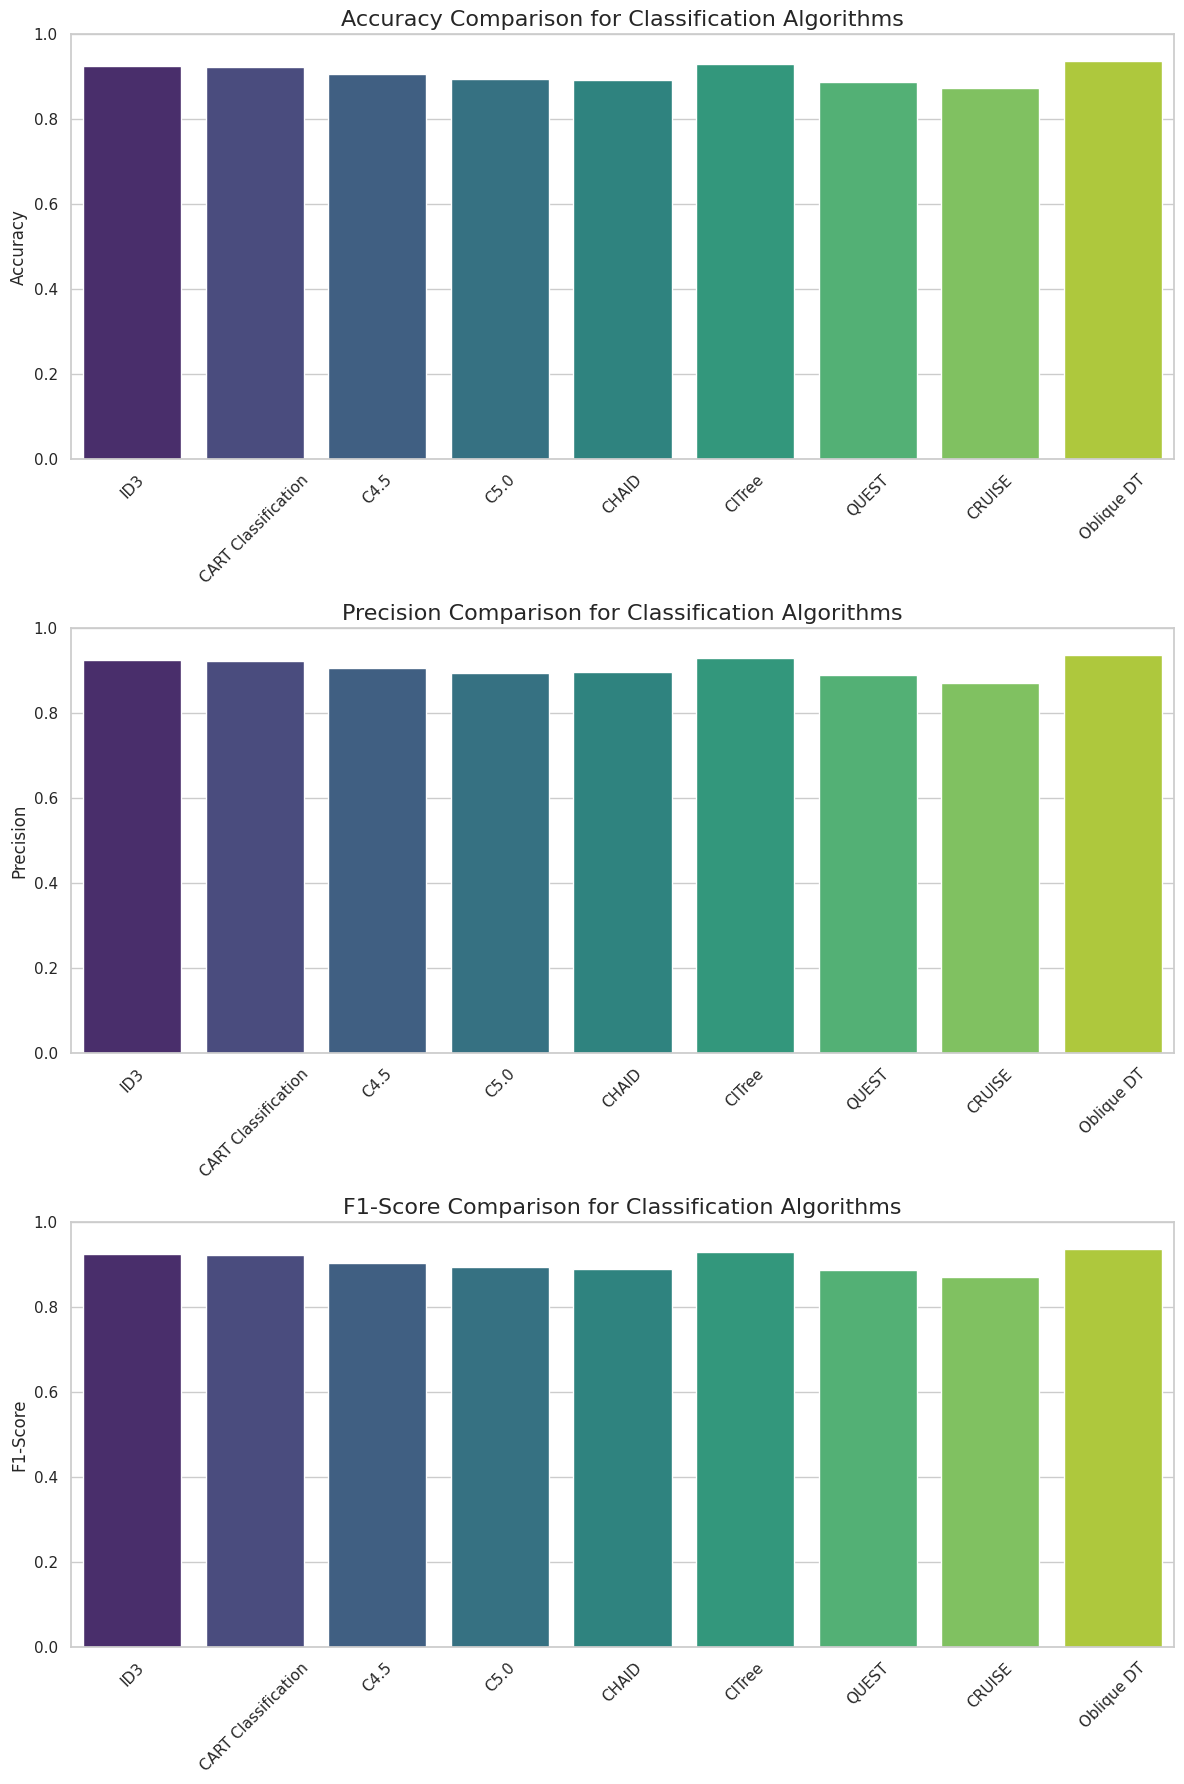

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for plots
sns.set_theme(style="whitegrid")

metrics = ['Accuracy', 'Precision', 'F1-Score']
fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 6 * len(metrics)))

if len(metrics) == 1:
    axes = [axes]

for i, metric in enumerate(metrics):
    # Fix: explicitly set hue to x to resolve FutureWarning
    sns.barplot(x=classification_df.index, y=metric, data=classification_df, ax=axes[i], palette='viridis', hue=classification_df.index, legend=False)
    axes[i].set_title(f'{metric} Comparison for Classification Algorithms', fontsize=16)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

### Regression Algorithms Performance

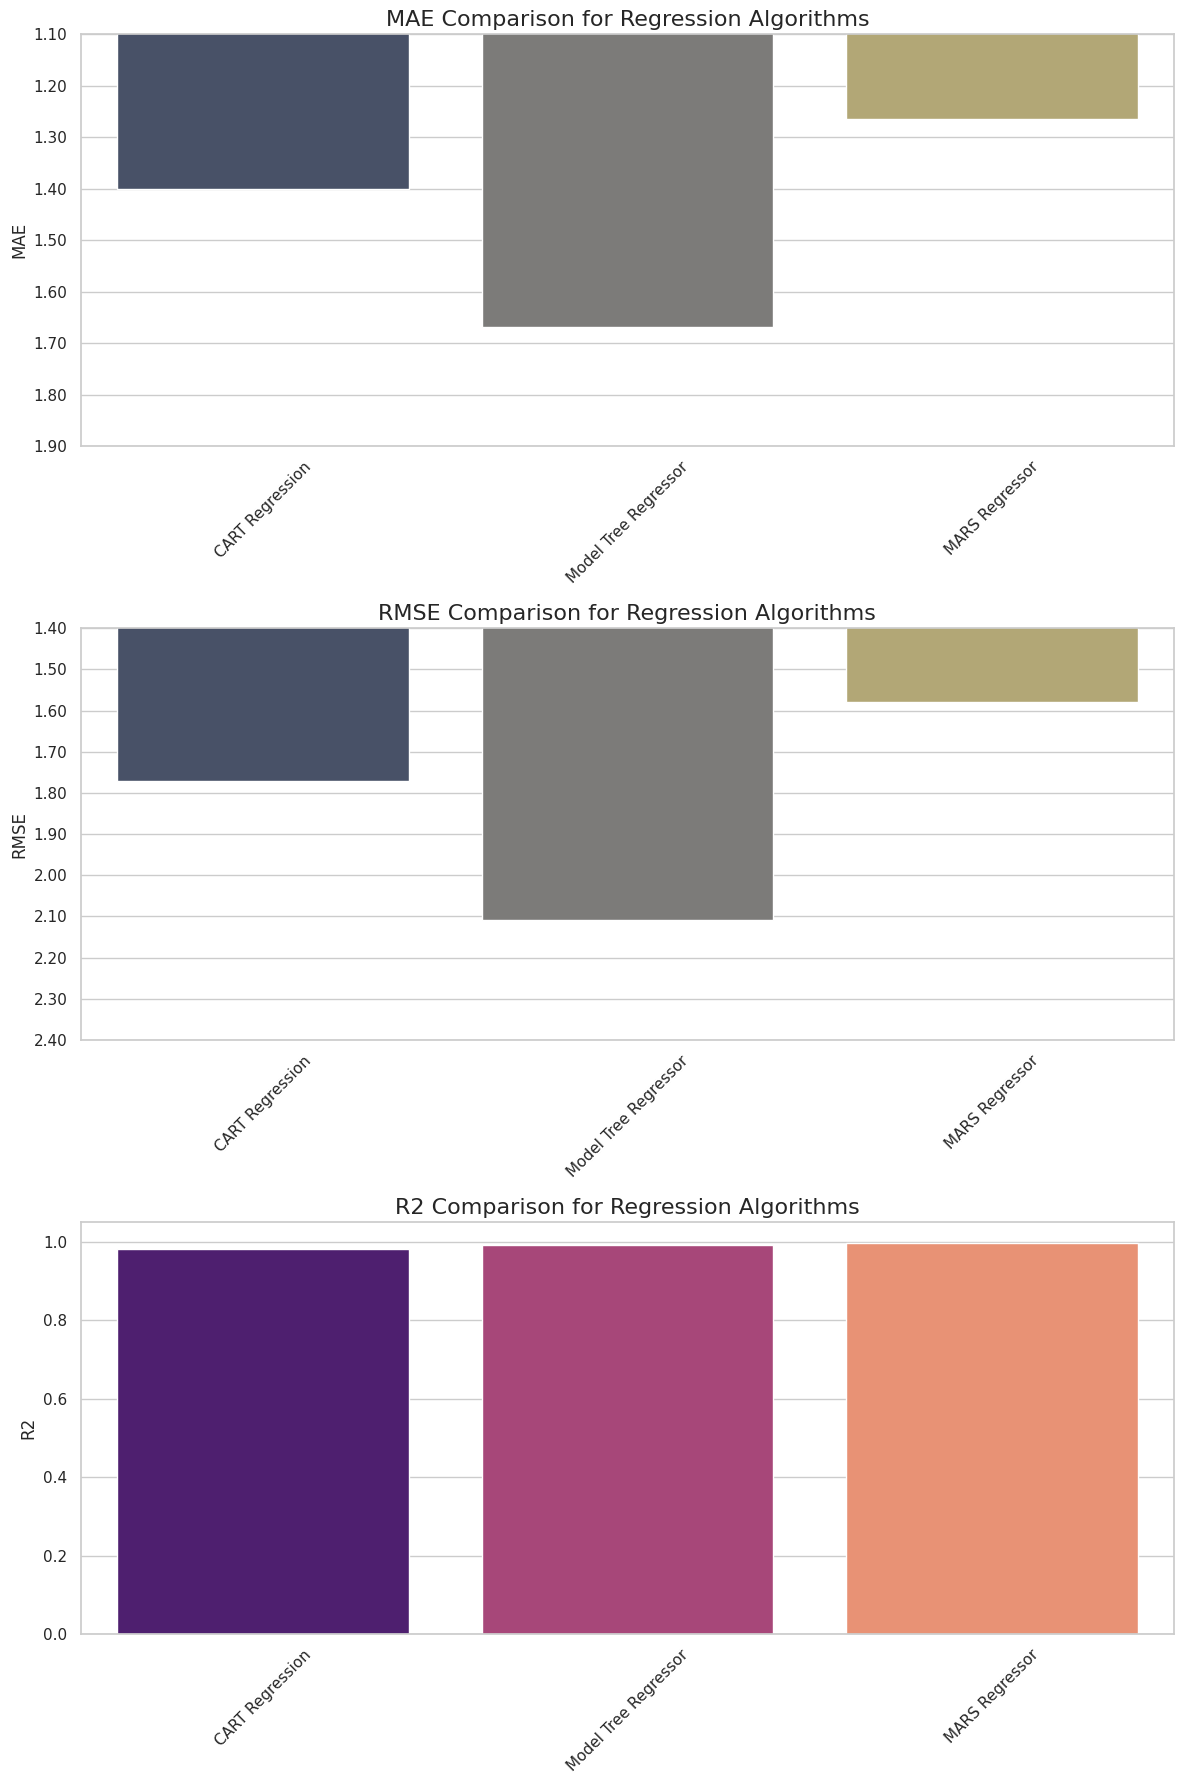

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

regression_metrics_to_plot = ['MAE', 'RMSE', 'R2']
fig, axes = plt.subplots(len(regression_metrics_to_plot), 1, figsize=(12, 6 * len(regression_metrics_to_plot)))

if len(regression_metrics_to_plot) == 1:
    axes = [axes]

for i, metric in enumerate(regression_metrics_to_plot):
    if metric == 'R2':
        # R2: Higher is better
        # Fix: explicitly set hue to x to resolve FutureWarning
        sns.barplot(x=regression_df.index, y=metric, data=regression_df, ax=axes[i], palette='magma', hue=regression_df.index, legend=False)
        axes[i].set_ylim(min(0, regression_df[metric].min() - 0.05), 1.05)
    else:
        # MAE, RMSE: Lower is better. Invert for visual consistency with 'better' being taller bars.
        inverted_metric = -regression_df[metric]
        # Fix: explicitly set hue to x to resolve FutureWarning
        sns.barplot(x=regression_df.index, y=inverted_metric, data=regression_df, ax=axes[i], palette='cividis', hue=regression_df.index, legend=False)

        # Adjust y-axis to show original metric values
        ymin_val = -regression_df[metric].max() * 1.1
        ymax_val = -regression_df[metric].min() * 0.9
        if ymin_val > ymax_val: ymin_val, ymax_val = ymax_val, ymin_val # Ensure min < max
        axes[i].set_ylim(ymin_val, ymax_val)

        # Relabel y-ticks to show positive values for MAE/RMSE
        ticks = axes[i].get_yticks()
        axes[i].set_yticks(ticks)
        axes[i].set_yticklabels([f'{abs(t):.2f}' for t in ticks])

    axes[i].set_title(f'{metric} Comparison for Regression Algorithms', fontsize=16)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()